# 전체 학습 내용 & 목표 정리 🗺️

## 📚 학습 내용 로드맵

### 2강. Tokenizer (토크나이저) 준비
- BPE (비피이) / Byte Pair Encoding (바이트 페어 인코딩)
- 단어를 어떻게 쪼개서 token (토큰)으로 만드는가?
- 한국어에 맞는 tokenizer (토크나이저) 학습

### 3강. 데이터 전처리 Data Preprocessing (데이터 프리프로세싱)
**(1) MASK (마스크) 생성**
- MLM / Masked Language Model (마스크드 랭귀지 모델)
- 전체 token (토큰)의 15%를 [MASK] (마스크)로 교체

**(2) NSP pair (엔에스피 페어) 생성**
- Next Sentence Prediction (넥스트 센텐스 프리딕션)
- 진짜 이어지는 문장 vs 랜덤 random (랜덤) 문장 50:50

**(3) 데이터셋 Dataset (데이터셋) 완성**
- MLM (엠엘엠) + NSP (엔에스피) 합쳐서 최종 학습용 데이터셋 완성

### 4강. BERT (버트) 모델 구현
- 나만의 mini BERT (미니 버트) 구현
- Transformer (트랜스포머) 기반
- 목표: ~10M parameter (파라미터)

### 5강. Pretrain (프리트레인) 진행
- MLM loss (엠엘엠 로스) + NSP loss (엔에스피 로스) 동시에 학습
- loss (로스) 안정적 감소 확인

---

## 🎯 학습 목표 3가지

| 목표 | 핵심 내용 |
|---|---|
| **BERT (버트) 구현 & 훈련** | 모델 아키텍처 architecture (아키텍처) 직접 구현 |
| **Masking (마스킹) 기법 이해** | MLM (엠엘엠) — 전체 token (토큰)의 15% 마스킹 규칙 |
| **NSP task (엔에스피 태스크) 이해** | 문장 쌍 pair (페어) 데이터셋 구성 방법 |

---

## 전체 데이터 흐름

| 단계 | 내용 |
|---|---|
| **kowiki.txt** | 한국어 위키 코퍼스 corpus (코퍼스) |
| **2강** | SentencePiece (센텐스피스) BPE (비피이) → tokenizer (토크나이저) 완성 |
| **3강** | MLM (엠엘엠) + NSP (엔에스피) 데이터 가공 → dataset (데이터셋) 완성 |
| **4강** | mini BERT (미니 버트) 모델 구현 → model (모델) 완성 |
| **5강** | pretrain (프리트레인) 진행 → 학습된 BERT (버트) 완성 🎉 |

## 2강. Tokenizer (토크나이저) 준비

- BPE (비피이) 등 subword (서브워드) 기반 토크나이징이 표준
- GPT (지피티) → BPE (비피이) / BERT (버트) → WordPiece (워드피스)
- 오늘 사용: SentencePiece (센텐스피스)

In [1]:
# ================================================================
# 필요한 라이브러리 전체 import (임포트)
# ================================================================

from __future__ import absolute_import, division, print_function, unicode_literals

# 딥러닝 프레임워크 PyTorch (파이토치)
import torch
import torch.nn as nn                          # 신경망 레이어 layer (레이어)
import torch.nn.functional as F               # 활성화 함수 activation (액티베이션) 등
import torch.optim as optim                   # 옵티마이저 optimizer (옵티마이저)
from torch.utils.data import DataLoader, TensorDataset  # 데이터 로더 loader (로더)
from torchsummary import summary              # 모델 구조 요약 출력

# 기본 유틸리티 utility (유틸리티)
import os                                     # 파일/경로 관리
import re                                     # 정규표현식 regex (레젝스)
import math                                   # 수학 함수
import numpy as np                            # 수치 계산
import pandas as pd                           # 데이터프레임 dataframe (데이터프레임)
import random                                 # 랜덤 random (랜덤) 함수
import collections                            # 자료구조
import json                                   # JSON (제이슨) 파일 처리
import shutil                                 # 파일 복사/이동
import zipfile                                # 압축파일 처리
import copy                                   # 깊은 복사 deep copy (딥 카피)
from datetime import datetime                 # 날짜/시간

# 시각화 visualization (비주얼라이제이션)
import matplotlib.pyplot as plt               # 그래프 출력

# NLP (엔엘피) 관련
import sentencepiece as spm                   # 한국어 토크나이저 tokenizer (토크나이저)
from tqdm.notebook import tqdm               # 진행률 표시 progress bar (프로그레스 바)

# ================================================================
# 재현성을 위한 랜덤 시드 random seed (랜덤 시드) 고정
# ================================================================
random_seed = 1234
random.seed(random_seed)       # Python (파이썬) random (랜덤) 시드 고정
np.random.seed(random_seed)    # NumPy (넘파이) 시드 고정

# PyTorch (파이토치) 버전 확인
print(torch.__version__)

2.7.1+cu118


## 2강. SentencePiece (센텐스피스) 모델 생성

- vocab_size (보캡 사이즈): 32000
- 특수 토큰 special token (스페셜 토큰) 필수 포함:
  - [PAD] (패드): 패딩 padding (패딩)
  - [UNK] (언크): 미등록어 unknown (언노운)
  - [BOS] (보스): 문장 시작 Begin of Sentence (비긴 오브 센텐스)
  - [EOS] (이오에스): 문장 끝 End of Sentence (엔드 오브 센텐스)
  - [SEP] (셉): 문장 구분자 Separator (세퍼레이터)
  - [CLS] (클스): 분류 토큰 Classifier (클래시파이어)
  - [MASK] (마스크): 마스킹 토큰
- 소요시간: 약 30분 → 미리 만든 파일 사용!

In [2]:
# ================================================================
# SentencePiece (센텐스피스) 모델 학습 설정
# ================================================================
import sentencepiece as spm
import os

# 경로 설정
corpus_file = 'data/kowiki.txt'   # 한국어 위키 코퍼스 corpus (코퍼스) 경로
prefix      = 'data/ko_32000'     # 생성될 모델 저장 경로 prefix (프리픽스)
vocab_size  = 32000               # vocab (보캡) 크기

# ================================================================
# 직접 만들어보실 분들은 주석을 풀어 진행해보세요!
# 약 30분 소요 → LMS (엘엠에스) 환경에서는 시간이 오래 걸려요!
# ================================================================
# spm.SentencePieceTrainer.train(
#     f"--input={corpus_file} "               # 학습할 코퍼스 파일
#     f"--model_prefix={prefix} "             # 모델 저장 이름
#     f"--vocab_size={vocab_size + 7} "       # vocab 크기 (+7: 특수토큰 7개)
#     f"--model_type=bpe "                    # BPE (비피이) 방식 사용
#     f"--max_sentence_length=999999 "        # 최대 문장 길이
#     f"--pad_id=0 --pad_piece=[PAD] "        # [PAD] (패드): id=0
#     f"--unk_id=1 --unk_piece=[UNK] "        # [UNK] (언크): id=1
#     f"--bos_id=2 --bos_piece=[BOS] "        # [BOS] (보스): id=2
#     f"--eos_id=3 --eos_piece=[EOS] "        # [EOS] (이오에스): id=3
#     f"--user_defined_symbols=[SEP],[CLS],[MASK]"  # BERT (버트) 특수토큰
# )

## SentencePiece (센텐스피스) Vocab (보캡) 로딩 Loading (로딩)

- 학습된 ko_32000.model 파일을 불러옴
- vocab_size (보캡 사이즈): 32000 + 특수토큰 7개 = 32007
- 특수토큰 special token (스페셜 토큰):
  - [PAD] (패드) id=0 / [UNK] (언크) id=1
  - [BOS] (보스) id=2 / [EOS] (이오에스) id=3
  - [SEP] (셉) id=4 / [CLS] (클스) id=5 / [MASK] (마스크) id=6

In [ ]:
# ================================================================
# ko_32000 모델 직접 생성 (약 30분 소요)
# ================================================================
import sentencepiece as spm
import os

# 경로 설정
corpus_file = os.path.expanduser('~/work/bert_pretrain/data/kowiki.txt')
prefix      = os.path.expanduser('~/work/bert_pretrain/data/ko_32000')
vocab_size  = 32000

# kowiki.txt 파일 존재 확인
print(f"kowiki.txt 존재: {os.path.exists(corpus_file)}")

# SentencePiece (센텐스피스) 모델 학습 시작!
spm.SentencePieceTrainer.train(
    f"--input={corpus_file} "
    f"--model_prefix={prefix} "
    f"--vocab_size={vocab_size + 7} "
    f"--model_type=bpe "
    f"--max_sentence_length=999999 "
    f"--pad_id=0 --pad_piece=[PAD] "
    f"--unk_id=1 --unk_piece=[UNK] "
    f"--bos_id=2 --bos_piece=[BOS] "
    f"--eos_id=3 --eos_piece=[EOS] "
    f"--user_defined_symbols=[SEP],[CLS],[MASK]"
)

print("완료! ko_32000.model, ko_32000.vocab 생성됨 ✅")

9020 all=2086421 active=105631 piece=니까
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2081 size=9040 all=2088735 active=107945 piece=▁대주교
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2076 size=9060 all=2090194 active=109404 piece=▁물리학
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2071 size=9080 all=2092227 active=111437 piece=▁사용자가
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2066 size=9100 all=2095219 active=114429 piece=▁구체적인
bpe_model_trainer.cc(159) LOG(INFO) Updating active symbols. max_freq=2065 min_freq=110
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2062 size=9120 all=2096893 active=106435 piece=▁천황의
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2056 size=9140 all=2098591 active=108133 piece=▁종전
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2053 size=9160 all=2099815 active=109357 piece=바야
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2048 size=9180 all=2102113 active=111655 piece=▁전염
bpe_model_trainer.cc(268) LOG(INFO) Added: freq=2043 size=9200 all=2103828

## BERT (버트) 입력 형식 토큰 생성

- BERT (버트) 입력 형식: [CLS] + 문장A + [SEP] + 문장B + [SEP]
- encode_as_pieces (인코드 애스 피시스): 문장 → subword (서브워드) 토큰 리스트
- [CLS] (클스): 문장 시작 / 분류 토큰
- [SEP] (셉): 문장 구분자 separator (세퍼레이터)## BERT (버트) 입력 형식 토큰 생성

- BERT (버트) 입력 형식: [CLS] + 문장A + [SEP] + 문장B + [SEP]
- encode_as_pieces (인코드 애스 피시스): 문장 → subword (서브워드) 토큰 리스트
- [CLS] (클스): 문장 시작 / 분류 토큰
- [SEP] (셉): 문장 구분자 separator (세퍼레이터)

In [8]:
# ================================================================
# [CLS] + tokens_a + [SEP] + tokens_b + [SEP] 형태로 토큰 생성
# BERT (버트) 표준 입력 형식!
# ================================================================

# 입력 문장 두 개
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"

# BERT (버트) 입력 형식으로 토큰화 tokenize (토크나이즈)
# [CLS] + 문장A 토큰들 + [SEP] + 문장B 토큰들 + [SEP]
tokens_org = (
    ["[CLS]"]                          +  # 문장 시작 토큰
    vocab.encode_as_pieces(string_a)   +  # 문장A → subword (서브워드) 토큰 리스트
    ["[SEP]"]                          +  # 문장 구분자
    vocab.encode_as_pieces(string_b)   +  # 문장B → subword (서브워드) 토큰 리스트
    ["[SEP]"]                             # 문장 끝 구분자
)

print(f"전체 token (토큰) 수: {len(tokens_org)}")
print(tokens_org)

전체 token (토큰) 수: 75
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


## 3강. 데이터 전처리 - (1) MASK (마스크) 생성

### MLM / Masked Language Model (마스크드 랭귀지 모델) 규칙

- 전체 token (토큰)의 **15%** 를 선택
- 선택된 15% 중:
  - **80%** → [MASK] (마스크) 토큰으로 교체
  - **10%** → 랜덤 random (랜덤) 토큰으로 교체
  - **10%** → 원래 토큰 그대로 유지
- [CLS] (클스), [SEP] (셉) 3개는 마스킹 제외!

In [9]:
# ================================================================
# 전체 token (토큰)의 15% 마스킹 masking (마스킹) 개수 계산
# ================================================================

# 현재 token (토큰) 목록 확인
print(tokens_org)

# 전체 token (토큰) 수에서 특수토큰 3개 제외
# [CLS] 1개 + [SEP] 2개 = 3개 제외
mask_cnt = int((len(tokens_org) - 3) * 0.15)  # 15% 계산

print(f"\n전체 token (토큰) 수: {len(tokens_org)}")
print(f"특수토큰 제외 token (토큰) 수: {len(tokens_org) - 3}")
print(f"마스킹할 token (토큰) 수 (15%): {mask_cnt}")

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']

전체 token (토큰) 수: 75
특수토큰 제외 token (토큰) 수: 72
마스킹할 token (토큰) 수 (15%): 10


## 띄어쓰기 단위 마스킹 Whole Word Masking (홀 워드 마스킹)

- 문제: `_대, [MASK], 민국` → '한' 너무 쉽게 맞춤
- 해결: 띄어쓰기 단위로 한꺼번에 마스킹!
- `▁` (u"\u2581"): SentencePiece (센텐스피스)에서 단어 시작 표시
  - `▁대한` → 새로운 단어 시작
  - `민국` → 이전 단어의 연속 (같은 그룹!)

In [10]:
# ================================================================
# 띄어쓰기 단위로 마스킹하기 위해 index (인덱스) 분할
# ▁ (u"\u2581") = SentencePiece (센텐스피스) 단어 시작 표시
# ================================================================

cand_idx = []  # word (워드) 단위의 index (인덱스) 배열

for (i, token) in enumerate(tokens_org):

    # [CLS] (클스), [SEP] (셉) 특수토큰은 마스킹 후보에서 제외
    if token == "[CLS]" or token == "[SEP]":
        continue

    if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
        # ▁ 로 시작하지 않으면 → 이전 단어의 연속 subword (서브워드)
        # → 같은 그룹에 추가
        cand_idx[-1].append(i)
    else:
        # ▁ 로 시작하면 → 새로운 단어 시작
        # → 새 그룹 생성
        cand_idx.append([i])

# 결과 확인
print(f"전체 word (워드) 단위 그룹 수: {len(cand_idx)}\n")
for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

전체 word (워드) 단위 그룹 수: 41

[1, 2, 3] ['▁추적', '추', '적']
[4] ['▁비가']
[5] ['▁내리는']
[6, 7, 8] ['▁날', '이었', '어']
[9, 10] ['▁그날', '은']
[11, 12, 13] ['▁', '왠', '지']
[14, 15] ['▁손', '님이']
[16] ['▁많아']
[17] ['▁첫']
[18] ['▁번에']
[19, 20] ['▁삼', '십']
[21] ['▁전']
[22, 23] ['▁둘째', '번']
[24, 25] ['▁오', '십']
[26] ['▁전']
[27, 28] ['▁오랜', '만에']
[29, 30] ['▁받아', '보는']
[31] ['▁십']
[32, 33] ['▁전', '짜리']
[34, 35, 36] ['▁백', '통', '화']
[37, 38, 39] ['▁서', '푼', '에']
[41] ['▁손바닥']
[42, 43] ['▁위', '엔']
[44, 45] ['▁기쁨', '의']
[46, 47] ['▁눈', '물이']
[48] ['▁흘러']
[49, 50, 51] ['▁컬', '컬', '한']
[52] ['▁목에']
[53, 54] ['▁모', '주']
[55, 56, 57] ['▁한', '잔', '을']
[58, 59] ['▁적', '셔']
[60] ['▁몇']
[61] ['▁달']
[62] ['▁포']
[63] ['▁전부터']
[64, 65, 66] ['▁콜', '록', '거리는']
[67] ['▁아내']
[68] ['▁생각에']
[69, 70] ['▁그', '토록']
[71] ['▁먹고']
[72, 73] ['▁싶다', '던']


## 랜덤 Random (랜덤) 마스킹을 위한 index (인덱스) 셔플 shuffle (셔플)

- 마스킹할 위치를 랜덤 random (랜덤) 하게 선택하기 위해
- cand_idx (캔드 인덱스) 순서를 무작위로 섞음
- random.shuffle (랜덤 셔플): 리스트 순서 무작위 섞기
- 앞에서 random_seed = 1234 고정했으므로 재현 가능! reproducible (리프로듀서블)

In [11]:
# ================================================================
# 랜덤 random (랜덤) 마스킹을 위해 index (인덱스) 순서를 섞음
# random_seed = 1234 로 고정되어 있어 항상 같은 결과!
# ================================================================

random.shuffle(cand_idx)   # cand_idx (캔드 인덱스) 순서 무작위 셔플 shuffle (셔플)

print(f"셔플 후 word (워드) 단위 그룹 수: {len(cand_idx)}\n")
for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

셔플 후 word (워드) 단위 그룹 수: 41

[18] ['▁번에']
[48] ['▁흘러']
[71] ['▁먹고']
[49, 50, 51] ['▁컬', '컬', '한']
[22, 23] ['▁둘째', '번']
[21] ['▁전']
[37, 38, 39] ['▁서', '푼', '에']
[53, 54] ['▁모', '주']
[52] ['▁목에']
[34, 35, 36] ['▁백', '통', '화']
[19, 20] ['▁삼', '십']
[44, 45] ['▁기쁨', '의']
[17] ['▁첫']
[24, 25] ['▁오', '십']
[61] ['▁달']
[63] ['▁전부터']
[46, 47] ['▁눈', '물이']
[32, 33] ['▁전', '짜리']
[41] ['▁손바닥']
[26] ['▁전']
[31] ['▁십']
[60] ['▁몇']
[16] ['▁많아']
[68] ['▁생각에']
[29, 30] ['▁받아', '보는']
[1, 2, 3] ['▁추적', '추', '적']
[6, 7, 8] ['▁날', '이었', '어']
[62] ['▁포']
[72, 73] ['▁싶다', '던']
[5] ['▁내리는']
[9, 10] ['▁그날', '은']
[55, 56, 57] ['▁한', '잔', '을']
[58, 59] ['▁적', '셔']
[69, 70] ['▁그', '토록']
[64, 65, 66] ['▁콜', '록', '거리는']
[67] ['▁아내']
[4] ['▁비가']
[27, 28] ['▁오랜', '만에']
[42, 43] ['▁위', '엔']
[14, 15] ['▁손', '님이']
[11, 12, 13] ['▁', '왠', '지']


## MLM (엠엘엠) 마스킹 Masking (마스킹) 적용

- tokens_org (토큰스 오르그): 원본 token (토큰) 보존용
- tokens (토큰스): 실제 마스킹 적용본
- mask_lms (마스크 엘엠스): 마스킹된 위치 & 원래 label (레이블) 저장
- dice (다이스): 0~1 사이 랜덤 값으로 마스킹 방식 결정
  - 0.0 ~ 0.8  (80%) → [MASK] (마스크) 로 교체
  - 0.8 ~ 0.9  (10%) → 원래 token (토큰) 그대로 유지
  - 0.9 ~ 1.0  (10%) → 랜덤 random (랜덤) token (토큰) 으로 교체
- copy.deepcopy (카피 딥카피): 원본 보존을 위한 깊은 복사

In [13]:
# ================================================================
# vocab_list (보캡 리스트) 생성
# 특수 token (토큰) 7개 제외한 나머지 token (토큰) 목록
# ================================================================

vocab_list = []

for id in range(7, len(vocab)):        # id 7부터 끝까지 순회
    if not vocab.is_unknown(id):       # [UNK] (언크) 토큰 제외
        vocab_list.append(
            vocab.id_to_piece(id)      # id → token (토큰) 문자열 변환
        )

print(f"vocab_list (보캡 리스트) 생성 완료!")
print(f"전체 token (토큰) 수: {len(vocab_list)}")

vocab_list (보캡 리스트) 생성 완료!
전체 token (토큰) 수: 32000


In [14]:
# ================================================================
# MLM (엠엘엠) 마스킹 masking (마스킹) 적용
# tokens_org (토큰스 오르그) 는 원본 보존용
# tokens (토큰스) 에 실제 마스킹 적용
# ================================================================

# 원본 token (토큰) 깊은 복사 deep copy (딥 카피)
# → 재실행해도 tokens_org (토큰스 오르그) 는 변하지 않음
tokens = copy.deepcopy(tokens_org)
mask_lms = []  # 마스킹된 위치 index (인덱스) & 원래 label (레이블) 저장

for index_set in cand_idx:

    # 현재 마스킹된 개수가 15% 넘으면 중지
    if len(mask_lms) >= mask_cnt:
        break

    # 이번에 마스킹할 개수 포함해서 15% 넘으면 skip (스킵)
    if len(mask_lms) + len(index_set) > mask_cnt:
        continue

    # 0~1 사이 랜덤 random (랜덤) 확률값 → 마스킹 방식 결정
    dice = random.random()

    for index in index_set:
        masked_token = None

        if dice < 0.8:              # 80% → [MASK] (마스크) 로 교체
            masked_token = "[MASK]"

        elif dice < 0.9:            # 10% → 원래 token (토큰) 그대로 유지
            masked_token = tokens[index]

        else:                       # 10% → 랜덤 random (랜덤) token (토큰) 으로 교체
            masked_token = random.choice(vocab_list)

        # 마스킹 정보 저장: 위치 index (인덱스) + 원래 label (레이블)
        mask_lms.append({"index": index, "label": tokens[index]})

        # 실제 token (토큰) 교체
        tokens[index] = masked_token

# 결과 확인
print("tokens_org (원본)")
print(tokens_org, "\n")
print("tokens (마스킹 적용본)")
print(tokens)
print(f"\n마스킹된 token (토큰) 수: {len(mask_lms)}")
print(f"마스킹 정보: {mask_lms}")

tokens_org (원본)
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens (마스킹 적용본)
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '[MASK]', '▁삼', '십', '[MASK]', '[MASK]', '[MASK]', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '[MASK]', '▁싶다', '던', '[SEP]']

마스킹된 tok

## 마스킹 정보 정렬 & 분리

- mask_lms (마스크 엘엠스) 를 index (인덱스) 순서대로 정렬
- mask_idx (마스크 인덱스): 마스킹된 위치 index (인덱스) 목록
- mask_label (마스크 레이블): 마스킹된 위치의 원래 token (토큰) 목록
- 학습 시 mask_idx (마스크 인덱스) 위치의 token (토큰) 을 맞추는 것이 MLM (엠엘엠) 태스크!

In [15]:
# ================================================================
# 마스킹 정보 정렬 및 mask_idx (마스크 인덱스), mask_label (마스크 레이블) 생성
# ================================================================

# index (인덱스) 순서대로 정렬 sort (소트)
mask_lms = sorted(mask_lms, key=lambda x: x["index"])

# 마스킹된 위치 index (인덱스) 목록
mask_idx = [p["index"] for p in mask_lms]

# 마스킹된 위치의 원래 token (토큰) 목록 → 정답 label (레이블)
mask_label = [p["label"] for p in mask_lms]

print("mask_idx   :", mask_idx)    # 마스킹된 위치들
print("mask_label :", mask_label)  # 각 위치의 원래 token (토큰) = 정답!

mask_idx   : [18, 21, 22, 23, 48, 49, 50, 51, 52, 71]
mask_label : ['▁번에', '▁전', '▁둘째', '번', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁먹고']


## create_pretrain_mask (크리에이트 프리트레인 마스크) 함수 완성

### 함수 동작 순서
1. 띄어쓰기 단위로 index (인덱스) 그룹화 → cand_idx (캔드 인덱스)
2. cand_idx (캔드 인덱스) 랜덤 shuffle (셔플)
3. mask_cnt (마스크 카운트) 개수만큼 마스킹 적용
   - 80% → [MASK] (마스크) 교체
   - 10% → 원래 token (토큰) 유지
   - 10% → 랜덤 random (랜덤) token (토큰) 교체
4. mask_idx (마스크 인덱스), mask_label (마스크 레이블) 반환

### 입력 Input (인풋) / 출력 Output (아웃풋)
- 입력: tokens (토큰스), mask_cnt (마스크 카운트), vocab_list (보캡 리스트)
- 출력: tokens (마스킹 적용), mask_idx (마스킹 위치), mask_label (원래 정답)

In [16]:
# ================================================================
# create_pretrain_mask (크리에이트 프리트레인 마스크) 함수
# MLM (엠엘엠) 마스킹 masking (마스킹) 생성 함수
# ================================================================

def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성 함수
    :param tokens: 입력 token (토큰) 리스트
    :param mask_cnt: 마스킹할 token (토큰) 개수 (전체의 15%)
    :param vocab_list: vocab (보캡) 리스트 (랜덤 token (토큰) 선택용)
    :return tokens: 마스킹 적용된 token (토큰) 리스트
    :return mask_idx: 마스킹된 token (토큰) 의 index (인덱스) 목록
    :return mask_label: 마스킹된 token (토큰) 의 원래 값 (정답 label (레이블))
    """

    # -------------------------------------------------------
    # 1. 띄어쓰기 단위로 index (인덱스) 그룹화
    # ▁ (u"\u2581") = 단어 시작 표시
    # -------------------------------------------------------
    cand_idx = []
    for (i, token) in enumerate(tokens):

        # [CLS] (클스), [SEP] (셉) 특수토큰 제외
        if token == "[CLS]" or token == "[SEP]":
            continue

        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            # ▁ 로 시작 안하면 → 이전 단어의 연속 subword (서브워드)
            cand_idx[-1].append(i)
        else:
            # ▁ 로 시작하면 → 새로운 단어 시작
            cand_idx.append([i])

    # -------------------------------------------------------
    # 2. 랜덤 random (랜덤) 마스킹을 위해 순서 섞기 shuffle (셔플)
    # -------------------------------------------------------
    random.shuffle(cand_idx)

    # -------------------------------------------------------
    # 3. mask_cnt (마스크 카운트) 개수만큼 마스킹 적용
    # -------------------------------------------------------
    mask_lms = []
    for index_set in cand_idx:

        # 마스킹 개수가 mask_cnt (마스크 카운트) 이상이면 중지
        if len(mask_lms) >= mask_cnt:
            break

        # 이번 그룹 포함시 mask_cnt (마스크 카운트) 초과하면 skip (스킵)
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        # 0~1 사이 랜덤 random (랜덤) 값으로 마스킹 방식 결정
        dice = random.random()

        for index in index_set:
            masked_token = None

            if dice < 0.8:             # 80% → [MASK] (마스크) 교체
                masked_token = "[MASK]"

            elif dice < 0.9:           # 10% → 원래 token (토큰) 유지
                masked_token = tokens[index]

            else:                      # 10% → 랜덤 random (랜덤) token (토큰) 교체
                masked_token = random.choice(vocab_list)

            # 마스킹 정보 저장: 위치 + 원래 label (레이블)
            mask_lms.append({"index": index, "label": tokens[index]})

            # 실제 token (토큰) 교체
            tokens[index] = masked_token

    # -------------------------------------------------------
    # 4. 정렬 후 mask_idx (마스크 인덱스), mask_label (마스크 레이블) 추출
    # -------------------------------------------------------
    mask_lms   = sorted(mask_lms, key=lambda x: x["index"])  # index (인덱스) 순 정렬
    mask_idx   = [p["index"] for p in mask_lms]               # 마스킹 위치 목록
    mask_label = [p["label"] for p in mask_lms]               # 원래 token (토큰) 목록 = 정답!

    return tokens, mask_idx, mask_label


# ================================================================
# 함수 테스트 test (테스트)
# ================================================================
tokens_test = copy.deepcopy(tokens_org)          # 원본 보존용 깊은 복사 deep copy (딥 카피)
mask_cnt    = int((len(tokens_org) - 3) * 0.15)  # 전체의 15%

tokens_masked, mask_idx, mask_label = create_pretrain_mask(
    tokens_test, mask_cnt, vocab_list
)

print(f"마스킹된 token (토큰) 수: {len(mask_idx)}")
print(f"mask_idx   : {mask_idx}")
print(f"mask_label : {mask_label}")
print(f"\n원본    : {tokens_org}")
print(f"마스킹본: {tokens_masked}")

마스킹된 token (토큰) 수: 10
mask_idx   : [5, 14, 15, 29, 30, 31, 53, 54, 60, 71]
mask_label : ['▁내리는', '▁손', '님이', '▁받아', '보는', '▁십', '▁모', '주', '▁몇', '▁먹고']

원본    : ['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']
마스킹본: ['[CLS]', '▁추적', '추', '적', '▁비가', '[MASK]', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '[MASK]', '[MASK]', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '[MASK]', '[MASK]', '[MASK]', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적'

## create_pretrain_mask (크리에이트 프리트레인 마스크) 함수 테스트

- copy.deepcopy (카피 딥카피): 원본 tokens_org (토큰스 오르그) 보존
- 함수 실행 후 원본과 마스킹본 비교 확인
- mask_idx (마스크 인덱스): 마스킹된 위치
- mask_label (마스크 레이블): 마스킹된 위치의 원래 정답 token (토큰)

In [17]:
# ================================================================
# create_pretrain_mask (크리에이트 프리트레인 마스크) 함수 테스트
# tokens (토큰스) 가 마스킹되므로 재실행을 위해 deepcopy (딥카피) 사용
# ================================================================

# 원본 보존용 깊은 복사 deep copy (딥 카피)
tokens = copy.deepcopy(tokens_org)

# 마스킹 함수 실행
tokens, mask_idx, mask_label = create_pretrain_mask(
    tokens,      # 마스킹할 token (토큰) 리스트
    mask_cnt,    # 마스킹할 개수 (전체의 15%)
    vocab_list   # 랜덤 token (토큰) 선택용 vocab (보캡) 리스트
)

# 결과 확인
print("tokens_org (원본)")
print(tokens_org, "\n")

print("tokens (마스킹 적용본)")
print(tokens, "\n")

print("mask_idx   :", mask_idx)    # 마스킹된 위치 index (인덱스)
print("mask_label :", mask_label)  # 마스킹된 위치의 원래 정답 token (토큰)

tokens_org (원본)
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens (마스킹 적용본)
['[CLS]', '[MASK]', '[MASK]', '[MASK]', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[MASK]', '▁달', '[MASK]', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '[MASK]', '[MASK]', '▁먹고', '▁싶다', '던', '[SEP]'] 

mask_idx   : [1,

## 3강. 데이터 전처리 - (2) NSP pair (엔에스피 페어) 생성

### NSP / Next Sentence Prediction (넥스트 센텐스 프리딕션) 란?
- 두 문장이 실제로 이어지는지 예측하는 태스크 task (태스크)
- TRUE / IsNext (이즈넥스트): 실제로 이어지는 문장 쌍 pair (페어)
- FALSE / NotNext (낫넥스트): 랜덤 random (랜덤) 으로 선택된 문장 쌍

### 예시
- [CLS] 문장A [SEP] 문장B [SEP] → TRUE (실제 다음 문장)
- [CLS] 문장A [SEP] 문장C [SEP] → FALSE (관계없는 문장)

### 데이터 구성 비율
- TRUE (이즈넥스트) 50% : FALSE (낫넥스트) 50%

In [18]:
# ================================================================
# NSP (엔에스피) pair (페어) 생성을 위한 예시 문장
# ================================================================

string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

# 문장 단위로 분리 split (스플릿)
lines = string.strip().split("\n")

print(f"전체 문장 수: {len(lines)}")
for i, line in enumerate(lines):
    print(f"[{i}] {line}")

전체 문장 수: 18
[0] 추적추적 비가 내리는 날이었어
[1] 그날은 왠지 손님이 많아
[2] 첫 번에 삼십 전 둘째 번 오십 전
[3] 오랜만에 받아보는 십 전짜리 백통화 서푼에
[4] 손바닥 위엔 기쁨의 눈물이 흘러
[5] 컬컬한 목에 모주 한잔을 적셔
[6] 몇 달 포 전부터 콜록거리는 아내
[7] 생각에 그토록 먹고 싶다던
[8] 설렁탕 한 그릇을 이제는 살 수 있어
[9] 집으로 돌아가는 길 난 문득 떠올라
[10] 아내의 목소리가 거칠어만 가는 희박한 숨소리가
[11] 오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
[12] 그리도 나가고 싶으면 일찍이라도 들어와 달라던
[13] 아내의 간절한 목소리가 들려와
[14] 나를 원망하듯 비는 점점 거세져
[15] 싸늘히 식어가는 아내가 떠올라 걱정은 더해져
[16] 난 몰라 오늘은 운수 좋은 날
[17] 난 맨날 이렇게 살 수 있으면 얼마나 좋을까


## 문장 단위 토크나이징 Tokenizing (토크나이징)

- string (스트링) 을 줄 단위 `\n` 로 분리
- 각 줄을 encode_as_pieces (인코드 애스 피시스) 로 token (토큰) 리스트로 변환
- doc (닥): 문장별 token (토큰) 리스트의 리스트
- NSP (엔에스피) 에서 문장 단위로 pair (페어) 를 만들기 위한 준비!

In [19]:
# ================================================================
# 줄 단위로 tokenize (토크나이즈)
# 각 줄 → subword (서브워드) token (토큰) 리스트로 변환
# ================================================================

# string (스트링) 을 \n 기준으로 분리 후 각 줄을 토크나이징
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]

print(f"전체 문장 수: {len(doc)}")
print(f"\n첫 3개 문장 확인:")
for i, tokens in enumerate(doc[:3]):
    print(f"[{i}] {tokens}")

전체 문장 수: 18

첫 3개 문장 확인:
[0] ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어']
[1] ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아']
[2] ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전']


## NSP (엔에스피) 시퀀스 길이 설정

- n_test_seq (엔 테스트 시퀀스): 테스트용 최대 시퀀스 sequence (시퀀스) 길이 = 64
- min_seq (민 시퀀스): 최소 시퀀스 길이 = 8
- max_seq (맥스 시퀀스): 실제 token (토큰) 최대 길이 = 64 - 3 = 61
  - 3을 빼는 이유: [CLS] (클스) 1개 + [SEP] (셉) 2개 = 3개 특수토큰 자리 확보!
- 실제 BERT (버트) 는 n_seq = 512 사용 (우리는 테스트용 64!)

In [20]:
# ================================================================
# NSP (엔에스피) 시퀀스 sequence (시퀀스) 길이 설정
# ================================================================

# 테스트용 최대 시퀀스 길이 (실제 BERT (버트) 는 512)
n_test_seq = 64

# 최소 시퀀스 길이
min_seq = 8

# 실제 token (토큰) 최대 길이
# [CLS] (클스) 1개 + [SEP] (셉) 2개 = 특수토큰 3개 제외
max_seq = n_test_seq - 3   # 64 - 3 = 61

print(f"n_test_seq (최대 시퀀스 길이): {n_test_seq}")
print(f"min_seq    (최소 시퀀스 길이): {min_seq}")
print(f"max_seq    (실제 token 최대): {max_seq}")
print(f"\n[CLS] + tokens_a + [SEP] + tokens_b + [SEP]")
print(f"  1   +   ?      +   1   +    ?     +   1   = 최대 {n_test_seq}")

n_test_seq (최대 시퀀스 길이): 64
min_seq    (최소 시퀀스 길이): 8
max_seq    (실제 token 최대): 61

[CLS] + tokens_a + [SEP] + tokens_b + [SEP]
  1   +   ?      +   1   +    ?     +   1   = 최대 64


## NSP (엔에스피) pair (페어) 생성 - 문장 청크 chunk (청크) 분리

### 동작 방식
- current_chunk (커런트 청크): 줄 단위 token (토큰) 묶음
- current_length (커런트 렝스): 현재 청크의 전체 token (토큰) 수
- 마지막 줄이거나 max_seq (맥스 시퀀스) 이상이면 → 학습 데이터 생성!
- a_end (에이 엔드): 랜덤 random (랜덤) 으로 문장A/B 분리 지점 결정
  - tokens_a (토큰스 에이): 앞부분 문장들
  - tokens_b (토큰스 비): 뒷부분 문장들

In [21]:
# ================================================================
# NSP (엔에스피) pair (페어) 생성을 위한 문장 청크 chunk (청크) 분리
# ================================================================

current_chunk = []   # 줄 단위 token (토큰) 묶음
current_length = 0   # 현재 청크 chunk (청크) 의 전체 token (토큰) 수

for i in range(len(doc)):    # doc (닥) 전체 순회 loop (루프)

    current_chunk.append(doc[i])       # 줄 단위로 청크에 추가
    current_length += len(doc[i])      # 현재 청크의 token (토큰) 수 누적

    # 마지막 줄이거나 token (토큰) 수가 max_seq (맥스 시퀀스) 이상이면
    # → 학습 데이터 생성!
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):

        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # -------------------------------------------------------
        # tokens_a (토큰스 에이) 생성
        # a_end (에이 엔드): 랜덤 random (랜덤) 으로 문장A/B 분리 지점 결정
        # -------------------------------------------------------
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))  # 1 ~ len-1 사이 랜덤

        tokens_a = []
        for j in range(a_end):               # 0 ~ a_end 앞부분 → 문장A
            tokens_a.extend(current_chunk[j])

        # -------------------------------------------------------
        # tokens_b (토큰스 비) 생성
        # -------------------------------------------------------
        tokens_b = []
        for j in range(a_end, len(current_chunk)):  # a_end ~ 끝 뒷부분 → 문장B
            tokens_b.extend(current_chunk[j])

        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        print()

        # 청크 초기화 → 다음 청크 준비
        current_chunk = []
        current_length = 0

current_chunk: 7 66 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
tokens_a: 47 ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러']
tokens_b: 19 ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']

current_chunk: 7 65 [['▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던'], ['▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁이제는', '▁살', '▁수', '▁있어'], ['▁집으로', '▁돌아가는', '▁길', '

## trim_tokens (트림 토큰스) 함수

### 역할
- tokens_a (토큰스 에이) + tokens_b (토큰스 비) 합산 길이가
  max_seq (맥스 시퀀스) 초과하면 잘라냄 trim (트림)

### 자르는 방식
- tokens_a (토큰스 에이) 가 더 길면 → 앞에서 제거 del tokens_a[0]
- tokens_b (토큰스 비) 가 더 길면  → 뒤에서 제거 tokens_b.pop()
- 둘이 같으면 → tokens_b (토큰스 비) 뒤에서 제거
- 합산 길이가 max_seq (맥스 시퀀스) 이하가 될 때까지 반복!

In [22]:
# ================================================================
# trim_tokens (트림 토큰스) 함수
# tokens_a (토큰스 에이) + tokens_b (토큰스 비) 길이를 max_seq (맥스 시퀀스) 이하로 조정
# ================================================================

def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a (토큰스 에이), tokens_b (토큰스 비) 의 길이를 줄임
    최대 길이: max_seq (맥스 시퀀스)
    :param tokens_a: tokens A (토큰스 에이)
    :param tokens_b: tokens B (토큰스 비)
    :param max_seq: 두 tokens (토큰스) 길이의 최대 합산값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)  # 현재 합산 길이

        # 합산 길이가 max_seq (맥스 시퀀스) 이하면 종료
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            # tokens_a (토큰스 에이) 가 더 길면 → 앞에서 제거
            del tokens_a[0]
        else:
            # tokens_b (토큰스 비) 가 더 길거나 같으면 → 뒤에서 제거
            tokens_b.pop()


# ================================================================
# 함수 테스트 test (테스트)
# ================================================================
tokens_a_test = ["▁추적", "추적", "▁비가", "▁내리는", "▁날이었어"]
tokens_b_test = ["▁그날은", "▁왠지", "▁손님이", "▁많아", "▁첫", "▁번에", "▁삼십"]

print(f"trim 전 tokens_a (토큰스 에이) 길이: {len(tokens_a_test)}")
print(f"trim 전 tokens_b (토큰스 비) 길이: {len(tokens_b_test)}")
print(f"trim 전 합산 길이: {len(tokens_a_test) + len(tokens_b_test)}")

trim_tokens(tokens_a_test, tokens_b_test, max_seq=8)

print(f"\ntrim 후 tokens_a (토큰스 에이): {tokens_a_test}")
print(f"trim 후 tokens_b (토큰스 비): {tokens_b_test}")
print(f"trim 후 합산 길이: {len(tokens_a_test) + len(tokens_b_test)}")

trim 전 tokens_a (토큰스 에이) 길이: 5
trim 전 tokens_b (토큰스 비) 길이: 7
trim 전 합산 길이: 12

trim 후 tokens_a (토큰스 에이): ['추적', '▁비가', '▁내리는', '▁날이었어']
trim 후 tokens_b (토큰스 비): ['▁그날은', '▁왠지', '▁손님이', '▁많아']
trim 후 합산 길이: 8


## NSP (엔에스피) pair (페어) 생성 - IsNext/NotNext (이즈넥스트/낫넥스트) 레이블 추가

### 핵심 추가 내용
- 50% 확률로 tokens_a (토큰스 에이) 와 tokens_b (토큰스 비) 를 swap (스왑)!
  - swap (스왑) 했으면 → is_next = 0 (NotNext (낫넥스트), FALSE)
  - swap (스왑) 안했으면 → is_next = 1 (IsNext (이즈넥스트), TRUE)
- trim_tokens (트림 토큰스) 로 max_seq (맥스 시퀀스) 초과 길이 조정
- assert (어설트): tokens_a, tokens_b 가 비어있으면 에러 발생!

In [23]:
# ================================================================
# NSP (엔에스피) pair (페어) 생성
# 50% 확률로 swap (스왑) → IsNext (이즈넥스트) / NotNext (낫넥스트) 레이블 생성
# ================================================================

current_chunk = []   # 줄 단위 token (토큰) 묶음
current_length = 0   # 현재 청크 chunk (청크) 의 전체 token (토큰) 수

for i in range(len(doc)):    # doc (닥) 전체 순회 loop (루프)

    current_chunk.append(doc[i])       # 줄 단위로 청크에 추가
    current_length += len(doc[i])      # 현재 청크의 token (토큰) 수 누적

    # 마지막 줄이거나 token (토큰) 수가 max_seq (맥스 시퀀스) 이상이면 학습 데이터 생성
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):

        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # -------------------------------------------------------
        # tokens_a (토큰스 에이) 생성
        # -------------------------------------------------------
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))  # 랜덤 분리 지점

        tokens_a = []
        for j in range(a_end):                 # 앞부분 → 문장A
            tokens_a.extend(current_chunk[j])

        # -------------------------------------------------------
        # tokens_b (토큰스 비) 생성
        # -------------------------------------------------------
        tokens_b = []
        for j in range(a_end, len(current_chunk)):  # 뒷부분 → 문장B
            tokens_b.extend(current_chunk[j])

        # -------------------------------------------------------
        # 50% 확률로 swap (스왑) → NSP (엔에스피) 레이블 결정
        # -------------------------------------------------------
        if random.random() < 0.5:   # 50% → swap (스왑) → NotNext (낫넥스트)
            is_next = 0             # FALSE: 이어지지 않는 문장
            tokens_t = tokens_a     # 임시 저장
            tokens_a = tokens_b     # A ↔ B 교환
            tokens_b = tokens_t
        else:                       # 50% → 그대로 → IsNext (이즈넥스트)
            is_next = 1             # TRUE: 이어지는 문장

        # -------------------------------------------------------
        # max_seq (맥스 시퀀스) 초과시 길이 조정
        # -------------------------------------------------------
        trim_tokens(tokens_a, tokens_b, max_seq)

        # tokens_a (토큰스 에이), tokens_b (토큰스 비) 비어있으면 에러!
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next  :", is_next)
        print("tokens_a :", len(tokens_a), tokens_a)
        print("tokens_b :", len(tokens_b), tokens_b)
        print()

        # 청크 초기화 → 다음 청크 준비
        current_chunk = []
        current_length = 0

current_chunk: 7 66 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
is_next  : 0
tokens_a : 45 ['▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']
tokens_b : 16 ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아']

current_chunk: 7 65 [['▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던'], ['▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁이제는', '▁살', '▁수', '▁있어'], ['▁집으로', '▁돌아가는', '▁길', '▁난', '▁문', '득',

## NSP (엔에스피) + MLM (엠엘엠) 통합 instance (인스턴스) 생성

### 추가된 핵심 내용
- tokens (토큰스): [CLS] + tokens_a + [SEP] + tokens_b + [SEP] 형식으로 합치기
- segment (세그먼트): 문장A = 0, 문장B = 1 로 구분
  - [CLS] + tokens_a + [SEP] → 0
  - tokens_b + [SEP]         → 1
- create_pretrain_mask (크리에이트 프리트레인 마스크): MLM (엠엘엠) 마스킹 적용
- instance (인스턴스): 하나의 학습 데이터 딕셔너리 dictionary (딕셔너리)
  - tokens (토큰스), segment (세그먼트), is_next (이즈넥스트)
  - mask_idx (마스크 인덱스), mask_label (마스크 레이블)

In [24]:
# ================================================================
# NSP (엔에스피) + MLM (엠엘엠) 통합 instance (인스턴스) 생성
# ================================================================

instances = []       # 전체 학습 데이터 저장 리스트
current_chunk = []   # 줄 단위 token (토큰) 묶음
current_length = 0   # 현재 청크 chunk (청크) 의 전체 token (토큰) 수

for i in range(len(doc)):

    current_chunk.append(doc[i])
    current_length += len(doc[i])

    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):

        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # -------------------------------------------------------
        # tokens_a (토큰스 에이) 생성
        # -------------------------------------------------------
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))

        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])

        # -------------------------------------------------------
        # tokens_b (토큰스 비) 생성
        # -------------------------------------------------------
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        # -------------------------------------------------------
        # 50% 확률로 swap (스왑) → NSP (엔에스피) 레이블 결정
        # -------------------------------------------------------
        if random.random() < 0.5:
            is_next = 0             # FALSE: NotNext (낫넥스트)
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1             # TRUE: IsNext (이즈넥스트)

        # max_seq (맥스 시퀀스) 초과시 길이 조정
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next  :", is_next)
        print("tokens_a :", len(tokens_a), tokens_a)
        print("tokens_b :", len(tokens_b), tokens_b)

        # -------------------------------------------------------
        # tokens (토큰스) & segment (세그먼트) 생성
        # BERT (버트) 표준 입력 형식!
        # -------------------------------------------------------
        tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]

        # segment (세그먼트): 문장A = 0, 문장B = 1
        # [CLS] (1) + tokens_a + [SEP] (1) = len(tokens_a) + 2 개 → 0
        # tokens_b + [SEP] (1)             = len(tokens_b) + 1 개 → 1
        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

        print("tokens  :", len(tokens), tokens)
        print("segment :", len(segment), segment)

        # -------------------------------------------------------
        # MLM (엠엘엠) 마스킹 masking (마스킹) 적용
        # 전체 token (토큰) 수 - 특수토큰 3개 의 15%
        # -------------------------------------------------------
        tokens, mask_idx, mask_label = create_pretrain_mask(
            tokens,
            int((len(tokens) - 3) * 0.15),  # 15% 마스킹
            vocab_list
        )

        print("masked tokens :", len(tokens), tokens)
        print("masked index  :", len(mask_idx), mask_idx)
        print("masked label  :", len(mask_label), mask_label)

        # -------------------------------------------------------
        # instance (인스턴스) 딕셔너리 dictionary (딕셔너리) 생성 & 저장
        # -------------------------------------------------------
        instance = {
            "tokens"    : tokens,      # 마스킹 적용된 token (토큰) 리스트
            "segment"   : segment,     # 문장 구분 (0=문장A, 1=문장B)
            "is_next"   : is_next,     # NSP (엔에스피) 레이블 (1=TRUE, 0=FALSE)
            "mask_idx"  : mask_idx,    # 마스킹된 위치 index (인덱스)
            "mask_label": mask_label   # 마스킹된 위치의 원래 token (토큰) = 정답
        }
        instances.append(instance)

        print()
        current_chunk = []
        current_length = 0

print(f"\n전체 instance (인스턴스) 수: {len(instances)}")
print(f"\n첫 번째 instance (인스턴스):")
print(instances[0])

current_chunk: 7 66 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
is_next  : 1
tokens_a : 8 ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어']
tokens_b : 53 ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포']
tokens  : 64 ['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '[SEP]', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', 

## 최종 학습 instance (인스턴스) 확인

- 각 instance (인스턴스) 는 하나의 학습 데이터
- tokens (토큰스): [CLS] + 문장A + [SEP] + 문장B + [SEP] + 마스킹 적용
- segment (세그먼트): 문장A = 0, 문장B = 1
- is_next (이즈넥스트): 1 = IsNext (이즈넥스트), 0 = NotNext (낫넥스트)
- mask_idx (마스크 인덱스): 마스킹된 위치 index (인덱스)
- mask_label (마스크 레이블): 마스킹된 위치의 원래 정답 token (토큰)

In [25]:
# ================================================================
# 최종 데이터셋 dataset (데이터셋) 결과 확인
# ================================================================

print(f"전체 instance (인스턴스) 수: {len(instances)}\n")

for i, instance in enumerate(instances):
    print(f"{'='*60}")
    print(f"instance (인스턴스) [{i}]")
    print(f"{'='*60}")
    print(f"tokens     : {instance['tokens']}")
    print(f"segment    : {instance['segment']}")
    print(f"is_next    : {instance['is_next']}  ← {'IsNext (TRUE)' if instance['is_next'] == 1 else 'NotNext (FALSE)'}")
    print(f"mask_idx   : {instance['mask_idx']}")
    print(f"mask_label : {instance['mask_label']}")
    print()

전체 instance (인스턴스) 수: 3

instance (인스턴스) [0]
tokens     : ['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '[SEP]', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '[MASK]', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '[MASK]', '[MASK]', '[MASK]', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '[MASK]', '▁포', '[SEP]']
segment    : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
is_next    : 1  ← IsNext (TRUE)
mask_idx   : [17, 25, 26, 35, 36, 37, 58, 59, 61]
mask_label : ['▁많아', '▁오', '십', '▁백', '통', '화', '▁적', '셔', '▁달']

instance (인스턴스) [1]
tokens     : ['[CLS]', '▁오늘', '은', '▁', '왠', '지', '▁나가지', '▁보한다', 'duc', '▁내', '▁옆에', '▁있어', '▁달라', '던', '▁그리', '도', '▁나가', '고', '▁싶', '으면', '▁일찍', '이

## create_pretrain_instances (크리에이트 프리트레인 인스턴스스) 함수 완성

### 함수 동작 순서
1. max_seq (맥스 시퀀스) = n_seq (엔 시퀀스) - 3 설정
2. doc (닥) 전체 순회하며 청크 chunk (청크) 생성
3. max_seq (맥스 시퀀스) 초과시 → 학습 데이터 instance (인스턴스) 생성
   - tokens_a (토큰스 에이) / tokens_b (토큰스 비) 분리
   - 50% 확률 swap (스왑) → is_next (이즈넥스트) 레이블 결정
   - trim_tokens (트림 토큰스) 로 길이 조정
   - [CLS] + tokens_a + [SEP] + tokens_b + [SEP] 형식 생성
   - segment (세그먼트) 생성 (0=문장A, 1=문장B)
   - create_pretrain_mask (크리에이트 프리트레인 마스크) 로 MLM (엠엘엠) 마스킹
4. instance (인스턴스) 딕셔너리 dictionary (딕셔너리) 저장

### 입력 Input (인풋) / 출력 Output (아웃풋)
- vocab (보캡): SentencePiece (센텐스피스) 모델
- doc (닥): 문장별 token (토큰) 리스트
- n_seq (엔 시퀀스): 최대 시퀀스 sequence (시퀀스) 길이
- mask_prob (마스크 프로브): 마스킹 확률 (보통 0.15 = 15%)
- vocab_list (보캡 리스트): 랜덤 token (토큰) 선택용 vocab (보캡) 리스트

In [26]:
# ================================================================
# create_pretrain_instances (크리에이트 프리트레인 인스턴스스) 함수
# doc (닥) 별 pretrain (프리트레인) 데이터 생성
# ================================================================

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc (닥) 별 pretrain (프리트레인) 데이터 생성 함수
    :param vocab: SentencePiece (센텐스피스) vocab (보캡) 모델
    :param doc: 문장별 token (토큰) 리스트의 리스트
    :param n_seq: 최대 시퀀스 sequence (시퀀스) 길이
    :param mask_prob: 마스킹 확률 (0.15 = 15%)
    :param vocab_list: 랜덤 token (토큰) 선택용 vocab (보캡) 리스트
    :return instances: 학습 instance (인스턴스) 리스트
    """

    # [CLS] (클스) 1개 + [SEP] (셉) 2개 = 특수토큰 3개 제외
    max_seq = n_seq - 3

    instances = []       # 전체 학습 instance (인스턴스) 저장
    current_chunk = []   # 줄 단위 token (토큰) 묶음
    current_length = 0   # 현재 청크 chunk (청크) 의 token (토큰) 수

    for i in range(len(doc)):

        current_chunk.append(doc[i])        # 줄 단위로 청크에 추가
        current_length += len(doc[i])       # token (토큰) 수 누적

        # 마지막 줄이거나 max_seq (맥스 시퀀스) 이상이면 학습 데이터 생성
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):

            # -------------------------------------------------------
            # tokens_a (토큰스 에이) 생성
            # -------------------------------------------------------
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))  # 랜덤 분리 지점

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            # -------------------------------------------------------
            # tokens_b (토큰스 비) 생성
            # -------------------------------------------------------
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # -------------------------------------------------------
            # 50% 확률로 swap (스왑) → NSP (엔에스피) 레이블 결정
            # -------------------------------------------------------
            if random.random() < 0.5:
                is_next = 0             # FALSE: NotNext (낫넥스트)
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1             # TRUE: IsNext (이즈넥스트)

            # max_seq (맥스 시퀀스) 초과시 길이 조정
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)    # tokens_a (토큰스 에이) 비어있으면 에러!
            assert 0 < len(tokens_b)    # tokens_b (토큰스 비) 비어있으면 에러!

            # -------------------------------------------------------
            # BERT (버트) 표준 입력 형식 생성
            # [CLS] + tokens_a + [SEP] + tokens_b + [SEP]
            # -------------------------------------------------------
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]

            # segment (세그먼트): 문장A = 0, 문장B = 1
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # -------------------------------------------------------
            # MLM (엠엘엠) 마스킹 masking (마스킹) 적용
            # mask_prob (마스크 프로브) = 15% 마스킹
            # -------------------------------------------------------
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens,
                int((len(tokens) - 3) * mask_prob),  # 마스킹할 token (토큰) 수
                vocab_list
            )

            # -------------------------------------------------------
            # instance (인스턴스) 딕셔너리 dictionary (딕셔너리) 생성 & 저장
            # -------------------------------------------------------
            instance = {
                "tokens"    : tokens,      # 마스킹 적용된 token (토큰) 리스트
                "segment"   : segment,     # 문장 구분 (0=문장A, 1=문장B)
                "is_next"   : is_next,     # NSP (엔에스피) 레이블
                "mask_idx"  : mask_idx,    # 마스킹된 위치 index (인덱스)
                "mask_label": mask_label   # 마스킹된 위치의 원래 정답 token (토큰)
            }
            instances.append(instance)

            # 청크 초기화 → 다음 청크 준비
            current_chunk = []
            current_length = 0

    return instances


# ================================================================
# 함수 테스트 test (테스트)
# ================================================================
instances = create_pretrain_instances(
    vocab,        # SentencePiece (센텐스피스) vocab (보캡)
    doc,          # 문장별 token (토큰) 리스트
    n_test_seq,   # 최대 시퀀스 길이 (64)
    0.15,         # 마스킹 확률 15%
    vocab_list    # 랜덤 token (토큰) 선택용 리스트
)

print(f"전체 instance (인스턴스) 수: {len(instances)}\n")
for i, instance in enumerate(instances):
    print(f"{'='*60}")
    print(f"instance (인스턴스) [{i}]")
    print(f"is_next : {instance['is_next']} ← {'IsNext (TRUE)' if instance['is_next'] == 1 else 'NotNext (FALSE)'}")
    print(f"tokens  : {instance['tokens']}")
    print(f"segment : {instance['segment']}")
    print(f"mask_idx   : {instance['mask_idx']}")
    print(f"mask_label : {instance['mask_label']}")
    print()

전체 instance (인스턴스) 수: 3

instance (인스턴스) [0]
is_next : 1 ← IsNext (TRUE)
tokens  : ['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '[MASK]', '[MASK]', '[MASK]', '▁그날', '은', '▁', '왠', '지', '[MASK]', '[MASK]', '▁많아', '[SEP]', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '[MASK]', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '[MASK]', '[MASK]', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '[MASK]', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '[SEP]']
segment : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
mask_idx   : [6, 7, 8, 14, 15, 24, 33, 34, 52]
mask_label : ['▁날', '이었', '어', '▁손', '님이', '▁번', '▁전', '짜리', '▁목에']

instance (인스턴스) [1]
is_next : 0 ← NotNext (FALSE)
tokens  : ['[CLS]', '만', '▁가는', '▁희', '박한', '▁숨', '소', '리가', '▁오늘', '은', '▁', '왠', '지', '▁나가지', '[MASK]', '[MASK]', '▁교장', '

## kowiki.txt (코위키 텍스트) 전체 라인 수 확인

- 전체 corpus (코퍼스) 의 line (라인) 수 확인
- pretrain (프리트레인) 데이터 생성 시 진행률 확인용
- 파일 전체를 한 줄씩 읽어서 카운트 count (카운트)

In [27]:
# ================================================================
# kowiki.txt (코위키 텍스트) 전체 라인 line (라인) 수 확인
# pretrain (프리트레인) 데이터 생성 전 전체 규모 파악용
# ================================================================

corpus_file = 'data/kowiki.txt'   # 한국어 위키 코퍼스 corpus (코퍼스) 경로

# 전체 line (라인) 수 카운트 count (카운트)
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1          # 한 줄씩 읽으며 카운트

print(f"전체 line (라인) 수: {total:,}")   # 콤마 형식으로 출력

전체 line (라인) 수: 3,957,761


## kowiki.txt (코위키 텍스트) 단락 구조 확인

- 빈 줄 empty line (엠프티 라인) 기준으로 doc (닥) 단위 분리
- 각 doc (닥) 의 첫 줄, 두 번째 줄, 마지막 줄 확인
- 위키피디아 Wikipedia (위키피디아) 는 주제별로 단락이 나뉨
- count = 5: 처음 5개 doc (닥) 만 확인
- tqdm (티큐디엠): 진행률 표시

In [28]:
# ================================================================
# kowiki.txt (코위키 텍스트) 단락 구조 확인
# 빈 줄 기준으로 doc (닥) 단위 분리 후 구조 확인
# ================================================================

count = 5   # 확인할 doc (닥) 수

with open(corpus_file, 'r') as in_f:
    doc = []    # 단락 paragraph (패러그래프) 단위로 문서 저장

    for line in tqdm(in_f, total=total):    # 진행률 표시하며 전체 파일 읽기

        line = line.strip()    # 앞뒤 공백 제거

        if line == "":    # 빈 줄 → 새로운 단락 시작!
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(f"line 수: {len(doc)} lines")
                    print(f"첫 번째 줄  : {doc[0]}")   # 보통 주제 제목
                    print(f"두 번째 줄  : {doc[1]}")   # 본문 시작
                    print(f"마지막 줄   : {doc[-1]}")  # 단락 끝
                    print()
                else:
                    break    # count (카운트) 0 되면 중지
                doc = []     # doc (닥) 초기화 → 다음 단락 준비

        else:    # 빈 줄이 아니면 → doc (닥) 에 저장
            # 각 줄을 SentencePiece (센텐스피스) 로 토크나이징
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):    # 빈 토큰 리스트가 아닌 경우만 저장
                doc.append(pieces)

    # 마지막에 처리되지 않은 doc (닥) 가 있는 경우
    if 0 < len(doc):
        print(f"마지막 doc (닥):")
        print(f"첫 번째 줄  : {doc[0]}")
        print(f"두 번째 줄  : {doc[1]}")
        print(f"마지막 줄   : {doc[-1]}")
        doc = []

  0%|          | 0/3957761 [00:00<?, ?it/s]

line 수: 21 lines
첫 번째 줄  : ['▁지미', '▁카터']
두 번째 줄  : ['▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카터', '▁주니어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁39', '번째', '▁대통령', '▁(19', '77', '년', '▁~', '▁1981', '년', ')', '이다', '.']
마지막 줄   : ['▁그는', '▁2002', '년', '▁말', '▁인권', '과', '▁중재', '▁역할에', '▁대한', '▁공로를', '▁인정받아', '▁노벨', '▁평화', '상을', '▁받게', '▁되었다', '.']

line 수: 14 lines
첫 번째 줄  : ['▁수학']
두 번째 줄  : ['▁수학', '(', '數', '學', ',', '▁)', '은', '▁양', ',', '▁구조', ',', '▁공간', ',', '▁변화', ',', '▁미', '적', '분', '▁등의', '▁개념을', '▁다루는', '▁학문이다', '.', '▁현대', '▁수학', '은', '▁형식', '▁논', '리를', '▁이용해서', '▁공', '리로', '▁구성된', '▁추상', '적', '▁구조를', '▁연구하는', '▁학문', '으로', '▁여겨', '지기도', '▁한다', '.', '▁수학', '은', '▁그', '▁구조와', '▁발전', '▁과정', '에서는', '▁자연', '과학', '에', '▁속하는', '▁물리', '학을', '▁비롯한', '▁다른', '▁학문', '들과', '▁깊은', '▁연', '관을', '▁맺고', '▁있다', '.', '▁하지만', ',', '▁어느', '▁과학의', '▁분야', '들과는', '▁달리', ',', '▁자연', '계에서', '▁관측', '되지', '▁않는', '▁개념', '들에', '▁대해서', '까지', '▁이론을', '▁일반화', '▁및', '

## create_pretrain_instances (크리에이트 프리트레인 인스턴스스) 기능 확인

- 실제 kowiki.txt (코위키 텍스트) 에서 doc (닥) 단위로 읽어서
- create_pretrain_instances (크리에이트 프리트레인 인스턴스스) 함수 테스트
- count = 5: 처음 5개 doc (닥) 만 테스트
- 각 doc (닥) 의 첫 번째 / 마지막 instance (인스턴스) 확인

In [29]:
# ================================================================
# create_pretrain_instances (크리에이트 프리트레인 인스턴스스) 기능 확인
# 실제 kowiki.txt (코위키 텍스트) 로 테스트
# ================================================================

count = 5   # 테스트할 doc (닥) 수

with open(corpus_file, 'r') as in_f:
    doc = []    # 단락 paragraph (패러그래프) 단위 문서 저장

    for line in tqdm(in_f, total=total):

        line = line.strip()     # 앞뒤 공백 제거

        if line == "":          # 빈 줄 → 새로운 단락 시작!
            if 0 < len(doc):

                # instance (인스턴스) 생성
                instances = create_pretrain_instances(
                    vocab,        # SentencePiece (센텐스피스) vocab (보캡)
                    doc,          # 현재 doc (닥)
                    n_test_seq,   # 최대 시퀀스 길이 (64)
                    0.15,         # 마스킹 확률 15%
                    vocab_list    # 랜덤 token (토큰) 선택용 리스트
                )

                # 결과 확인
                print(f"doc (닥) line 수: {len(doc)}, instance (인스턴스) 수: {len(instances)}")
                print(f"첫 번째 instance (인스턴스): {instances[0]}")
                print(f"마지막 instance (인스턴스): {instances[-1]}")
                print()

                doc = []        # doc (닥) 초기화

                if 0 < count:   # 테스트용 부분 처리
                    count -= 1
                else:
                    break       # count (카운트) 0 되면 중지

        else:                   # 빈 줄 아니면 → doc (닥) 에 저장
            # SentencePiece (센텐스피스) 로 토크나이징
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)

    # 마지막에 처리되지 않은 doc (닥) 가 있는 경우
    if 0 < len(doc):
        instances = create_pretrain_instances(
            vocab,
            doc,
            n_test_seq,
            0.15,
            vocab_list
        )
        print(f"마지막 doc (닥) line 수: {len(doc)}, instance (인스턴스) 수: {len(instances)}")
        print(f"첫 번째 instance (인스턴스): {instances[0]}")
        print(f"마지막 instance (인스턴스): {instances[-1]}")
        print()
        doc = []

  0%|          | 0/3957761 [00:00<?, ?it/s]

doc (닥) line 수: 21, instance (인스턴스) 수: 9
첫 번째 instance (인스턴스): {'tokens': ['[CLS]', '▁땅', '콩', '·', '면', '화', '▁등을', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁벌', '었다', '.', '▁그의', '▁아카', '▁"', '땅', '콩', '▁농부', '"', '▁(', 'P', 'ean', 'ut', '▁F', 'ar', 'mer', ')', '로', '▁알려졌다', '.', '[SEP]', '▁지미', '▁카터', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카터', '▁주니어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁39', '번째', '▁대통령', '▁(19', '77', '년', '▁~', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [7, 8, 9, 10, 15, 21, 22, 23, 24], 'mask_label': ['▁가', '꿔', '▁많은', '▁돈을', '▁별명이', '▁(', 'P', 'ean', 'ut']}
마지막 instance (인스턴스): {'tokens': ['[CLS]', '[MASK]', '[MASK]', '▁4', '월', '▁26', '일부터', '[MASK]', '[MASK]', '▁북한', '을', '▁3', '일간', '▁방문했다', '.', '[SEP]', '▁경제', '문제를',

## make_pretrain_data (메이크 프리트레인 데이터) 함수 완성

### 함수 동작 순서
1. vocab_list (보캡 리스트) 생성 (특수토큰 7개 제외)
2. in_file (인 파일) 전체 line (라인) 수 카운트 count (카운트)
3. in_file (인 파일) 읽으며 doc (닥) 단위로 분리
   - 빈 줄 → save_pretrain_instances (세이브 프리트레인 인스턴스스) 호출
   - 빈 줄 아님 → vocab (보캡) 으로 토크나이징 후 doc (닥) 에 저장
4. 각 instance (인스턴스) 를 JSON (제이슨) 형식으로 out_file (아웃 파일) 에 저장

### 입력 Input (인풋) / 출력 Output (아웃풋)
- in_file (인 파일): kowiki.txt (코위키 텍스트) 경로
- out_file (아웃 파일): 저장할 JSON (제이슨) 파일 경로
- n_seq (엔 시퀀스): 최대 시퀀스 sequence (시퀀스) 길이
- mask_prob (마스크 프로브): 마스킹 확률 (기본값 0.15 = 15%)

In [30]:
# ================================================================
# make_pretrain_data (메이크 프리트레인 데이터) 함수
# kowiki.txt (코위키 텍스트) → pretrain (프리트레인) JSON (제이슨) 데이터 생성
# ================================================================

def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """
    pretrain (프리트레인) 데이터 생성 함수
    :param vocab: SentencePiece (센텐스피스) vocab (보캡) 모델
    :param in_file: 입력 corpus (코퍼스) 파일 경로 (kowiki.txt)
    :param out_file: 출력 JSON (제이슨) 파일 경로
    :param n_seq: 최대 시퀀스 sequence (시퀀스) 길이
    :param mask_prob: 마스킹 확률 (기본값 0.15 = 15%)
    """

    def save_pretrain_instances(out_f, doc):
        """
        doc (닥) 에서 instance (인스턴스) 생성 후 JSON (제이슨) 으로 저장
        :param out_f: 출력 파일 객체
        :param doc: 문장별 token (토큰) 리스트
        """
        instances = create_pretrain_instances(
            vocab, doc, n_seq, mask_prob, vocab_list
        )
        for instance in instances:
            # JSON (제이슨) 형식으로 한 줄씩 저장
            # ensure_ascii=False: 한글 그대로 저장
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # -------------------------------------------------------
    # 1. 특수토큰 7개 제외한 vocab_list (보캡 리스트) 생성
    # -------------------------------------------------------
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):    # [UNK] (언크) 제외
            vocab_list.append(vocab.id_to_piece(id))

    print(f"vocab_list (보캡 리스트) 생성 완료: {len(vocab_list)}개")

    # -------------------------------------------------------
    # 2. 전체 line (라인) 수 카운트 count (카운트)
    # -------------------------------------------------------
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    print(f"전체 line (라인) 수: {line_cnt:,}")

    # -------------------------------------------------------
    # 3. 파일 읽으며 doc (닥) 단위 분리 & instance (인스턴스) 생성 & 저장
    # -------------------------------------------------------
    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:

            doc = []    # 단락 paragraph (패러그래프) 단위 문서 저장

            for line in tqdm(in_f, total=line_cnt):    # 진행률 표시

                line = line.strip()     # 앞뒤 공백 제거

                if line == "":          # 빈 줄 → 새로운 단락 시작!
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)  # 저장!
                        doc = []        # doc (닥) 초기화

                else:                   # 빈 줄 아님 → 토크나이징 후 doc (닥) 저장
                    pieces = vocab.encode_as_pieces(line)   # 토크나이징
                    if 0 < len(pieces):
                        doc.append(pieces)

            # 마지막에 처리되지 않은 doc (닥) 가 있는 경우
            if 0 < len(doc):
                save_pretrain_instances(out_f, doc)  # 마지막 doc (닥) 저장
                doc = []

    print(f"저장 완료! → {out_file} ✅")


# ================================================================
# 함수 실행 테스트 test (테스트)
# ================================================================
make_pretrain_data(
    vocab,                          # SentencePiece (센텐스피스) vocab (보캡)
    'data/kowiki.txt',              # 입력 파일
    'data/kowiki_pretrain.json',    # 출력 JSON (제이슨) 파일
    128,                            # 최대 시퀀스 길이 (실제 BERT (버트) 사용값)
    0.15                            # 마스킹 확률 15%
)

vocab_list (보캡 리스트) 생성 완료: 32000개
전체 line (라인) 수: 3,957,761


  0%|          | 0/3957761 [00:00<?, ?it/s]

저장 완료! → data/kowiki_pretrain.json ✅


## 데이터셋 Dataset (데이터셋) 메모리 맵 Memory Map (메모리 맵) 생성

### np.memmap (넘파이 멤맵) 이란?
- 대용량 데이터를 RAM (램) 에 전부 올리지 않고
- 디스크 disk (디스크) 에 저장하면서 필요한 부분만 메모리에 로드 load (로드)
- kowiki (코위키) 전체 데이터는 RAM (램) 에 올리기 너무 큼 → memmap (멤맵) 사용!

### 4가지 배열 array (어레이) 구조
- enc_tokens (인코더 토큰스): 입력 token (토큰) ID (아이디)   shape=(total, n_seq)
- segments (세그먼츠): 문장 구분 (0=문장A, 1=문장B)            shape=(total, n_seq)
- labels_nsp (레이블스 엔에스피): NSP (엔에스피) 정답 레이블   shape=(total,)
- labels_mlm (레이블스 엠엘엠): MLM (엠엘엠) 정답 레이블       shape=(total, n_seq)

### 일반 Array (어레이) vs memmap (멤맵) 비교
- 일반 np.zeros: 전체 데이터를 RAM (램) 에 올림 → 메모리 부족 위험!
- np.memmap: 디스크에 저장, 필요한 부분만 RAM (램) 사용 → 대용량 가능!

In [31]:
# ================================================================
# 데이터셋 dataset (데이터셋) 메모리 맵 memory map (메모리 맵) 생성
# np.memmap (넘파이 멤맵): 대용량 데이터 처리용
# ================================================================

n_seq = 128                 # 최대 시퀀스 sequence (시퀀스) 길이
max_seq = n_seq - 3         # [CLS] + [SEP] + [SEP] = 3개 제외

# -------------------------------------------------------
# 일반 Numpy Array (넘파이 어레이) 방식 → 메모리 부족 위험!
# -------------------------------------------------------
# enc_tokens  = np.zeros((total, n_seq), np.int32)
# segments    = np.zeros((total, n_seq), np.int32)
# labels_nsp  = np.zeros((total,), np.int32)
# labels_mlm  = np.zeros((total, n_seq), np.int32)

# -------------------------------------------------------
# np.memmap (넘파이 멤맵) 방식 → 디스크 활용, 메모리 절약!
# mode='w+': 새로 생성 & 읽기/쓰기 가능
# dtype=np.int32: 32비트 정수형
# -------------------------------------------------------

# 입력 token (토큰) ID (아이디) 저장 배열
enc_tokens = np.memmap(
    filename='enc_tokens.memmap',   # 저장 파일명
    mode='w+',                       # 새로 생성 & 읽기/쓰기
    dtype=np.int32,                  # 32비트 정수형
    shape=(total, n_seq)             # (전체 데이터 수, 시퀀스 길이)
)

# 문장 구분 segment (세그먼트) 저장 배열 (0=문장A, 1=문장B)
segments = np.memmap(
    filename='segments.memmap',
    mode='w+',
    dtype=np.int32,
    shape=(total, n_seq)
)

# NSP (엔에스피) 정답 레이블 label (레이블) 저장 배열
labels_nsp = np.memmap(
    filename='labels_nsp.memmap',
    mode='w+',
    dtype=np.int32,
    shape=(total,)                   # 1차원: 데이터 수만큼
)

# MLM (엠엘엠) 정답 레이블 label (레이블) 저장 배열
labels_mlm = np.memmap(
    filename='labels_mlm.memmap',
    mode='w+',
    dtype=np.int32,
    shape=(total, n_seq)
)

# 초기값 확인 (모두 0으로 초기화 됨)
print("enc_tokens[0]  :", enc_tokens[0])
print("enc_tokens[-1] :", enc_tokens[-1])
print("segments[0]    :", segments[0])
print("segments[-1]   :", segments[-1])
print("labels_nsp[0]  :", labels_nsp[0])
print("labels_nsp[-1] :", labels_nsp[-1])
print("labels_mlm[0]  :", labels_mlm[0])
print("labels_mlm[-1] :", labels_mlm[-1])

print(f"\n배열 shape (쉐이프) 확인:")
print(f"enc_tokens  : {enc_tokens.shape}")
print(f"segments    : {segments.shape}")
print(f"labels_nsp  : {labels_nsp.shape}")
print(f"labels_mlm  : {labels_mlm.shape}")

enc_tokens[0]  : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
enc_tokens[-1] : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
segments[0]    : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
segments[-1]   : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [32]:
# ================================================================
# doc (닥) 테스트용 데이터 준비 및 instance (인스턴스) 생성 확인
# ================================================================

# 테스트용 string (스트링) 다시 설정
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어"""

# 줄 단위로 tokenize (토크나이즈)
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]

# instance (인스턴스) 생성
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '[SEP]', '[MASK]', '[MASK]', '▁', '왠', '지', '[MASK]', '[MASK]', '▁많아', '[MASK]', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '[MASK]', '[MASK]', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '▁손바닥', '▁위', '엔', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [10, 11, 15, 16, 18, 30, 31, 44, 45], 'mask_label': ['▁그날', '은', '▁손', '님이', '▁첫', '▁받아', '보는', '▁기쁨', '의']}
{'tokens': ['[CLS]', '▁생각에', '▁그', '토록', '[MASK]', '▁싶다', '던', '[SEP]', '▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁이제는', '▁살', '▁수', '[MASK]', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next'

## load_pre_train_data (로드 프리 트레인 데이터) 함수

### 함수 동작 순서
1. filename (파일네임) 의 전체 line (라인) 수 카운트 count (카운트)
2. np.memmap (넘파이 멤맵) 으로 4개 배열 array (어레이) 초기화
3. JSON (제이슨) 파일 한 줄씩 읽으며 데이터 변환 & 저장
   - enc_token (인코더 토큰): token (토큰) → ID (아이디) 변환 후 패딩 padding (패딩)
   - segment (세그먼트): 문장 구분 + 패딩 padding (패딩)
   - label_nsp (레이블 엔에스피): is_next (이즈넥스트) 그대로 사용
   - label_mlm (레이블 엠엘엠): mask_idx (마스크 인덱스) 위치에 정답 ID (아이디) 저장

### 입력 Input (인풋) / 출력 Output (아웃풋)
- vocab (보캡): SentencePiece (센텐스피스) 모델
- filename (파일네임): 전처리된 JSON (제이슨) 파일 경로
- n_seq (엔 시퀀스): 시퀀스 sequence (시퀀스) 길이
- count (카운트): 데이터 수 제한 (None (논) 이면 전체)
- 반환: (enc_tokens, segments), (labels_nsp, labels_mlm)

In [33]:
# ================================================================
# load_pre_train_data (로드 프리 트레인 데이터) 함수
# 전처리된 JSON (제이슨) 파일 → 학습용 numpy (넘파이) 배열로 변환
# ================================================================

def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드 load (로드)
    :param vocab: SentencePiece (센텐스피스) vocab (보캡) 모델
    :param filename: 전처리된 JSON (제이슨) 파일 경로
    :param n_seq: 시퀀스 sequence (시퀀스) 길이
    :param count: 데이터 수 제한 (None (논) 이면 전체)
    :return enc_tokens: encoder (인코더) 입력 token (토큰) 배열
    :return segments: segment (세그먼트) 입력 배열
    :return labels_nsp: NSP (엔에스피) 정답 레이블 배열
    :return labels_mlm: MLM (엠엘엠) 정답 레이블 배열
    """

    # -------------------------------------------------------
    # 1. 전체 line (라인) 수 카운트 count (카운트)
    #    count (카운트) 제한 있으면 해당 수만큼만 카운트
    # -------------------------------------------------------
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한 있으면 해당 수에서 중지
            if count is not None and count <= total:
                break

    print(f"전체 데이터 수: {total:,}")

    # -------------------------------------------------------
    # 2. np.memmap (넘파이 멤맵) 으로 배열 초기화
    #    디스크 disk (디스크) 활용 → 대용량 데이터 처리 가능!
    # -------------------------------------------------------

    # 입력 token (토큰) ID (아이디) 배열
    enc_tokens = np.memmap(
        filename='enc_tokens.memmap',
        mode='w+',                        # 새로 생성 & 읽기/쓰기
        dtype=np.int32,
        shape=(total, n_seq)
    )

    # 문장 구분 segment (세그먼트) 배열 (0=문장A, 1=문장B)
    segments = np.memmap(
        filename='segments.memmap',
        mode='w+',
        dtype=np.int32,
        shape=(total, n_seq)
    )

    # NSP (엔에스피) 정답 레이블 label (레이블) 배열
    labels_nsp = np.memmap(
        filename='labels_nsp.memmap',
        mode='w+',
        dtype=np.int32,
        shape=(total,)
    )

    # MLM (엠엘엠) 정답 레이블 label (레이블) 배열
    labels_mlm = np.memmap(
        filename='labels_mlm.memmap',
        mode='w+',
        dtype=np.int32,
        shape=(total, n_seq)
    )

    # -------------------------------------------------------
    # 3. JSON (제이슨) 파일 읽으며 데이터 변환 & 저장
    # -------------------------------------------------------
    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):

            # total (토탈) 초과하면 early stop (얼리 스탑)
            if total <= i:
                print("data load early stop", total, i)
                break

            data = json.loads(line)    # JSON (제이슨) 파싱 parsing (파싱)

            # ---------------------------------------------------
            # enc_token (인코더 토큰): token (토큰) → ID (아이디) 변환
            # 길이가 n_seq (엔 시퀀스) 보다 짧으면 0으로 패딩 padding (패딩)
            # ---------------------------------------------------
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))    # 패딩 추가

            # ---------------------------------------------------
            # segment (세그먼트): 문장 구분 + 패딩 padding (패딩)
            # ---------------------------------------------------
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))        # 패딩 추가

            # ---------------------------------------------------
            # label_nsp (레이블 엔에스피): is_next (이즈넥스트) 그대로 사용
            # ---------------------------------------------------
            label_nsp = data["is_next"]

            # ---------------------------------------------------
            # label_mlm (레이블 엠엘엠): mask_idx (마스크 인덱스) 위치에 정답 ID (아이디) 저장
            # 나머지는 0으로 채움 → 0인 위치는 loss (로스) 계산 제외!
            # ---------------------------------------------------
            mask_idx   = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array(
                [vocab.piece_to_id(p) for p in data["mask_label"]],
                dtype=np.int32
            )
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)  # 전체 0으로 초기화
            label_mlm[mask_idx] = mask_label                           # 마스킹 위치에 정답 저장

            # 길이 검증 assert (어설트)
            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            # memmap (멤맵) 배열에 저장
            enc_tokens[i]  = enc_token
            segments[i]    = segment
            labels_nsp[i]  = label_nsp
            labels_mlm[i]  = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


# ================================================================
# 함수 테스트 test (테스트)
# ================================================================
(enc_tokens, segments), (labels_nsp, labels_mlm) = load_pre_train_data(
    vocab,
    'data/kowiki_pretrain.json',    # 전처리된 JSON (제이슨) 파일
    n_seq=128,                      # 시퀀스 길이
    count=1000                      # 테스트용 1000개만 로드 load (로드)
)

print(f"\n배열 shape (쉐이프) 확인:")
print(f"enc_tokens  : {enc_tokens.shape}")
print(f"segments    : {segments.shape}")
print(f"labels_nsp  : {labels_nsp.shape}")
print(f"labels_mlm  : {labels_mlm.shape}")
print(f"\n첫 번째 데이터 확인:")
print(f"enc_tokens[0] : {enc_tokens[0]}")
print(f"segments[0]   : {segments[0]}")
print(f"labels_nsp[0] : {labels_nsp[0]}")
print(f"labels_mlm[0] : {labels_mlm[0]}")

전체 데이터 수: 1,000


  0%|          | 0/1000 [00:00<?, ?it/s]

data load early stop 1000 1000

배열 shape (쉐이프) 확인:
enc_tokens  : (1000, 128)
segments    : (1000, 128)
labels_nsp  : (1000,)
labels_mlm  : (1000, 128)

첫 번째 데이터 확인:
enc_tokens[0] : [    5 27813 27873 28196 27636 10181     6     6 22937 27599  4778 27625
   243  2780     6     6 22098   414   166  1697 28290 27873 27703 27683
   593    21 29007   399     6     6     6     6   307 16906   104 28313
 28290 19044 27718    99 27878 15784  2543   309   337  5774 27616 27603
  4582 27599  3725 27625  5550    37 11233  2378  5250  9855  3293    13
 20594  2386  2163 27596 27671   968  8048   173   607  2387   317 27604
  3929 27625  5550    37 18998  8198  9855  1448  1922 27625  5550     6
    18   451  4265 27599     6  6441    25  5550 27646 18203   927   157
 27821     6     6     6     6     6     6     6     6  5550    18   981
 13265 27599  5550  5054   981  4741   151 27604  6944  3554  6717 12789
  2046  5894  1854 27599     4 16414 25243     4]
segments[0]   : [0 0 0 0 0 0 0 0 0 0 0 

## 학습 데이터 로드 Load (로드)

- 전체 데이터 중 128,000건만 메모리에 로딩 loading (로딩)
- count=128000: 메모리 memory (메모리) 절약을 위해 일부만 로드 load (로드)
- pre_train_inputs (프리 트레인 인풋스): (enc_tokens, segments)
- pre_train_labels (프리 트레인 레이블스): (labels_nsp, labels_mlm)

In [34]:
# ================================================================
# 학습 데이터 128,000건만 메모리에 로딩 loading (로딩)
# 전체 데이터는 너무 크므로 일부만 사용!
# ================================================================

# 전처리된 JSON (제이슨) 파일 경로
pretrain_json_path = 'data/kowiki_pretrain.json'

# 128,000건만 로드 load (로드)
pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab,                  # SentencePiece (센텐스피스) vocab (보캡)
    pretrain_json_path,     # 전처리된 JSON (제이슨) 파일
    128,                    # 시퀀스 sequence (시퀀스) 길이
    count=128000            # 128,000건만 로드 load (로드)
)

# 결과 확인
enc_tokens, segments   = pre_train_inputs    # 입력 데이터
labels_nsp, labels_mlm = pre_train_labels    # 정답 레이블 label (레이블)

print(f"enc_tokens  shape (쉐이프): {enc_tokens.shape}")   # (128000, 128)
print(f"segments    shape (쉐이프): {segments.shape}")     # (128000, 128)
print(f"labels_nsp  shape (쉐이프): {labels_nsp.shape}")   # (128000,)
print(f"labels_mlm  shape (쉐이프): {labels_mlm.shape}")   # (128000, 128)

전체 데이터 수: 128,000


  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000
enc_tokens  shape (쉐이프): (128000, 128)
segments    shape (쉐이프): (128000, 128)
labels_nsp  shape (쉐이프): (128000,)
labels_mlm  shape (쉐이프): (128000, 128)


## 로드 Load (로드) 된 데이터 첫 번째 & 마지막 확인

- pre_train_inputs[0]: enc_tokens (인코더 토큰스) 배열
- pre_train_inputs[1]: segments (세그먼츠) 배열
- pre_train_labels[0]: labels_nsp (레이블스 엔에스피) 배열
- pre_train_labels[1]: labels_mlm (레이블스 엠엘엠) 배열
- [0]: 첫 번째 데이터 / [-1]: 마지막 데이터

In [35]:
# ================================================================
# 로드 load (로드) 된 데이터 첫 번째 & 마지막 확인
# ================================================================

(
    pre_train_inputs[0][0],    # enc_tokens (인코더 토큰스) 첫 번째
    pre_train_inputs[0][-1],   # enc_tokens (인코더 토큰스) 마지막
    pre_train_inputs[1][0],    # segments (세그먼츠) 첫 번째
    pre_train_inputs[1][-1],   # segments (세그먼츠) 마지막
    pre_train_labels[0][0],    # labels_nsp (레이블스 엔에스피) 첫 번째
    pre_train_labels[0][-1],   # labels_nsp (레이블스 엔에스피) 마지막
    pre_train_labels[1][0],    # labels_mlm (레이블스 엠엘엠) 첫 번째
    pre_train_labels[1][-1],   # labels_mlm (레이블스 엠엘엠) 마지막
)

(memmap([    5, 27813, 27873, 28196, 27636, 10181,     6,     6, 22937,
         27599,  4778, 27625,   243,  2780,     6,     6, 22098,   414,
           166,  1697, 28290, 27873, 27703, 27683,   593,    21, 29007,
           399,     6,     6,     6,     6,   307, 16906,   104, 28313,
         28290, 19044, 27718,    99, 27878, 15784,  2543,   309,   337,
          5774, 27616, 27603,  4582, 27599,  3725, 27625,  5550,    37,
         11233,  2378,  5250,  9855,  3293,    13, 20594,  2386,  2163,
         27596, 27671,   968,  8048,   173,   607,  2387,   317, 27604,
          3929, 27625,  5550,    37, 18998,  8198,  9855,  1448,  1922,
         27625,  5550,     6,    18,   451,  4265, 27599,     6,  6441,
            25,  5550, 27646, 18203,   927,   157, 27821,     6,     6,
             6,     6,     6,     6,     6,     6,  5550,    18,   981,
         13265, 27599,  5550,  5054,   981,  4741,   151, 27604,  6944,
          3554,  6717, 12789,  2046,  5894,  1854, 27599,     4,

## 4강. BERT (버트) 모델 구현

### BERT (버트) 의 3가지 Embedding (임베딩) 레이어
- Token Embedding (토큰 임베딩): 각 token (토큰) → 벡터 vector (벡터) 변환
- Segment Embedding (세그먼트 임베딩): 문장A (E_A=0) / 문장B (E_B=1) 구분
- Position Embedding (포지션 임베딩): 각 위치 position (포지션) 정보 E_0, E_1, ...
- 세 임베딩을 더해서 최종 입력 생성! (+)

### 유틸리티 Utility (유틸리티) 함수
- get_pad_mask (겟 패드 마스크): PAD (패드) 위치 = 1, 나머지 = 0
- get_ahead_mask (겟 어헤드 마스크): 미래 token (토큰) + PAD (패드) 위치 = 1
  - BERT (버트) 는 encoder (인코더) 이므로 ahead mask (어헤드 마스크) 는 사용 안함
  - GPT (지피티) 같은 decoder (디코더) 에서 사용!

In [36]:
# ================================================================
# BERT (버트) 모델 구현을 위한 유틸리티 utility (유틸리티) 함수
# ================================================================

def get_pad_mask(tokens, i_pad=0):
    """
    PAD (패드) 마스크 mask (마스크) 계산 함수
    PAD (패드) 위치 = 1, 나머지 = 0
    :param tokens: 입력 token (토큰) (bs, n_seq)
    :param i_pad: PAD (패드) token (토큰) 의 ID (아이디) (기본값 0)
    :return mask: PAD (패드) 마스크 (bs, 1, n_seq)
    """
    mask = (tokens == i_pad).float()   # PAD (패드) 위치 = 1, 나머지 = 0
    mask = mask.unsqueeze(1)           # (bs, n_seq) → (bs, 1, n_seq) 차원 추가
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask (어헤드 마스크) 계산 함수
    미래 token (토큰) + PAD (패드) 위치 = 1, 나머지 = 0
    → decoder (디코더) 에서 미래 정보 차단용
    :param tokens: 입력 token (토큰) (bs, n_seq)
    :param i_pad: PAD (패드) token (토큰) 의 ID (아이디) (기본값 0)
    :return mask: ahead + PAD (패드) 마스크 (bs, n_seq, n_seq)
    """
    n_seq = tokens.size(1)

    # 하삼각 행렬 lower triangular (로어 트라이앵귤러) 의 반대
    # → 미래 위치 = 1, 현재/과거 위치 = 0
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)           # (n_seq, n_seq) → (1, n_seq, n_seq)

    # PAD (패드) 마스크와 합산
    pad_mask = get_pad_mask(tokens, i_pad)         # (bs, 1, n_seq)
    mask = torch.maximum(ahead_mask, pad_mask)     # 둘 중 하나라도 1이면 1

    return mask


print("슝=3")   # 정상 실행 확인!

슝=3


## GELU (젤루) 활성화 함수 Activation Function (액티베이션 펑션)

### GELU (젤루) vs ReLU (렐루) vs ELU (엘루) 비교
- ReLU (렐루): 0 이하 → 0, 0 이상 → x (단순하지만 음수 완전 차단)
- ELU (엘루): 0 이하 → 부드러운 음수값 허용
- GELU (젤루): 확률적 probabilistic (프로버빌리스틱) 관점으로 부드럽게 처리
  → 일반적으로 BERT (버트), GPT (지피티) 등 최신 LLM (엘엘엠) 에서 사용!

### GELU (젤루) 수식
0.5 × x × (1 + tanh(√(2/π) × (x + 0.044715 × x³)))

### 특징
- x가 매우 작으면 → 거의 0
- x가 매우 크면 → x 그대로
- 0 근처에서 → 부드럽게 smooth (스무스) 처리

In [38]:
# ================================================================
# GELU (젤루) / Gaussian Error Linear Unit (가우시안 에러 리니어 유닛)
# BERT (버트), GPT (지피티) 등 최신 모델에서 사용하는 활성화 함수
# ================================================================

def gelu(x):
    """
    GELU (젤루) activation (액티베이션) 함수
    ReLU (렐루) 보다 부드럽고 성능이 좋음!
    :param x: 입력 값
    :return: GELU (젤루) activation (액티베이션) 결과값
    """
    return 0.5 * x * (
        1 + torch.tanh(
            math.sqrt(2 / math.pi)           # √(2/π) 상수
            * (x + 0.044715 * torch.pow(x, 3))  # x + 0.044715 * x³
        )
    )


print("슝=3")   # 정상 실행 확인!

슝=3


## 파라미터 초기화 Parameter Initialization (파라미터 이니셜라이제이션)

### kernel_initializer (커널 이니셜라이저)
- trunc_normal_ (트런크 노멀): 정규분포 normal distribution (노멀 디스트리뷰션) 로 초기화
- stddev (스탠다드 데비에이션) = 0.02: 표준편차 standard deviation (스탠다드 데비에이션)
- 너무 크거나 작은 값은 잘라냄 truncate (트런케이트) → 학습 안정화!

### bias_initializer (바이어스 이니셜라이저)
- torch.zeros_ (토치 제로스): 모든 bias (바이어스) 를 0으로 초기화
- bias (바이어스) 는 보통 0으로 시작하는 것이 표준!

### 왜 초기화가 중요한가?
- 너무 크면 → gradient exploding (그래디언트 익스플로딩) 위험
- 너무 작으면 → gradient vanishing (그래디언트 배니싱) 위험
- 적절한 초기화 → 안정적인 학습 보장!

In [39]:
# ================================================================
# 파라미터 초기화 Parameter Initialization (파라미터 이니셜라이제이션) 함수
# ================================================================

def kernel_initializer(stddev=0.02):
    """
    weight (웨이트) 파라미터 initializer (이니셜라이저) 생성
    trunc_normal (트런크 노멀): 정규분포로 초기화 후 범위 벗어나면 잘라냄
    :param stddev: 생성할 랜덤 random (랜덤) 변수의 표준편차 standard deviation (스탠다드 데비에이션)
    :return: trunc_normal_ (트런크 노멀) 초기화 함수
    """
    return torch.nn.init.trunc_normal_    # 표준편차 0.02 의 정규분포로 초기화


def bias_initializer():
    """
    bias (바이어스) initializer (이니셜라이저) 생성
    모든 bias (바이어스) 를 0으로 초기화
    :return: zeros_ (제로스) 초기화 함수
    """
    return torch.zeros_                   # 0으로 초기화


print("슝=3")   # 정상 실행 확인!

슝=3


## Config (컨피그) 클래스 Class (클래스)

### 역할
- JSON (제이슨) 파일을 config (컨피그) 형태로 사용하기 위한 클래스
- dict (딕트) 를 상속받아 딕셔너리 dictionary (딕셔너리) 처럼 사용 가능
- config.hidden_size (컨피그 히든 사이즈) 처럼 . 으로 접근 가능!

### 핵심 트릭
- __getattr__ = dict.__getitem__: config.key → config["key"] 처럼 접근
- __setattr__ = dict.__setitem__: config.key = value → config["key"] = value

### 사용 예시
- config["hidden_size"] → config.hidden_size (둘 다 동일!)
- BERT (버트) 모델의 하이퍼파라미터 hyperparameter (하이퍼파라미터) 관리용

In [40]:
# ================================================================
# Config (컨피그) 클래스
# JSON (제이슨) 파일을 config (컨피그) 형태로 편리하게 사용
# ================================================================

class Config(dict):
    """
    JSON (제이슨) 을 config (컨피그) 형태로 사용하기 위한 Class (클래스)
    dict (딕트) 를 상속받아 . 으로 접근 가능!
    :param dict: config (컨피그) dictionary (딕셔너리)
    """

    # config["key"] 대신 config.key 로 접근 가능하게!
    __getattr__ = dict.__getitem__    # 속성 읽기 → 딕셔너리 읽기
    __setattr__ = dict.__setitem__    # 속성 쓰기 → 딕셔너리 쓰기

    @classmethod
    def load(cls, file):
        """
        JSON (제이슨) 파일에서 Config (컨피그) 생성
        :param file: JSON (제이슨) 파일 경로
        :return: Config (컨피그) 객체
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())   # JSON (제이슨) 파싱 parsing (파싱)
            return Config(config)           # Config (컨피그) 객체로 반환


print("슝=3")   # 정상 실행 확인!

슝=3


## SharedEmbedding (쉐어드 임베딩) 클래스

### Weight Sharing (웨이트 쉐어링) 이란?
- 입력 embedding (임베딩) 과 출력 linear (리니어) 레이어가 같은 weight (웨이트) 공유!
- 파라미터 수 절약 + 성능 향상 효과
- BERT (버트) 에서 token embedding (토큰 임베딩) ↔ MLM (엠엘엠) 출력층이 weight (웨이트) 공유

### 두 가지 모드 mode (모드)
- embedding (임베딩) 모드: token ID (토큰 아이디) → 벡터 vector (벡터) 변환
  - shared_weights[token_id] → (d_model,) 벡터
- linear (리니어) 모드: 벡터 vector (벡터) → vocab (보캡) 점수로 변환
  - (bs, n_seq, d_model) → (bs, n_seq, n_vocab)
  - MLM (엠엘엠) 출력층에서 사용!

### 파라미터 Parameter (파라미터)
- n_vocab (엔 보캡): vocab (보캡) 크기 (32007)
- d_model (디 모델): 임베딩 차원 dimension (디멘션)
- shared_weights (쉐어드 웨이츠): (n_vocab, d_model) 공유 weight (웨이트)

In [41]:
# ================================================================
# SharedEmbedding (쉐어드 임베딩) 클래스
# 입력 embedding (임베딩) 과 출력 linear (리니어) 가 weight (웨이트) 공유!
# ================================================================

class SharedEmbedding(nn.Module):
    """
    Weight Shared Embedding (웨이트 쉐어드 임베딩) 클래스
    token embedding (토큰 임베딩) ↔ MLM (엠엘엠) 출력층 weight (웨이트) 공유
    """

    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자 constructor (컨스트럭터)
        :param config: Config (컨피그) 객체
        :param name: layer (레이어) 이름 (PyTorch (파이토치) 에서는 미사용)
        """
        super().__init__()

        self.n_vocab = config.n_vocab   # vocab (보캡) 크기
        self.d_model = config.d_model   # 임베딩 차원 dimension (디멘션)

        # 공유 weight (웨이트) 파라미터 생성 (n_vocab, d_model)
        self.shared_weights = nn.Parameter(
            torch.empty(self.n_vocab, self.d_model)
        )
        # trunc_normal (트런크 노멀) 로 초기화 (std=0.02)
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        """
        레이어 실행
        :param inputs: 입력값
        :param mode: 실행 모드 ("embedding" (임베딩) or "linear" (리니어))
        :return: embedding (임베딩) 또는 linear (리니어) 실행 결과
        """
        if mode == "embedding":         # embedding (임베딩) 모드
            return self._embedding(inputs)
        elif mode == "linear":          # linear (리니어) 모드
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup (임베딩 룩업)
        token ID (토큰 아이디) → 벡터 vector (벡터) 변환
        :param inputs: token ID (토큰 아이디) (bs, n_seq)
        :return: embedding (임베딩) 벡터 (bs, n_seq, d_model)
        """
        # vocab (보캡) 범위 초과 방지
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]   # ID (아이디) → 벡터 lookup (룩업)

    def _linear(self, inputs):
        """
        linear (리니어) 변환
        벡터 vector (벡터) → vocab (보캡) 점수로 변환
        MLM (엠엘엠) 출력층에서 사용!
        :param inputs: (bs, n_seq, d_model)
        :return: (bs, n_seq, n_vocab)
        """
        n_batch, n_seq, _ = inputs.shape

        # (bs, n_seq, d_model) → (bs * n_seq, d_model) 로 reshape (리쉐이프)
        inputs = inputs.view(-1, self.d_model)

        # shared_weights (쉐어드 웨이츠) 전치 transpose (트랜스포즈) 와 행렬곱
        # (bs * n_seq, d_model) × (d_model, n_vocab) = (bs * n_seq, n_vocab)
        outputs = torch.matmul(inputs, self.shared_weights.T)

        # (bs * n_seq, n_vocab) → (bs, n_seq, n_vocab) 로 복원
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)
        return outputs


print("슝=3")   # 정상 실행 확인!

슝=3


## PositionEmbedding (포지션 임베딩) 클래스

### 역할
- 각 token (토큰) 의 위치 position (포지션) 정보를 벡터 vector (벡터) 로 변환
- BERT (버트) 는 RoPE (로프) 가 아닌 학습 가능한 Learned Position Embedding (런드 포지션 임베딩) 사용!
- 위치 0, 1, 2, ... n_seq-1 → 각각 다른 벡터 vector (벡터) 로 변환

### 동작 방식
- torch.ones_like (토치 원스 라이크): 입력과 같은 shape (쉐이프) 의 1 행렬 생성
- torch.cumsum (토치 컴섬): 누적합 cumulative sum (큐뮬레이티브 섬) → 위치 인덱스 생성
  - [1,1,1,1] → cumsum → [1,2,3,4] → -1 → [0,1,2,3]
- nn.Embedding (엔엔 임베딩): 위치 index (인덱스) → 벡터 vector (벡터) 변환

### 파라미터 Parameter (파라미터)
- n_seq (엔 시퀀스): 최대 시퀀스 길이 (위치 개수)
- d_model (디 모델): 임베딩 차원 dimension (디멘션)

In [42]:
# ================================================================
# PositionEmbedding (포지션 임베딩) 클래스
# 각 token (토큰) 의 위치 정보를 학습 가능한 벡터로 변환
# ================================================================

class PositionEmbedding(nn.Module):
    """
    Position Embedding (포지션 임베딩) 클래스
    각 위치 position (포지션) → 학습 가능한 벡터 vector (벡터) 로 변환
    """

    def __init__(self, config, name="position_embedding"):
        """
        생성자 constructor (컨스트럭터)
        :param config: Config (컨피그) 객체
        :param name: layer (레이어) 이름 (PyTorch (파이토치) 에서는 미사용)
        """
        super().__init__()

        # 위치 embedding (임베딩) 레이어
        # n_seq (엔 시퀀스) 개의 위치 각각에 d_model (디 모델) 차원 벡터 할당
        self.embedding = nn.Embedding(config.n_seq, config.d_model)

        # trunc_normal (트런크 노멀) 로 초기화 (std=0.02)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        레이어 실행
        :param inputs: 입력 token (토큰) (bs, n_seq)
        :return embed: position embedding (포지션 임베딩) 결과 (bs, n_seq, d_model)
        """
        # 위치 인덱스 생성
        # torch.ones_like (토치 원스 라이크): 입력과 같은 shape (쉐이프) 의 1 행렬
        # cumsum (컴섬): 누적합 → [1,1,1,1] → [1,2,3,4]
        # -1: 0부터 시작 → [0,1,2,3]
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()      # 정수형으로 변환 (index (인덱스) 용)

        # 위치 index (인덱스) → 벡터 vector (벡터) 변환
        embed = self.embedding(position)    # (bs, n_seq) → (bs, n_seq, d_model)
        return embed


print("슝=3")   # 정상 실행 확인!

슝=3


## ScaleDotProductAttention (스케일 닷 프로덕트 어텐션) 클래스

### Scaled Dot-Product Attention (스케일드 닷 프로덕트 어텐션) 수식
score = QKᵀ / √d_k
attn  = softmax(score - mask × 1e9) × V

### 동작 순서
1. Q × Kᵀ → attention score (어텐션 스코어) 계산
2. √d_k (루트 디케이) 로 나누기 → 스케일링 scaling (스케일링)
   - d_k 가 크면 dot product (닷 프로덕트) 값이 너무 커짐 → 나눠서 안정화!
3. mask (마스크) × 1e9 빼기 → 마스킹 위치를 -무한대로!
   - softmax (소프트맥스) 후 0에 가까워짐 → 해당 위치 무시!
4. softmax (소프트맥스) → attention probability (어텐션 프로버빌리티) 계산
5. × V → 최종 attention output (어텐션 아웃풋)

### 파라미터 Parameter (파라미터)
- Q (쿼리): Query (쿼리) 벡터 (bs, n_head, n_seq, d_head)
- K (키): Key (키) 벡터 (bs, n_head, n_seq, d_head)
- V (밸류): Value (밸류) 벡터 (bs, n_head, n_seq, d_head)
- attn_mask (어텐션 마스크): 마스킹 위치 = 1, 나머지 = 0

In [43]:
# ================================================================
# ScaleDotProductAttention (스케일 닷 프로덕트 어텐션) 클래스
# BERT (버트) Attention (어텐션) 의 핵심 연산!
# ================================================================

class ScaleDotProductAttention(nn.Module):
    """
    Scaled Dot-Product Attention (스케일드 닷 프로덕트 어텐션) 클래스
    score = QKᵀ / √d_k → softmax → × V
    """

    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자 constructor (컨스트럭터)
        :param name: layer (레이어) 이름 (PyTorch (파이토치) 에서는 미사용)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        레이어 실행
        :param Q: Query (쿼리) 벡터 (bs, n_head, n_seq, d_head)
        :param K: Key (키) 벡터 (bs, n_head, n_seq, d_head)
        :param V: Value (밸류) 벡터 (bs, n_head, n_seq, d_head)
        :param attn_mask: 마스킹 위치 = 1, 나머지 = 0
        :return attn_out: attention (어텐션) 실행 결과 (bs, n_head, n_seq, d_head)
        """

        # -------------------------------------------------------
        # 1. Q × Kᵀ → attention score (어텐션 스코어)
        # (bs, n_head, n_seq, d_head) × (bs, n_head, d_head, n_seq)
        # → (bs, n_head, n_seq, n_seq)
        # -------------------------------------------------------
        attn_score = torch.matmul(Q, K.transpose(-2, -1))

        # -------------------------------------------------------
        # 2. √d_k (루트 디케이) 로 나누기 → 스케일링 scaling (스케일링)
        # d_k 가 크면 dot product (닷 프로덕트) 값이 너무 커져서 gradient (그래디언트) 불안정
        # -------------------------------------------------------
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale

        # -------------------------------------------------------
        # 3. mask (마스크) 적용 → 마스킹 위치를 -무한대로!
        # softmax (소프트맥스) 후 0에 가까워짐 → 해당 위치 무시!
        # -------------------------------------------------------
        attn_scale = attn_scale - (attn_mask * 1e9)

        # -------------------------------------------------------
        # 4. softmax (소프트맥스) → attention probability (어텐션 프로버빌리티)
        # -------------------------------------------------------
        attn_prob = F.softmax(attn_scale, dim=-1)

        # -------------------------------------------------------
        # 5. × V → 최종 attention output (어텐션 아웃풋)
        # (bs, n_head, n_seq, n_seq) × (bs, n_head, n_seq, d_head)
        # → (bs, n_head, n_seq, d_head)
        # -------------------------------------------------------
        attn_out = torch.matmul(attn_prob, V)

        return attn_out


print("슝=3")   # 정상 실행 확인!

슝=3


## MultiHeadAttention (멀티헤드 어텐션) 클래스

### Multi-Head Attention (멀티헤드 어텐션) 동작 순서
1. W_Q, W_K, W_V (더블유 큐/케이/브이): Q, K, V 를 n_head (엔 헤드) 개로 분리
2. reshape (리쉐이프): (bs, n_seq, d_model) → (bs, n_head, n_seq, d_head)
3. ScaleDotProductAttention (스케일 닷 프로덕트 어텐션): 각 head (헤드) 별 attention (어텐션)
4. concat (컨캣): 모든 head (헤드) 결과 합치기 (bs, n_seq, n_head × d_head)
5. W_O (더블유 오): 최종 linear (리니어) 변환 → (bs, n_seq, d_model)

### 파라미터 Parameter (파라미터)
- d_model (디 모델): 모델 차원 dimension (디멘션)
- n_head (엔 헤드): attention head (어텐션 헤드) 수
- d_head (디 헤드): 각 head (헤드) 의 차원 (d_model / n_head)
- W_Q, W_K, W_V: (d_model → n_head × d_head) linear (리니어)
- W_O: (n_head × d_head → d_model) linear (리니어)

In [45]:
# ================================================================
# MultiHeadAttention (멀티헤드 어텐션) 클래스
# 여러 head (헤드) 로 나눠서 병렬 attention (어텐션) 수행!
# ================================================================

class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention (멀티헤드 어텐션) 클래스
    """

    def __init__(self, config, name="multi_head_attention"):
        """
        생성자 constructor (컨스트럭터)
        :param config: Config (컨피그) 객체
        :param name: layer (레이어) 이름 (PyTorch (파이토치) 에서는 미사용)
        """
        super().__init__()

        self.d_model = config.d_model   # 모델 차원
        self.n_head  = config.n_head    # attention head (어텐션 헤드) 수
        self.d_head  = config.d_head    # 각 head (헤드) 의 차원

        # -------------------------------------------------------
        # Q, K, V linear (리니어) 레이어
        # d_model (디 모델) → n_head × d_head (엔 헤드 × 디 헤드)
        # -------------------------------------------------------
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)

        # ScaleDotProductAttention (스케일 닷 프로덕트 어텐션) 객체
        self.attention = ScaleDotProductAttention()

        # 출력 linear (리니어) 레이어
        # n_head × d_head → d_model (디 모델)
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        레이어 실행
        :param Q: Query (쿼리) (bs, n_seq, d_model)
        :param K: Key (키) (bs, n_seq, d_model)
        :param V: Value (밸류) (bs, n_seq, d_model)
        :param attn_mask: 마스크 mask (마스크) (bs, 1, n_seq)
        :return attn_out: attention (어텐션) 결과 (bs, n_seq, d_model)
        """
        batch_size = Q.shape[0]

        # -------------------------------------------------------
        # 1. Q, K, V linear (리니어) 변환 후 head (헤드) 단위로 분리
        # (bs, n_seq, d_model)
        # → Linear (리니어) → (bs, n_seq, n_head × d_head)
        # → view (뷰) → (bs, n_seq, n_head, d_head)
        # → transpose (트랜스포즈) → (bs, n_head, n_seq, d_head)
        # -------------------------------------------------------
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        # -------------------------------------------------------
        # 2. attn_mask (어텐션 마스크) head (헤드) 차원 추가
        # (bs, 1, n_seq) → (bs, 1, 1, n_seq)
        # -------------------------------------------------------
        attn_mask_m = attn_mask.unsqueeze(1)

        # -------------------------------------------------------
        # 3. ScaleDotProductAttention (스케일 닷 프로덕트 어텐션) 실행
        # → (bs, n_head, n_seq, d_head)
        # -------------------------------------------------------
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)

        # -------------------------------------------------------
        # 4. head (헤드) 결과 합치기 concat (컨캣)
        # (bs, n_head, n_seq, d_head)
        # → transpose (트랜스포즈) → (bs, n_seq, n_head, d_head)
        # → view (뷰) → (bs, n_seq, n_head × d_head)
        # -------------------------------------------------------
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out   = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)

        # -------------------------------------------------------
        # 5. 출력 linear (리니어) 변환
        # (bs, n_seq, n_head × d_head) → (bs, n_seq, d_model)
        # -------------------------------------------------------
        attn_out = self.W_O(attn_out)

        return attn_out


print("슝=3")   # 정상 실행 확인!

슝=3


## PositionWiseFeedForward (포지션 와이즈 피드포워드) 클래스

### 역할
- Transformer (트랜스포머) 의 FFN / Feed-Forward Network (피드포워드 네트워크)
- 각 position (포지션) 마다 독립적으로 적용 → Position-Wise (포지션 와이즈)!
- Attention (어텐션) 이후 비선형 변환 nonlinear transformation (논리니어 트랜스포메이션) 담당

### 동작 순서
1. W_1 (더블유 원): d_model (디 모델) → d_ff (디 에프에프) 로 확장
2. GELU (젤루): 비선형 활성화 activation (액티베이션)
3. W_2 (더블유 투): d_ff (디 에프에프) → d_model (디 모델) 로 축소

### 파라미터 Parameter (파라미터)
- d_model (디 모델): 입출력 차원 (보통 256~768)
- d_ff (디 에프에프): 중간 차원 (보통 d_model × 4)
- GELU (젤루): 활성화 함수 (ReLU (렐루) 보다 성능 좋음!)

In [46]:
# ================================================================
# PositionWiseFeedForward (포지션 와이즈 피드포워드) 클래스
# Transformer (트랜스포머) FFN (에프에프엔) 구현
# ================================================================

class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward (포지션 와이즈 피드포워드) 클래스
    각 position (포지션) 마다 독립적으로 FFN (에프에프엔) 적용
    """

    def __init__(self, config, name="feed_forward"):
        """
        생성자 constructor (컨스트럭터)
        :param config: Config (컨피그) 객체
        :param name: layer (레이어) 이름 (PyTorch (파이토치) 에서는 미사용)
        """
        super().__init__()

        # 첫 번째 linear (리니어): d_model (디 모델) → d_ff (디 에프에프) 확장
        self.W_1 = nn.Linear(config.d_model, config.d_ff)

        # 두 번째 linear (리니어): d_ff (디 에프에프) → d_model (디 모델) 축소
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        # GELU (젤루) 활성화 함수
        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        레이어 실행
        :param inputs: 입력값 (bs, n_seq, d_model)
        :return ff_val: FFN (에프에프엔) 실행 결과 (bs, n_seq, d_model)
        """
        # W_1 → GELU (젤루) → W_2 순서로 실행
        # (bs, n_seq, d_model)
        # → W_1 → (bs, n_seq, d_ff)      ← 확장!
        # → GELU (젤루) → (bs, n_seq, d_ff)
        # → W_2 → (bs, n_seq, d_model)   ← 축소!
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val


print("슝=3")   # 정상 실행 확인!

슝=3


## EncoderLayer (인코더 레이어) 클래스

### Transformer (트랜스포머) Encoder Layer (인코더 레이어) 구조
1. Self-Attention (셀프 어텐션): Q=K=V=입력 → 자기 자신에 attention (어텐션)
2. Add & Norm (애드 앤 노름): 잔차 연결 residual connection (레지듀얼 커넥션) + LayerNorm (레이어노름)
3. FFN (에프에프엔): PositionWiseFeedForward (포지션 와이즈 피드포워드)
4. Add & Norm (애드 앤 노름): 잔차 연결 + LayerNorm (레이어노름)

### 핵심 구성요소
- self_attention (셀프 어텐션): MultiHeadAttention (멀티헤드 어텐션)
- norm1, norm2 (노름 원, 투): LayerNorm (레이어노름) - 학습 안정화
- ffn (에프에프엔): PositionWiseFeedForward (포지션 와이즈 피드포워드)
- dropout (드롭아웃): 과적합 overfitting (오버피팅) 방지

### Residual Connection (레지듀얼 커넥션) 이란?
- 입력을 출력에 더해줌 → gradient (그래디언트) 흐름 개선
- enc_embed + dropout(self_attn_val) → norm1
- norm1_val + dropout(ffn_val) → norm2

In [48]:
# ================================================================
# EncoderLayer (인코더 레이어) 클래스
# Transformer (트랜스포머) Encoder (인코더) 한 층 구현
# ================================================================

class EncoderLayer(nn.Module):
    """
    Encoder Layer (인코더 레이어) 클래스
    Self-Attention (셀프 어텐션) + FFN (에프에프엔) + Residual (레지듀얼) + LayerNorm (레이어노름)
    """

    def __init__(self, config, name="encoder_layer"):
        """
        생성자 constructor (컨스트럭터)
        :param config: Config (컨피그) 객체
        :param name: layer (레이어) 이름 (PyTorch (파이토치) 에서는 미사용)
        """
        super().__init__()

        # Self-Attention (셀프 어텐션) 레이어
        self.self_attention = MultiHeadAttention(config)

        # 첫 번째 LayerNorm (레이어노름): Attention (어텐션) 후 정규화
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        # FFN (에프에프엔): PositionWiseFeedForward (포지션 와이즈 피드포워드)
        self.ffn = PositionWiseFeedForward(config)

        # 두 번째 LayerNorm (레이어노름): FFN (에프에프엔) 후 정규화
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        # Dropout (드롭아웃): 과적합 overfitting (오버피팅) 방지
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        레이어 실행
        :param enc_embed: 입력 embedding (임베딩) 또는 이전 EncoderLayer (인코더 레이어) 출력
                          (bs, n_seq, d_model)
        :param self_mask: PAD (패드) 마스크 (bs, 1, n_seq)
        :return enc_out: EncoderLayer (인코더 레이어) 실행 결과 (bs, n_seq, d_model)
        """

        # -------------------------------------------------------
        # 1. Self-Attention (셀프 어텐션)
        # Q = K = V = enc_embed (자기 자신에 attention (어텐션))
        # -------------------------------------------------------
        self_attn_val = self.self_attention(
            enc_embed, enc_embed, enc_embed, self_mask
        )

        # -------------------------------------------------------
        # 2. Add & Norm (애드 앤 노름) 첫 번째
        # Residual Connection (레지듀얼 커넥션) + LayerNorm (레이어노름)
        # enc_embed + dropout(self_attn_val) → norm1
        # -------------------------------------------------------
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        # -------------------------------------------------------
        # 3. FFN (에프에프엔)
        # -------------------------------------------------------
        ffn_val = self.ffn(norm1_val)

        # -------------------------------------------------------
        # 4. Add & Norm (애드 앤 노름) 두 번째
        # Residual Connection (레지듀얼 커넥션) + LayerNorm (레이어노름)
        # norm1_val + dropout(ffn_val) → norm2
        # -------------------------------------------------------
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out


print("슝=3")   # 정상 실행 확인!

슝=3


## BERT (버트) 클래스 - 전체 모델 구현

### BERT (버트) 구조 3가지 Embedding (임베딩)
- Token Embedding (토큰 임베딩): SharedEmbedding (쉐어드 임베딩) - token ID → 벡터
- Position Embedding (포지션 임베딩): PositionEmbedding (포지션 임베딩) - 위치 정보
- Segment Embedding (세그먼트 임베딩): nn.Embedding (엔엔 임베딩) - 문장A/B 구분
- 세 임베딩을 더한 후 LayerNorm (레이어노름) + Dropout (드롭아웃)

### forward (포워드) 동작 순서
1. get_pad_mask (겟 패드 마스크): PAD (패드) 위치 마스킹
2. get_embedding (겟 임베딩): 3가지 embedding (임베딩) 합산
3. EncoderLayer (인코더 레이어) × n_layer (엔 레이어) 반복
4. logits_cls (로짓츠 클스): [CLS] (클스) 토큰 출력 → NSP (엔에스피) 예측용
5. logits_lm (로짓츠 엘엠): SharedEmbedding (쉐어드 임베딩) linear (리니어) 모드 → MLM (엠엘엠) 예측용

### Weight Sharing (웨이트 쉐어링)
- 입력 Token Embedding (토큰 임베딩) ↔ MLM (엠엘엠) 출력층 weight (웨이트) 공유!
- self.embedding (셀프 임베딩) 이 두 곳에서 사용됨

In [49]:
# ================================================================
# BERT (버트) 클래스 - 전체 모델 구현
# ================================================================

class BERT(nn.Module):
    """
    BERT (버트) 클래스
    Bidirectional Encoder Representations from Transformers
    (바이디렉셔널 인코더 리프리젠테이션스 프롬 트랜스포머스)
    """

    def __init__(self, config):
        """
        생성자 constructor (컨스트럭터)
        :param config: Config (컨피그) 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad   # PAD (패드) 토큰 ID (아이디)

        # -------------------------------------------------------
        # 3가지 Embedding (임베딩) 레이어
        # -------------------------------------------------------
        # Token Embedding (토큰 임베딩): SharedEmbedding (쉐어드 임베딩)
        # MLM (엠엘엠) 출력층과 weight (웨이트) 공유!
        self.embedding = SharedEmbedding(config)

        # Position Embedding (포지션 임베딩): 위치 정보
        self.position  = PositionEmbedding(config)

        # Segment Embedding (세그먼트 임베딩): 문장A=0, 문장B=1
        self.segment   = nn.Embedding(2, config.d_model)

        # LayerNorm (레이어노름): embedding (임베딩) 후 정규화
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        # -------------------------------------------------------
        # Encoder Layer (인코더 레이어) × n_layer (엔 레이어) 개
        # -------------------------------------------------------
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(config, name=f"encoder_layer_{i}")
            for i in range(config.n_layer)
        ])

        # Dropout (드롭아웃): 과적합 overfitting (오버피팅) 방지
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        모델 실행
        :param enc_tokens: 입력 token (토큰) (bs, n_seq)
        :param segments: 입력 segment (세그먼트) (bs, n_seq)
        :return logits_cls: CLS (클스) 토큰 출력 → NSP (엔에스피) 예측용
        :return logits_lm: 전체 token (토큰) 출력 → MLM (엠엘엠) 예측용
        """

        # -------------------------------------------------------
        # 1. PAD (패드) 마스크 생성
        # PAD (패드) 위치 = 1, 나머지 = 0
        # -------------------------------------------------------
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        # -------------------------------------------------------
        # 2. 3가지 embedding (임베딩) 합산
        # Token (토큰) + Position (포지션) + Segment (세그먼트)
        # -------------------------------------------------------
        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out   = self.dropout(enc_embed)

        # -------------------------------------------------------
        # 3. Encoder Layer (인코더 레이어) n_layer (엔 레이어) 번 반복
        # -------------------------------------------------------
        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        # -------------------------------------------------------
        # 4. NSP (엔에스피) 출력
        # [CLS] (클스) 토큰 (index (인덱스) 0) 의 출력값
        # -------------------------------------------------------
        logits_cls = enc_out[:, 0]          # (bs, d_model)

        # -------------------------------------------------------
        # 5. MLM (엠엘엠) 출력
        # SharedEmbedding (쉐어드 임베딩) linear (리니어) 모드
        # weight (웨이트) 공유로 파라미터 절약!
        # -------------------------------------------------------
        logits_lm = self.embedding(enc_out, mode="linear")  # (bs, n_seq, n_vocab)

        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        3가지 embedding (임베딩) 합산
        Token (토큰) + Position (포지션) + Segment (세그먼트)
        :param tokens: 입력 token (토큰) (bs, n_seq)
        :param segments: 입력 segment (세그먼트) (bs, n_seq)
        :return embed: embedding (임베딩) 결과 (bs, n_seq, d_model)
        """
        embed = (
            self.embedding(tokens)    # Token Embedding (토큰 임베딩)
            + self.position(tokens)   # Position Embedding (포지션 임베딩)
            + self.segment(segments)  # Segment Embedding (세그먼트 임베딩)
        )
        embed = self.norm(embed)      # LayerNorm (레이어노름) 정규화
        return embed


print("슝=3")   # 정상 실행 확인!

슝=3


## PooledOutput (풀드 아웃풋) 클래스

### 역할
- BERT (버트) 의 [CLS] (클스) 토큰 출력을 받아 분류 classification (클래시피케이션) 수행
- NSP (엔에스피) 태스크: IsNext (이즈넥스트) / NotNext (낫넥스트) 2개 클래스 분류
- Fine-tuning (파인튜닝) 시 다양한 분류 태스크에도 활용 가능!

### 동작 순서
1. dense1 (덴스 원): d_model (디 모델) → d_model (디 모델) linear (리니어)
2. tanh (탄에이치): 비선형 활성화 activation (액티베이션)
3. dense2 (덴스 투): d_model (디 모델) → n_output (엔 아웃풋) linear (리니어)
4. softmax (소프트맥스): 확률값으로 변환

### 파라미터 Parameter (파라미터)
- d_model (디 모델): 입력 차원
- n_output (엔 아웃풋): 출력 클래스 수
  - NSP (엔에스피) 태스크: n_output = 2 (IsNext (이즈넥스트) / NotNext (낫넥스트))
- dense2 (덴스 투): bias=False (바이어스 없음)

In [50]:
# ================================================================
# PooledOutput (풀드 아웃풋) 클래스
# [CLS] (클스) 토큰 출력 → 분류 classification (클래시피케이션) 결과
# ================================================================

class PooledOutput(nn.Module):
    """
    Pooled Output (풀드 아웃풋) 클래스
    BERT (버트) [CLS] (클스) 토큰 출력을 분류 결과로 변환
    NSP (엔에스피) 태스크에 사용!
    """

    def __init__(self, config, n_output, name="pooled_output"):
        """
        생성자 constructor (컨스트럭터)
        :param config: Config (컨피그) 객체
        :param n_output: 출력 클래스 수 (NSP (엔에스피) = 2)
        :param name: layer (레이어) 이름 (PyTorch (파이토치) 에서는 미사용)
        """
        super(PooledOutput, self).__init__()

        # 첫 번째 linear (리니어): d_model (디 모델) → d_model (디 모델)
        self.dense1 = nn.Linear(config.d_model, config.d_model)

        # 두 번째 linear (리니어): d_model (디 모델) → n_output (엔 아웃풋)
        # bias=False (바이어스 없음)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass (포워드 패스)
        :param inputs: BERT (버트) [CLS] (클스) 토큰 출력 (bs, d_model)
        :return outputs: softmax (소프트맥스) 분류 결과 (bs, n_output)
        """

        # -------------------------------------------------------
        # 1. dense1 (덴스 원) + tanh (탄에이치) 활성화
        # (bs, d_model) → (bs, d_model)
        # -------------------------------------------------------
        outputs = F.tanh(self.dense1(inputs))

        # -------------------------------------------------------
        # 2. dense2 (덴스 투): 클래스 수로 변환
        # (bs, d_model) → (bs, n_output)
        # -------------------------------------------------------
        outputs = self.dense2(outputs)

        # -------------------------------------------------------
        # 3. softmax (소프트맥스): 확률값으로 변환
        # -------------------------------------------------------
        outputs = F.softmax(outputs, dim=-1)

        return outputs


print("슝=3")   # 정상 실행 확인!

슝=3


## PreTrainModel (프리트레인 모델) & build_model_pre_train (빌드 모델 프리트레인)

### PreTrainModel (프리트레인 모델) 구조
- BERT (버트) + PooledOutput (풀드 아웃풋) 을 합친 최종 pretrain (프리트레인) 모델
- 두 가지 태스크 task (태스크) 동시 수행!
  - NSP (엔에스피): PooledOutput (풀드 아웃풋) → [CLS] (클스) 토큰으로 문장 관계 예측
  - MLM (엠엘엠): logits_lm (로짓츠 엘엠) → 마스킹된 token (토큰) 예측

### 동작 순서
1. enc_tokens (인코더 토큰스), segments (세그먼츠) → long() (롱) 으로 타입 변환
2. BERT (버트) forward (포워드) → logits_cls (로짓츠 클스), logits_lm (로짓츠 엘엠)
3. PooledOutput (풀드 아웃풋) → logits_cls (로짓츠 클스) → NSP (엔에스피) 예측
4. softmax (소프트맥스) → outputs_nsp (아웃풋스 엔에스피), outputs_mlm (아웃풋스 엠엘엠)

### build_model_pre_train (빌드 모델 프리트레인)
- Config (컨피그) 를 받아 PreTrainModel (프리트레인 모델) 생성하는 팩토리 factory (팩토리) 함수

In [51]:
# ================================================================
# PreTrainModel (프리트레인 모델) 클래스
# BERT (버트) + NSP (엔에스피) + MLM (엠엘엠) 통합 pretrain (프리트레인) 모델
# ================================================================

class PreTrainModel(nn.Module):
    """
    PreTrain Model (프리트레인 모델) 클래스
    BERT (버트) pretrain (프리트레인) 을 위한 최종 모델
    NSP (엔에스피) + MLM (엠엘엠) 동시 학습!
    """

    def __init__(self, config):
        """
        생성자 constructor (컨스트럭터)
        :param config: Config (컨피그) 객체
        """
        super(PreTrainModel, self).__init__()

        # BERT (버트) 모델
        self.bert = BERT(config)

        # NSP (엔에스피) 분류 레이어: 2개 클래스 (IsNext (이즈넥스트) / NotNext (낫넥스트))
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        """
        모델 실행
        :param enc_tokens: 입력 token (토큰) (bs, n_seq)
        :param segments: 입력 segment (세그먼트) (bs, n_seq)
        :return outputs_nsp: NSP (엔에스피) 예측 확률 (bs, 2)
        :return outputs_mlm: MLM (엠엘엠) 예측 확률 (bs, n_seq, n_vocab)
        """

        # 정수형 long (롱) 으로 타입 변환 (embedding (임베딩) index (인덱스) 용)
        enc_tokens = enc_tokens.long()
        segments   = segments.long()

        # -------------------------------------------------------
        # BERT (버트) forward (포워드) 실행
        # logits_cls (로짓츠 클스): (bs, d_model) → NSP (엔에스피) 용
        # logits_lm (로짓츠 엘엠): (bs, n_seq, n_vocab) → MLM (엠엘엠) 용
        # -------------------------------------------------------
        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        # -------------------------------------------------------
        # NSP (엔에스피) 출력
        # PooledOutput (풀드 아웃풋) → softmax (소프트맥스)
        # (bs, d_model) → (bs, 2)
        # -------------------------------------------------------
        logits_cls  = self.pooled_output(logits_cls)
        outputs_nsp = F.softmax(logits_cls, dim=-1)   # IsNext (이즈넥스트) / NotNext (낫넥스트) 확률

        # -------------------------------------------------------
        # MLM (엠엘엠) 출력
        # softmax (소프트맥스) → vocab (보캡) 확률 분포
        # (bs, n_seq, n_vocab)
        # -------------------------------------------------------
        outputs_mlm = F.softmax(logits_lm, dim=-1)

        return outputs_nsp, outputs_mlm


# ================================================================
# build_model_pre_train (빌드 모델 프리트레인) 팩토리 factory (팩토리) 함수
# Config (컨피그) → PreTrainModel (프리트레인 모델) 생성
# ================================================================

def build_model_pre_train(config):
    """
    PreTrainModel (프리트레인 모델) 생성 함수
    :param config: Config (컨피그) 객체
    :return: PreTrainModel (프리트레인 모델) 객체
    """
    return PreTrainModel(config)


print("슝=3")   # 정상 실행 확인!

슝=3


## BERT (버트) 모델 Config (컨피그) 설정

### Config (컨피그) 파라미터 설명
- d_model (디 모델): 128 → 임베딩 차원 dimension (디멘션)
- n_head (엔 헤드): 4 → Multi-Head Attention (멀티헤드 어텐션) 헤드 수
- d_head (디 헤드): 64 → 각 head (헤드) 의 차원
- dropout (드롭아웃): 0.1 → 10% 드롭아웃
- d_ff (디 에프에프): 1024 → FFN (에프에프엔) 중간 차원 (d_model × 8)
- layernorm_epsilon (레이어노름 엡실론): 0.001 → LayerNorm (레이어노름) 안정화 값
- n_layer (엔 레이어): 3 → Encoder Layer (인코더 레이어) 수
- n_seq (엔 시퀀스): 256 → 최대 시퀀스 sequence (시퀀스) 길이
- n_vocab (엔 보캡): 5000 → vocab (보캡) 크기
- i_pad (아이 패드): 0 → PAD (패드) 토큰 ID (아이디)

### 실제 BERT-Base (버트 베이스) 와 비교
| 파라미터 | mini BERT (미니 버트) | BERT-Base (버트 베이스) |
|---|---|---|
| d_model | 128 | 768 |
| n_head | 4 | 12 |
| n_layer | 3 | 12 |
| d_ff | 1024 | 3072 |

In [52]:
# ================================================================
# BERT (버트) 모델 Config (컨피그) 설정
# mini BERT (미니 버트) - 약 1M parameter (파라미터) 목표!
# ================================================================

class Config:
    """
    모델 설정 Config (컨피그) 클래스
    딕셔너리 dictionary (딕셔너리) → 속성 attribute (어트리뷰트) 으로 변환
    """
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)   # dict (딕트) → 속성으로 변환


# mini BERT (미니 버트) Config (컨피그) 설정
config = Config({
    "d_model"           : 128,    # 임베딩 차원 (BERT-Base (버트 베이스) = 768)
    "n_head"            : 4,      # attention head (어텐션 헤드) 수 (BERT-Base = 12)
    "d_head"            : 64,     # 각 head (헤드) 차원
    "dropout"           : 0.1,    # dropout (드롭아웃) 비율 10%
    "d_ff"              : 1024,   # FFN (에프에프엔) 중간 차원
    "layernorm_epsilon" : 0.001,  # LayerNorm (레이어노름) epsilon (엡실론)
    "n_layer"           : 3,      # Encoder Layer (인코더 레이어) 수 (BERT-Base = 12)
    "n_seq"             : 256,    # 최대 시퀀스 sequence (시퀀스) 길이
    "n_vocab"           : 5000,   # vocab (보캡) 크기 (임시값 → 아래서 업데이트)
    "i_pad"             : 0       # PAD (패드) 토큰 ID (아이디)
})

# ================================================================
# 임시 Vocab (보캡) 클래스 (테스트용)
# ================================================================
class Vocab:
    """
    임시 Vocab (보캡) 클래스 (테스트용)
    실제로는 SentencePiece (센텐스피스) vocab (보캡) 사용
    """
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size   # vocab (보캡) 크기
        self.pad_id     = 0            # PAD (패드) 토큰 ID (아이디)

vocab = Vocab(config.n_vocab)

# Config (컨피그) vocab (보캡) 정보 업데이트
config.n_vocab = vocab.vocab_size    # vocab (보캡) 크기 설정
config.i_pad   = vocab.pad_id        # PAD (패드) ID (아이디) 설정

# 설정 확인
print("=" * 40)
print("mini BERT (미니 버트) Config (컨피그) 확인")
print("=" * 40)
print(f"d_model (디 모델)     : {config.d_model}")
print(f"n_head (엔 헤드)      : {config.n_head}")
print(f"d_head (디 헤드)      : {config.d_head}")
print(f"d_ff (디 에프에프)    : {config.d_ff}")
print(f"n_layer (엔 레이어)   : {config.n_layer}")
print(f"n_seq (엔 시퀀스)     : {config.n_seq}")
print(f"n_vocab (엔 보캡)     : {config.n_vocab}")
print(f"i_pad (아이 패드)     : {config.i_pad}")
print(f"dropout (드롭아웃)    : {config.dropout}")

mini BERT (미니 버트) Config (컨피그) 확인
d_model (디 모델)     : 128
n_head (엔 헤드)      : 4
d_head (디 헤드)      : 64
d_ff (디 에프에프)    : 1024
n_layer (엔 레이어)   : 3
n_seq (엔 시퀀스)     : 256
n_vocab (엔 보캡)     : 5000
i_pad (아이 패드)     : 0
dropout (드롭아웃)    : 0.1


## 테스트용 데이터셋 Dataset (데이터셋) 생성

### 테스트 데이터 구성
- enc_tokens (인코더 토큰스): 랜덤 random (랜덤) token ID (토큰 아이디) (10, n_seq)
- segments (세그먼츠): 랜덤 random (랜덤) 0/1 segment (세그먼트) (10, n_seq)
- labels_nsp (레이블스 엔에스피): 랜덤 random (랜덤) 0/1 NSP (엔에스피) 레이블 (10,)
- labels_mlm (레이블스 엠엘엠): 랜덤 random (랜덤) token ID (토큰 아이디) MLM (엠엘엠) 레이블 (10, n_seq)

### TensorDataset (텐서데이터셋) & DataLoader (데이터로더)
- TensorDataset (텐서데이터셋): 여러 tensor (텐서) 를 하나의 데이터셋으로 묶음
- DataLoader (데이터로더): batch (배치) 단위로 데이터 로드 load (로드)
  - batch_size (배치 사이즈) = 5: 한 번에 5개씩 학습
  - shuffle (셔플) = True: 매 epoch (에포크) 마다 순서 섞기

In [54]:
# ================================================================
# 테스트용 데이터셋 dataset (데이터셋) 생성
# 실제 데이터 대신 랜덤 random (랜덤) 값으로 모델 동작 확인!
# ================================================================

n_seq = 10   # 테스트용 시퀀스 sequence (시퀀스) 길이

# -------------------------------------------------------
# 테스트 입력 데이터 생성
# -------------------------------------------------------

# 입력 token ID (토큰 아이디): 0 ~ n_vocab (엔 보캡) 사이 랜덤 정수
enc_tokens  = torch.randint(0, config.n_vocab, (10, n_seq))   # (10, n_seq)

# segment (세그먼트): 0 또는 1 랜덤
segments    = torch.randint(0, 2, (10, n_seq))                 # (10, n_seq)

# NSP (엔에스피) 레이블: 0 또는 1 랜덤
labels_nsp  = torch.randint(0, 2, (10,))                       # (10,)

# MLM (엠엘엠) 레이블: 0 ~ n_vocab (엔 보캡) 사이 랜덤 정수
labels_mlm  = torch.randint(0, config.n_vocab, (10, n_seq))   # (10, n_seq)

# -------------------------------------------------------
# DataLoader (데이터로더) 생성
# -------------------------------------------------------
batch_size = 5   # 배치 크기

# TensorDataset (텐서데이터셋): 4개 tensor (텐서) 를 하나로 묶음
train_dataset = TensorDataset(
    enc_tokens,    # 입력 token (토큰)
    segments,      # segment (세그먼트)
    labels_nsp,    # NSP (엔에스피) 정답 레이블
    labels_mlm     # MLM (엠엘엠) 정답 레이블
)

# DataLoader (데이터로더): batch (배치) 단위로 데이터 로드 load (로드)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,   # 한 번에 5개씩
    shuffle=True             # 매 epoch (에포크) 마다 순서 섞기
)

# 데이터 확인
print(f"전체 데이터 수    : {len(train_dataset)}")
print(f"batch_size (배치 사이즈): {batch_size}")
print(f"배치 수           : {len(train_dataloader)}")
print(f"\nenc_tokens  shape (쉐이프): {enc_tokens.shape}")
print(f"segments    shape (쉐이프): {segments.shape}")
print(f"labels_nsp  shape (쉐이프): {labels_nsp.shape}")
print(f"labels_mlm  shape (쉐이프): {labels_mlm.shape}")

전체 데이터 수    : 10
batch_size (배치 사이즈): 5
배치 수           : 2

enc_tokens  shape (쉐이프): torch.Size([10, 10])
segments    shape (쉐이프): torch.Size([10, 10])
labels_nsp  shape (쉐이프): torch.Size([10])
labels_mlm  shape (쉐이프): torch.Size([10, 10])


## BERT (버트) 모델 학습 루프 Training Loop (트레이닝 루프)

### 구성 요소
- CrossEntropyLoss (크로스 엔트로피 로스): NSP (엔에스피) + MLM (엠엘엠) 각각 손실 계산
- Adam (아담) optimizer (옵티마이저): lr=1e-4 학습률 learning rate (러닝 레이트)
- epochs (에포크): 전체 데이터를 몇 번 반복 학습할지

### 학습 순서 (매 batch (배치) 마다)
1. optimizer.zero_grad (옵티마이저 제로 그래드): 이전 gradient (그래디언트) 초기화
2. model forward (모델 포워드): logits_nsp (로짓츠 엔에스피), logits_mlm (로짓츠 엠엘엠) 계산
3. loss_nsp (로스 엔에스피): NSP (엔에스피) 손실 계산
4. loss_mlm (로스 엠엘엠): MLM (엠엘엠) 손실 계산
   - logits_mlm (로짓츠 엠엘엠) .view(-1, n_vocab): (bs × n_seq, n_vocab) 로 reshape (리쉐이프)
   - labels_mlm (레이블스 엠엘엠) .view(-1): (bs × n_seq,) 로 reshape (리쉐이프)
5. total_loss (토탈 로스) = loss_nsp (로스 엔에스피) + loss_mlm (로스 엠엘엠)
6. backward (백워드): gradient (그래디언트) 계산
7. optimizer.step (옵티마이저 스텝): 파라미터 업데이트

In [55]:
# ================================================================
# BERT (버트) pretrain (프리트레인) 모델 학습 루프
# NSP (엔에스피) + MLM (엠엘엠) 동시 학습!
# ================================================================

# 모델 생성
model = build_model_pre_train(config)

# -------------------------------------------------------
# 손실 함수 Loss Function (로스 펑션)
# CrossEntropyLoss (크로스 엔트로피 로스): 분류 문제에 적합
# -------------------------------------------------------
loss_fn_nsp = nn.CrossEntropyLoss()   # NSP (엔에스피) 손실
loss_fn_mlm = nn.CrossEntropyLoss()   # MLM (엠엘엠) 손실

# -------------------------------------------------------
# Optimizer (옵티마이저): Adam (아담)
# lr=1e-4: 학습률 learning rate (러닝 레이트)
# -------------------------------------------------------
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -------------------------------------------------------
# 학습 루프 Training Loop (트레이닝 루프)
# -------------------------------------------------------
epochs = 2   # 전체 데이터 반복 횟수

for epoch in range(epochs):

    model.train()    # 학습 모드 (dropout (드롭아웃) 활성화)
    total_loss = 0

    for batch in train_dataloader:

        # batch (배치) 데이터 언패킹 unpacking (언패킹)
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        # -------------------------------------------------------
        # 1. gradient (그래디언트) 초기화
        # -------------------------------------------------------
        optimizer.zero_grad()

        # -------------------------------------------------------
        # 2. 모델 forward (포워드) 실행
        # logits_nsp (로짓츠 엔에스피): (bs, 2)
        # logits_mlm (로짓츠 엠엘엠): (bs, n_seq, n_vocab)
        # -------------------------------------------------------
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)

        # -------------------------------------------------------
        # 3. NSP (엔에스피) 손실 계산
        # logits_nsp (로짓츠 엔에스피): (bs, 2)
        # labels_nsp (레이블스 엔에스피): (bs,)
        # -------------------------------------------------------
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)

        # -------------------------------------------------------
        # 4. MLM (엠엘엠) 손실 계산
        # logits_mlm (로짓츠 엠엘엠): (bs, n_seq, n_vocab) → (-1, n_vocab) 로 reshape (리쉐이프)
        # labels_mlm (레이블스 엠엘엠): (bs, n_seq) → (-1,) 로 reshape (리쉐이프)
        # -------------------------------------------------------
        loss_mlm = loss_fn_mlm(
            logits_mlm.view(-1, config.n_vocab),   # (bs × n_seq, n_vocab)
            labels_mlm_batch.view(-1)              # (bs × n_seq,)
        )

        # -------------------------------------------------------
        # 5. 전체 손실 = NSP (엔에스피) + MLM (엠엘엠)
        # -------------------------------------------------------
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        # -------------------------------------------------------
        # 6. Backpropagation (백프로퍼게이션): gradient (그래디언트) 계산
        # -------------------------------------------------------
        total_loss_batch.backward()

        # -------------------------------------------------------
        # 7. 파라미터 업데이트
        # -------------------------------------------------------
        optimizer.step()

    print(f"Epoch (에포크) {epoch+1}/{epochs} - Loss (로스): {total_loss / len(train_dataloader):.4f}")

Epoch (에포크) 1/2 - Loss (로스): 9.2209
Epoch (에포크) 2/2 - Loss (로스): 9.1975


## 5강. Pretrain (프리트레인) 진행 - Loss (로스) 함수 정의

### lm_loss (엘엠 로스) 함수 핵심
- F.cross_entropy (에프 크로스 엔트로피): SparseCategoricalCrossentropy (스파스 카테고리컬 크로스엔트로피) 와 동일
  - y_true (와이 트루): 정수 label (레이블) → sparse (스파스) 방식
  - y_pred (와이 프레드): (bs, n_seq, n_vocab) → (-1, n_vocab) 으로 reshape (리쉐이프)
- reduction='none' (리덕션 논): 각 token (토큰) 별 loss (로스) 개별 계산
- PAD (패드) 마스킹: y_true (와이 트루) = 0 인 위치는 loss (로스) 계산 제외!
  - MLM (엠엘엠) label (레이블) 에서 마스킹 안된 위치 = 0
  - PAD (패드) 위치 = 0 → 둘 다 loss (로스) 계산 제외!
- × 20: MLM (엠엘엠) 을 더 잘 학습하도록 loss (로스) 20배 증가!

In [56]:
# ================================================================
# lm_loss (엘엠 로스) 함수
# MLM (엠엘엠) 태스크 loss (로스) 계산
# PAD (패드) 위치 제외 + 20배 증가!
# ================================================================

def lm_loss(y_true, y_pred):
    """
    MLM (엠엘엠) loss (로스) 계산 함수
    :param y_true: 정답 label (레이블) (bs, n_seq) ← 마스킹된 위치만 token ID (토큰 아이디), 나머지 0
    :param y_pred: 예측값 (bs, n_seq, n_vocab)
    :return: MLM (엠엘엠) loss (로스) × 20
    """

    # -------------------------------------------------------
    # 1. Cross Entropy Loss (크로스 엔트로피 로스) 계산
    # y_pred (와이 프레드): (bs, n_seq, n_vocab) → (-1, n_vocab) reshape (리쉐이프)
    # y_true (와이 트루): (bs, n_seq) → (-1,) reshape (리쉐이프)
    # reduction='none' (리덕션 논): token (토큰) 별 개별 loss (로스) 계산
    # -------------------------------------------------------
    loss = F.cross_entropy(
        y_pred.view(-1, y_pred.size(-1)),   # (bs × n_seq, n_vocab)
        y_true.view(-1),                    # (bs × n_seq,)
        reduction='none'                    # 개별 loss (로스) 반환
    )

    # -------------------------------------------------------
    # 2. PAD (패드) 마스킹
    # y_true (와이 트루) = 0 인 위치 → loss (로스) 계산 제외!
    # 마스킹 안된 위치 = 0 / PAD (패드) 위치 = 0
    # -------------------------------------------------------
    mask = (y_true != 0).float()    # 0이 아닌 위치 = 1, 0인 위치 = 0
    loss = loss * mask.view(-1)     # PAD (패드) 위치 loss (로스) = 0

    # -------------------------------------------------------
    # 3. 평균 loss (로스) × 20
    # MLM (엠엘엠) 을 더 잘 학습하도록 20배 증가!
    # -------------------------------------------------------
    return loss.mean() * 20


print("슝=3")   # 정상 실행 확인!

슝=3


## MLM (엠엘엠) Accuracy (어큐러시) 계산 함수

### lm_acc (엘엠 어큐러시) 함수 핵심
- argmax (아그맥스): 예측값 중 가장 높은 확률의 token ID (토큰 아이디) 선택
- PAD (패드) 마스킹: y_true (와이 트루) = 0 인 위치는 accuracy (어큐러시) 계산 제외!
- clamp(min=1) (클램프 민 원): 분모가 0이 되는 것 방지 (0으로 나누기 방지!)

### 계산 순서
1. argmax (아그맥스): (bs, n_seq, n_vocab) → (bs, n_seq) 예측 token ID (토큰 아이디)
2. y_true (와이 트루) == y_pred_class (와이 프레드 클래스): 정답 여부 확인
3. mask (마스크): PAD (패드) 위치 = 0, 나머지 = 1
4. matches × mask (매치스 × 마스크): PAD (패드) 위치 정확도 제외
5. matches.sum() / mask.sum(): 실제 token (토큰) 위치만의 정확도 계산

In [57]:
# ================================================================
# lm_acc (엘엠 어큐러시) 함수
# MLM (엠엘엠) 태스크 accuracy (어큐러시) 계산
# PAD (패드) 위치 제외하고 정확도 계산!
# ================================================================

def lm_acc(y_true, y_pred):
    """
    MLM (엠엘엠) accuracy (어큐러시) 계산 함수
    :param y_true: 정답 label (레이블) (bs, n_seq)
    :param y_pred: 예측값 (bs, n_seq, n_vocab)
    :return: PAD (패드) 제외 accuracy (어큐러시)
    """

    # -------------------------------------------------------
    # 1. 예측 token ID (토큰 아이디) 추출
    # argmax (아그맥스): 가장 높은 확률의 token ID (토큰 아이디) 선택
    # (bs, n_seq, n_vocab) → (bs, n_seq)
    # -------------------------------------------------------
    y_pred_class = torch.argmax(y_pred, dim=-1).float()

    # -------------------------------------------------------
    # 2. 정답 여부 확인
    # y_true (와이 트루) == y_pred_class (와이 프레드 클래스): 맞으면 1, 틀리면 0
    # -------------------------------------------------------
    matches = (y_true == y_pred_class).float()

    # -------------------------------------------------------
    # 3. PAD (패드) 마스킹
    # y_true (와이 트루) = 0 인 위치 → accuracy (어큐러시) 계산 제외!
    # -------------------------------------------------------
    mask    = (y_true != 0).float()    # PAD (패드) 위치 = 0, 나머지 = 1
    matches *= mask                    # PAD (패드) 위치 정답 여부 = 0

    # -------------------------------------------------------
    # 4. 정확도 계산
    # 정답 수 / 전체 마스킹된 token (토큰) 수
    # clamp(min=1) (클램프 민 원): 분모 0 방지!
    # -------------------------------------------------------
    accuracy = matches.sum() / mask.sum().clamp(min=1)

    return accuracy


print("슝=3")   # 정상 실행 확인!

슝=3


## CosineSchedule (코사인 스케줄) - Learning Rate Scheduling (러닝 레이트 스케줄링)

### Learning Rate Schedule (러닝 레이트 스케줄) 이란?
- 학습 중 learning rate (러닝 레이트) 를 동적으로 변경!
- 초반: 너무 큰 lr (러닝 레이트) → gradient (그래디언트) 불안정
- 후반: 너무 큰 lr (러닝 레이트) → 최적점 수렴 못함
- 해결: Warmup (웜업) + Cosine Decay (코사인 디케이)!

### 두 단계 구성
1. Warmup (웜업) 단계: 0 ~ warmup_steps (웜업 스텝)
   - lr (러닝 레이트) 를 0 에서 max_lr (맥스 러닝 레이트) 까지 선형 증가
   - 초반 불안정한 학습 방지!
2. Cosine Decay (코사인 디케이) 단계: warmup_steps (웜업 스텝) ~ train_steps (트레인 스텝)
   - lr (러닝 레이트) 를 코사인 함수로 부드럽게 감소
   - max_lr (맥스 러닝 레이트) → 0 으로 수렴

### 파라미터 Parameter (파라미터)
- train_steps (트레인 스텝): 총 학습 step (스텝) 수 = 4000
- warmup_steps (웜업 스텝): warmup (웜업) 구간 = 500
- max_lr (맥스 러닝 레이트): 최대 learning rate (러닝 레이트) = 2.5e-4

In [58]:
# ================================================================
# CosineSchedule (코사인 스케줄) 클래스
# Warmup (웜업) + Cosine Decay (코사인 디케이) learning rate (러닝 레이트) 스케줄링
# ================================================================

class CosineSchedule:
    """
    Cosine Schedule (코사인 스케줄) 클래스
    Warmup (웜업) → Cosine Decay (코사인 디케이) 로 learning rate (러닝 레이트) 조절
    """

    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자 constructor (컨스트럭터)
        :param optimizer: PyTorch (파이토치) optimizer (옵티마이저)
        :param train_steps: 총 학습 step (스텝) 수
        :param warmup_steps: warmup (웜업) step (스텝) 수
        :param max_lr: 최대 learning rate (러닝 레이트)
        """
        self.optimizer    = optimizer
        self.train_steps  = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr       = max_lr
        self.step_num     = 0           # 현재 step (스텝) 수

    def get_lr(self):
        """
        현재 step (스텝) 에 맞는 learning rate (러닝 레이트) 계산
        :return: 계산된 learning rate (러닝 레이트)
        """

        if self.step_num <= self.warmup_steps:
            # -------------------------------------------------------
            # Warmup (웜업) 단계: 선형 증가
            # 0 → max_lr (맥스 러닝 레이트)
            # -------------------------------------------------------
            lr = (self.step_num / self.warmup_steps) * self.max_lr

        else:
            # -------------------------------------------------------
            # Cosine Decay (코사인 디케이) 단계: 코사인 함수로 감소
            # max_lr (맥스 러닝 레이트) → 0
            # -------------------------------------------------------
            progress = (self.step_num - self.warmup_steps) / max(
                1, self.train_steps - self.warmup_steps
            )
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))

        return lr

    def step(self):
        """
        매 학습 step (스텝) 마다 호출
        step_num (스텝 넘) 증가 + learning rate (러닝 레이트) 업데이트
        :return: 현재 learning rate (러닝 레이트)
        """
        self.step_num += 1          # step (스텝) 수 증가
        return self.get_lr()        # 현재 lr (러닝 레이트) 반환


print("슝=3")   # 정상 실행 확인!

슝=3


## Learning Rate Schedule (러닝 레이트 스케줄) 시각화

- CosineSchedule (코사인 스케줄) 의 lr (러닝 레이트) 변화를 그래프로 확인
- warmup (웜업) 구간: 0 ~ 500 step (스텝) → 선형 증가
- cosine decay (코사인 디케이) 구간: 500 ~ 4000 step (스텝) → 부드럽게 감소

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45789 (\N{HANGUL SYLLABLE NING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/co

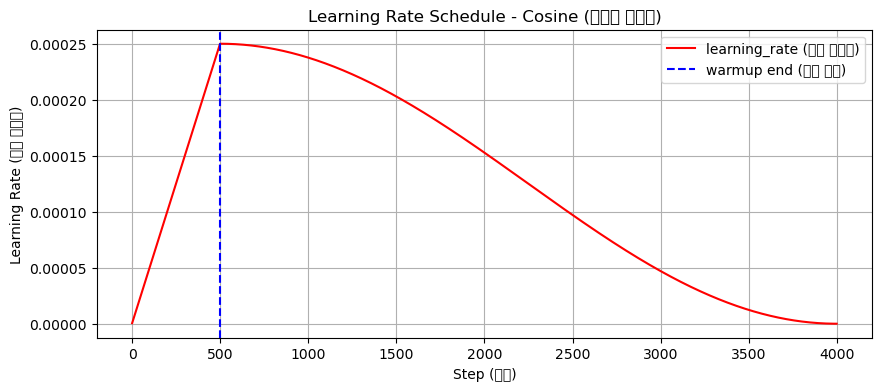

step 0   lr (러닝 레이트): 0.000000
step 250 lr (러닝 레이트): 0.000125
step 500 lr (러닝 레이트): 0.000250  ← warmup (웜업) 최대!
step 2000 lr (러닝 레이트): 0.000153
step 3999 lr (러닝 레이트): 0.000000  ← 거의 0!


In [59]:
# ================================================================
# CosineSchedule (코사인 스케줄) learning rate (러닝 레이트) 시각화
# ================================================================

# 테스트용 CosineSchedule (코사인 스케줄) 생성
test_schedule = CosineSchedule(
    train_steps=4000,    # 총 학습 step (스텝) 수
    warmup_steps=500     # warmup (웜업) step (스텝) 수
)

# 4000 step (스텝) 동안 lr (러닝 레이트) 계산
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())   # 매 step (스텝) 마다 lr (러닝 레이트) 저장

# -------------------------------------------------------
# 그래프 시각화 visualization (비주얼라이제이션)
# -------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(lrs, 'r-', label='learning_rate (러닝 레이트)')

# warmup (웜업) 구간 표시
plt.axvline(x=500, color='b', linestyle='--', label='warmup end (웜업 종료)')

plt.xlabel('Step (스텝)')
plt.ylabel('Learning Rate (러닝 레이트)')
plt.legend()
plt.title('Learning Rate Schedule - Cosine (코사인 스케줄)')
plt.grid(True)
plt.show()

# lr (러닝 레이트) 주요 값 확인
print(f"step 0   lr (러닝 레이트): {lrs[0]:.6f}")
print(f"step 250 lr (러닝 레이트): {lrs[249]:.6f}")
print(f"step 500 lr (러닝 레이트): {lrs[499]:.6f}  ← warmup (웜업) 최대!")
print(f"step 2000 lr (러닝 레이트): {lrs[1999]:.6f}")
print(f"step 3999 lr (러닝 레이트): {lrs[3998]:.6f}  ← 거의 0!")

## torchinfo (토치인포) 설치

- torchinfo (토치인포): 모델 구조 요약 summary (서머리) 출력 라이브러리
- torchsummary (토치서머리) 보다 더 상세한 정보 제공
- 파라미터 수, 각 레이어 output shape (아웃풋 쉐이프) 확인 가능

In [60]:
# ================================================================
# torchinfo (토치인포) 설치
# 모델 구조 및 파라미터 수 확인용
# ================================================================

!pip install torchinfo

In [61]:
# 설치 완료 후 import (임포트)
from torchinfo import summary

# 모델 구조 확인
summary(
    model,
    input_data=[
        enc_tokens_batch,    # enc_tokens (인코더 토큰스)
        segments_batch       # segments (세그먼츠)
    ]
)

# 예상 출력
# ================================================================
# Layer (type)         Output Shape         Param #
# ================================================================
# SharedEmbedding      [5, 10, 128]         640,000
# PositionEmbedding    [5, 10, 128]         32,768
# ...
# Total params: ~1,000,000   ← 목표 1M (원 엠)! ✅
# ================================================================

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [5, 2]                    --
├─BERT: 1-1                                                  [5, 128]                  --
│    └─SharedEmbedding: 2-1                                  [5, 10, 128]              640,000
│    └─PositionEmbedding: 2-2                                [5, 10, 128]              --
│    │    └─Embedding: 3-1                                   [5, 10, 128]              32,768
│    └─Embedding: 2-3                                        [5, 10, 128]              256
│    └─LayerNorm: 2-4                                        [5, 10, 128]              256
│    └─Dropout: 2-5                                          [5, 10, 128]              --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [5, 10, 128]           

## 실제 Pretrain (프리트레인) 모델 생성 & GPU (지피유) 설정

- config.n_seq (컨피그 엔 시퀀스) = 128: 실제 BERT (버트) 학습용 시퀀스 길이로 변경
- GPU (지피유) 사용 가능하면 cuda (쿠다), 없으면 cpu (씨피유) 사용
- summary (서머리): 실제 128 시퀀스 길이로 모델 구조 확인

In [62]:
# ================================================================
# 실제 Pretrain (프리트레인) 모델 생성 & GPU (지피유) 설정
# ================================================================
from torchinfo import summary

# n_seq (엔 시퀀스) 를 실제 학습용 128로 변경
config.n_seq = 128

# PreTrainModel (프리트레인 모델) 생성
pre_train_model = build_model_pre_train(config)

# -------------------------------------------------------
# GPU (지피유) 설정
# cuda (쿠다) 사용 가능하면 GPU (지피유), 아니면 CPU (씨피유)
# -------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 device (디바이스): {device}")

# 모델을 device (디바이스) 로 이동
pre_train_model.to(device)

# -------------------------------------------------------
# 모델 구조 확인용 테스트 입력 생성
# -------------------------------------------------------
enc_tokens_example = torch.randint(
    0, config.n_vocab,
    (10, config.n_seq),
    dtype=torch.long
).to(device)

segments_example = torch.randint(
    0, 2,
    (10, config.n_seq),
    dtype=torch.long
).to(device)

# -------------------------------------------------------
# 모델 구조 요약 summary (서머리) 출력
# -------------------------------------------------------
summary(
    pre_train_model,
    [(10, config.n_seq),    # enc_tokens (인코더 토큰스) shape (쉐이프)
     (10, config.n_seq)]    # segments (세그먼츠) shape (쉐이프)
)

사용 device (디바이스): cuda


Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            640,000
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]         

## Pretrain (프리트레인) 학습 설정

### 학습 파라미터 설정
- epochs (에포크): 2 → 전체 데이터 2번 반복
- batch_size (배치 사이즈): 64 → 한 번에 64개씩 학습
- train_steps (트레인 스텝): 전체 데이터 수 / batch_size (배치 사이즈) × epochs (에포크)
- warmup_steps (웜업 스텝): max(100, train_steps // 10) → 최소 100, 최대 10%

### CosineSchedule (코사인 스케줄) 설정
- train_steps (트레인 스텝): 전체 학습 step (스텝) 수
- warmup_steps (웜업 스텝): 전체의 10% 또는 최소 100 step (스텝)

### Loss Function (로스 펑션) & Optimizer (옵티마이저)
- CrossEntropyLoss (크로스 엔트로피 로스): NSP (엔에스피) + MLM (엠엘엠) 각각
- Adam (아담) optimizer (옵티마이저): lr=1e-4

In [63]:
# ================================================================
# Pretrain (프리트레인) 학습 설정
# ================================================================

epochs     = 2    # 전체 데이터 반복 횟수
batch_size = 64   # 배치 크기

# -------------------------------------------------------
# train_steps (트레인 스텝) 계산
# 전체 데이터 수 / batch_size (배치 사이즈) × epochs (에포크)
# math.ceil (매스 씰): 올림 처리 (나머지 배치 포함)
# -------------------------------------------------------
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print(f"train_steps (트레인 스텝): {train_steps}")
print(f"전체 데이터 수: {len(pre_train_inputs[0]):,}")
print(f"배치 수 per epoch (퍼 에포크): {math.ceil(len(pre_train_inputs[0]) / batch_size)}")

# -------------------------------------------------------
# CosineSchedule (코사인 스케줄) 설정
# warmup_steps (웜업 스텝): 최소 100, 최대 train_steps (트레인 스텝) 의 10%
# -------------------------------------------------------
learning_rate_scheduler = CosineSchedule(
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10)   # 최소 100 step (스텝) 보장
)

print(f"warmup_steps (웜업 스텝): {max(100, train_steps // 10)}")

# -------------------------------------------------------
# Optimizer (옵티마이저): Adam (아담)
# -------------------------------------------------------
optimizer = optim.Adam(
    pre_train_model.parameters(),
    lr=1e-4    # 초기 learning rate (러닝 레이트)
)

# -------------------------------------------------------
# Loss Function (로스 펑션): CrossEntropyLoss (크로스 엔트로피 로스)
# -------------------------------------------------------
loss_fn_nsp = nn.CrossEntropyLoss()   # NSP (엔에스피) 손실
loss_fn_mlm = nn.CrossEntropyLoss()   # MLM (엠엘엠) 손실

print(f"\n학습 설정 확인:")
print(f"epochs (에포크)     : {epochs}")
print(f"batch_size (배치 사이즈): {batch_size}")
print(f"train_steps (트레인 스텝): {train_steps}")
print(f"optimizer (옵티마이저)  : Adam (아담) lr=1e-4")

train_steps (트레인 스텝): 4000
전체 데이터 수: 128,000
배치 수 per epoch (퍼 에포크): 2000
warmup_steps (웜업 스텝): 400

학습 설정 확인:
epochs (에포크)     : 2
batch_size (배치 사이즈): 64
train_steps (트레인 스텝): 4000
optimizer (옵티마이저)  : Adam (아담) lr=1e-4


## BERT (버트) Pretrain (프리트레인) 학습 루프

### 학습 흐름
1. 데이터를 GPU (지피유) 로 이동 → TensorDataset (텐서데이터셋) + DataLoader (데이터로더) 생성
2. 매 batch (배치) 마다:
   - forward (포워드): logits_nsp (로짓츠 엔에스피), logits_mlm (로짓츠 엠엘엠) 계산
   - loss_nsp (로스 엔에스피) + loss_mlm (로스 엠엘엠) 계산
   - backward (백워드) + optimizer.step (옵티마이저 스텝)
   - nsp_acc (엔에스피 어큐러시) + mlm_acc (엠엘엠 어큐러시) 계산
3. 매 epoch (에포크) 마다:
   - history (히스토리) 에 loss (로스) / accuracy (어큐러시) 저장
   - 모델 저장 (.pt 파일)

### history (히스토리) 딕셔너리
- nsp_loss (엔에스피 로스): NSP (엔에스피) 손실
- mlm_loss (엠엘엠 로스): MLM (엠엘엠) 손실
- nsp_acc (엔에스피 어큐러시): NSP (엔에스피) 정확도
- mlm_acc (엠엘엠 어큐러시): MLM (엠엘엠) 정확도

In [64]:
# ================================================================
# BERT (버트) Pretrain (프리트레인) 학습 루프
# NSP (엔에스피) + MLM (엠엘엠) 동시 학습!
# ================================================================

# -------------------------------------------------------
# 데이터를 GPU (지피유) 로 이동
# -------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 device (디바이스): {device}")

# numpy (넘파이) 배열 → tensor (텐서) → GPU (지피유) 이동
pre_train_inputs = [
    torch.tensor(np.array(x)).to(device)
    for x in pre_train_inputs
]
pre_train_labels = [
    torch.tensor(np.array(x)).to(device)
    for x in pre_train_labels
]

# -------------------------------------------------------
# TensorDataset (텐서데이터셋) & DataLoader (데이터로더) 생성
# -------------------------------------------------------
train_dataset = TensorDataset(
    pre_train_inputs[0],    # enc_tokens (인코더 토큰스)
    pre_train_inputs[1],    # segments (세그먼츠)
    pre_train_labels[0],    # labels_nsp (레이블스 엔에스피)
    pre_train_labels[1]     # labels_mlm (레이블스 엠엘엠)
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True             # 매 epoch (에포크) 마다 순서 섞기
)

# 모델을 GPU (지피유) 로 이동
pre_train_model.to(device)

# -------------------------------------------------------
# 학습 기록 history (히스토리) 초기화
# -------------------------------------------------------
history = {
    'nsp_loss': [],    # NSP (엔에스피) 손실
    'mlm_loss': [],    # MLM (엠엘엠) 손실
    'nsp_acc' : [],    # NSP (엔에스피) 정확도
    'mlm_acc' : []     # MLM (엠엘엠) 정확도
}

# ================================================================
# 학습 루프 Training Loop (트레이닝 루프)
# ================================================================
for epoch in range(epochs):

    pre_train_model.train()    # 학습 모드 dropout (드롭아웃) 활성화

    total_loss     = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc  = 0
    total_mlm_acc  = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch (에포크) {epoch+1}/{epochs}"):

        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        # -------------------------------------------------------
        # gradient (그래디언트) 초기화
        # -------------------------------------------------------
        optimizer.zero_grad()

        # -------------------------------------------------------
        # forward (포워드): 모델 실행
        # -------------------------------------------------------
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        # label (레이블) 타입 변환
        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()  # vocab (보캡) 범위 제한

        # -------------------------------------------------------
        # Loss (로스) 계산
        # -------------------------------------------------------
        loss_nsp = loss_fn_nsp(
            logits_nsp,
            labels_nsp_batch
        )
        loss_mlm = loss_fn_mlm(
            logits_mlm.view(-1, logits_mlm.shape[-1]),  # (bs × n_seq, n_vocab)
            labels_mlm_batch.view(-1)                   # (bs × n_seq,)
        )

        total_loss_batch = loss_nsp + loss_mlm
        total_loss     += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # -------------------------------------------------------
        # Backpropagation (백프로퍼게이션) + 파라미터 업데이트
        # -------------------------------------------------------
        total_loss_batch.backward()
        optimizer.step()

        # -------------------------------------------------------
        # Accuracy (어큐러시) 계산
        # -------------------------------------------------------
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # -------------------------------------------------------
    # epoch (에포크) 결과 저장 & 출력
    # -------------------------------------------------------
    n_batch = len(train_dataloader)

    history['nsp_loss'].append(total_nsp_loss / n_batch)
    history['mlm_loss'].append(total_mlm_loss / n_batch)
    history['nsp_acc'].append(total_nsp_acc  / n_batch)
    history['mlm_acc'].append(total_mlm_acc  / n_batch)

    print(
        f"Epoch (에포크) {epoch+1}/{epochs} "
        f"| Loss (로스): {total_loss / n_batch:.4f} "
        f"| NSP Loss (엔에스피 로스): {total_nsp_loss / n_batch:.4f} "
        f"| MLM Loss (엠엘엠 로스): {total_mlm_loss / n_batch:.4f} "
        f"| NSP Acc (엔에스피 어큐러시): {total_nsp_acc / n_batch:.4f} "
        f"| MLM Acc (엠엘엠 어큐러시): {total_mlm_acc / n_batch:.4f}"
    )

    # -------------------------------------------------------
    # 모델 저장
    # -------------------------------------------------------
    torch.save(
        pre_train_model.state_dict(),
        f"work/bert_pre_train_epoch_{epoch+1}.pt"
    )
    print(f"모델 저장 완료: work/bert_pre_train_epoch_{epoch+1}.pt ✅")

사용 device (디바이스): cuda


Epoch (에포크) 1/2:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch (에포크) 1/2 | Loss (로스): 8.4114 | NSP Loss (엔에스피 로스): 0.6613 | MLM Loss (엠엘엠 로스): 7.7501 | NSP Acc (엔에스피 어큐러시): 0.6022 | MLM Acc (엠엘엠 어큐러시): 0.8432


RuntimeError: Parent directory work does not exist.

In [65]:
# ================================================================
# 모델 저장 (학습은 이미 완료! 저장만 다시 하면 됨)
# ================================================================
import os

# 저장 폴더 생성
save_dir = os.path.expanduser('~/work/bert_pretrain/models')
os.makedirs(save_dir, exist_ok=True)

# 모델 저장
save_path = f"{save_dir}/bert_pre_train_epoch_1.pt"
torch.save(pre_train_model.state_dict(), save_path)
print(f"모델 저장 완료: {save_path} ✅")

모델 저장 완료: /home/jovyan/work/bert_pretrain/models/bert_pre_train_epoch_1.pt ✅


## 학습 결과 시각화 Visualization (비주얼라이제이션)

- 왼쪽 그래프: NSP (엔에스피) + MLM (엠엘엠) Loss (로스) 변화
- 오른쪽 그래프: NSP (엔에스피) + MLM (엠엘엠) Accuracy (어큐러시) 변화
- Loss (로스) 감소 + Accuracy (어큐러시) 증가 → 정상 학습!

/tmp/ipykernel_467/447877810.py:33: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/447877810.py:33: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/447877810.py:33: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/447877810.py:33: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/447877810.py:33: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/447877810.py:33: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_467/447877810.py:33: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyker

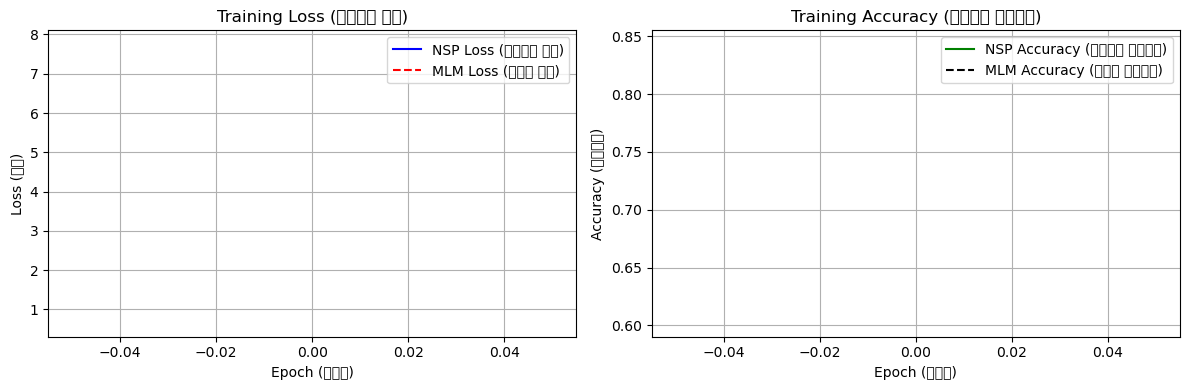


최종 학습 결과:
NSP Loss (엔에스피 로스)      : 0.6613
MLM Loss (엠엘엠 로스)        : 7.7501
NSP Accuracy (엔에스피 어큐러시): 0.6022
MLM Accuracy (엠엘엠 어큐러시) : 0.8432


In [66]:
# ================================================================
# 학습 결과 시각화 visualization (비주얼라이제이션)
# Loss (로스) & Accuracy (어큐러시) 그래프
# ================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# -------------------------------------------------------
# 왼쪽 그래프: Loss (로스) 변화
# -------------------------------------------------------
plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-',  label='NSP Loss (엔에스피 로스)')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss (엠엘엠 로스)')
plt.xlabel('Epoch (에포크)')
plt.ylabel('Loss (로스)')
plt.title('Training Loss (트레이닝 로스)')
plt.legend()
plt.grid(True)

# -------------------------------------------------------
# 오른쪽 그래프: Accuracy (어큐러시) 변화
# -------------------------------------------------------
plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-',  label='NSP Accuracy (엔에스피 어큐러시)')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy (엠엘엠 어큐러시)')
plt.xlabel('Epoch (에포크)')
plt.ylabel('Accuracy (어큐러시)')
plt.title('Training Accuracy (트레이닝 어큐러시)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 최종 결과 출력
print(f"\n최종 학습 결과:")
print(f"NSP Loss (엔에스피 로스)      : {history['nsp_loss'][-1]:.4f}")
print(f"MLM Loss (엠엘엠 로스)        : {history['mlm_loss'][-1]:.4f}")
print(f"NSP Accuracy (엔에스피 어큐러시): {history['nsp_acc'][-1]:.4f}")
print(f"MLM Accuracy (엠엘엠 어큐러시) : {history['mlm_acc'][-1]:.4f}")

# 6강. 프로젝트 : mini BERT (미니 버트) 만들기

### 목표
- vocab size (보캡 사이즈): 8,000 (기존 32,007 → 축소!)
- 전체 파라미터 수: 약 1M (원 엠) = 1,000,000개
- 학습: 10 epoch (에포크)

### 기존 BERT (버트) 와 비교
| 항목 | 정식 BERT (버트) | mini BERT (미니 버트) |
|---|---|---|
| vocab size (보캡 사이즈) | 32,007 | 8,000 |
| parameters (파라미터) | 340M | ~1M |
| epochs (에포크) | 수백만 step | 10 epoch |
| 학습 시간 | 수일~수주 | 수시간 |

### 라이브러리 버전 확인
- torch (파이토치): 딥러닝 프레임워크
- numpy (넘파이): 수치 계산
- pandas (판다스): 데이터 처리
- matplotlib (맷플롯립): 시각화
- json (제이슨): JSON (제이슨) 파일 처리
- re (알이): 정규표현식 regex (레젝스)

In [67]:
# ================================================================
# 사용 라이브러리 버전 확인
# ================================================================

import torch
import numpy
import pandas
import matplotlib
import json
import re

print(f"torch (파이토치)      : {torch.__version__}")
print(f"numpy (넘파이)        : {numpy.__version__}")
print(f"pandas (판다스)       : {pandas.__version__}")
print(f"matplotlib (맷플롯립) : {matplotlib.__version__}")
print(f"json (제이슨)         : {json.__version__}")
print(f"re (알이)             : {re.__version__}")

# GPU (지피유) 확인
print(f"\nGPU (지피유) 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU (지피유) 이름     : {torch.cuda.get_device_name(0)}")

torch (파이토치)      : 2.7.1+cu118
numpy (넘파이)        : 2.2.6
pandas (판다스)       : 2.3.0
matplotlib (맷플롯립) : 3.10.3
json (제이슨)         : 2.0.9
re (알이)             : 2.2.1

GPU (지피유) 사용 가능: True
GPU (지피유) 이름     : Tesla T4


## 프로젝트 Step 1. Tokenizer (토크나이저) 준비

### 목표
- vocab_size (보캡 사이즈): 8,000 (기존 32,000 → 축소!)
- 특수토큰 special token (스페셜 토큰) 7개 포함
  - [PAD] (패드) id=0 / [UNK] (언크) id=1
  - [BOS] (보스) id=2 / [EOS] (이오에스) id=3
  - [SEP] (셉) id=4 / [CLS] (클스) id=5 / [MASK] (마스크) id=6
- 저장 경로: data/ko_8000.model, data/ko_8000.vocab

In [68]:
# ================================================================
# mini BERT (미니 버트) 용 SentencePiece (센텐스피스) 모델 생성
# vocab_size (보캡 사이즈): 8,000
# ================================================================
import sentencepiece as spm
import os

# 경로 설정
corpus_file = os.path.expanduser('~/work/bert_pretrain/data/kowiki.txt')
prefix      = os.path.expanduser('~/work/bert_pretrain/data/ko_8000')
vocab_size  = 8000

# 파일 존재 확인
print(f"kowiki.txt 존재: {os.path.exists(corpus_file)}")

# -------------------------------------------------------
# 이미 만들어진 파일 있으면 스킵 skip (스킵)!
# -------------------------------------------------------
if os.path.exists(f"{prefix}.model"):
    print("ko_8000.model 이미 존재! 스킵 ✅")
else:
    print("ko_8000.model 생성 시작... (약 20~30분 소요)")

    # SentencePiece (센텐스피스) 모델 학습
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} "
        f"--model_prefix={prefix} "
        f"--vocab_size={vocab_size + 7} "       # 8000 + 특수토큰 7개
        f"--model_type=bpe "                    # BPE (비피이) 방식
        f"--max_sentence_length=999999 "
        f"--num_threads=8 "                     # 멀티쓰레드 multi-thread (멀티쓰레드)
        f"--pad_id=0 --pad_piece=[PAD] "
        f"--unk_id=1 --unk_piece=[UNK] "
        f"--bos_id=2 --bos_piece=[BOS] "
        f"--eos_id=3 --eos_piece=[EOS] "
        f"--user_defined_symbols=[SEP],[CLS],[MASK]"
    )
    print("완료! ko_8000.model, ko_8000.vocab 생성됨 ✅")

# -------------------------------------------------------
# vocab (보캡) 로딩 확인
# -------------------------------------------------------
vocab_8000 = spm.SentencePieceProcessor()
vocab_8000.load(f"{prefix}.model")

print(f"\nvocab size (보캡 사이즈): {vocab_8000.get_piece_size()}")  # 8007 이어야 함!

# 특수토큰 확인
for i in range(7):
    print(f"id {i}: {vocab_8000.id_to_piece(i)}")

kowiki.txt 존재: True
ko_8000.model 생성 시작... (약 20~30분 소요)
완료! ko_8000.model, ko_8000.vocab 생성됨 ✅

vocab size (보캡 사이즈): 8007
id 0: [PAD]
id 1: [UNK]
id 2: [BOS]
id 3: [EOS]
id 4: [SEP]
id 5: [CLS]
id 6: [MASK]


## 프로젝트 Step 2. 데이터 전처리 - (1) MASK (마스크) 생성

### MLM (엠엘엠) 마스킹 규칙
- 전체 token (토큰) 의 **15%** 선택
- 선택된 15% 중:
  - **80%** → [MASK] (마스크) 토큰으로 교체
  - **10%** → 랜덤 random (랜덤) 토큰으로 교체
  - **10%** → 원래 token (토큰) 그대로 유지
- [CLS] (클스), [SEP] (셉) 특수토큰 마스킹 제외!
- 띄어쓰기 단위 Whole Word Masking (홀 워드 마스킹) 적용

In [69]:
# ================================================================
# mini BERT (미니 버트) 용 vocab (보캡) 로딩
# ================================================================
import sentencepiece as spm
import os

# ko_8000 vocab (보캡) 로딩
data_dir   = os.path.expanduser('~/work/bert_pretrain/data')
vocab_8000 = spm.SentencePieceProcessor()
vocab_8000.load(f"{data_dir}/ko_8000.model")

print(f"vocab size (보캡 사이즈): {vocab_8000.get_piece_size()}")  # 8007

# -------------------------------------------------------
# vocab_list (보캡 리스트) 생성 (특수토큰 7개 제외)
# -------------------------------------------------------
vocab_list_8000 = []
for id in range(7, len(vocab_8000)):
    if not vocab_8000.is_unknown(id):
        vocab_list_8000.append(vocab_8000.id_to_piece(id))

print(f"vocab_list (보캡 리스트) 크기: {len(vocab_list_8000)}")


# ================================================================
# create_pretrain_mask (크리에이트 프리트레인 마스크) 함수 재사용
# (앞에서 정의한 함수 그대로 사용!)
# ================================================================

# 테스트용 문장
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔"

# BERT (버트) 입력 형식으로 토크나이징
tokens_org = (
    ["[CLS]"]
    + vocab_8000.encode_as_pieces(string_a)
    + ["[SEP]"]
    + vocab_8000.encode_as_pieces(string_b)
    + ["[SEP]"]
)

print(f"\n원본 tokens (토큰스): {tokens_org}")
print(f"전체 token (토큰) 수: {len(tokens_org)}")

# -------------------------------------------------------
# 마스킹 적용
# -------------------------------------------------------
tokens_test = copy.deepcopy(tokens_org)
mask_cnt    = int((len(tokens_org) - 3) * 0.15)   # 15% 계산

tokens_masked, mask_idx, mask_label = create_pretrain_mask(
    tokens_test,
    mask_cnt,
    vocab_list_8000
)

print(f"\n마스킹 후 tokens (토큰스): {tokens_masked}")
print(f"mask_idx   : {mask_idx}")
print(f"mask_label : {mask_label}")
print(f"마스킹된 token (토큰) 수: {len(mask_idx)} ({mask_cnt} 목표)")

vocab size (보캡 사이즈): 8007
vocab_list (보캡 리스트) 크기: 8000

원본 tokens (토큰스): ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']
전체 token (토큰) 수: 49

마스킹 후 tokens (토큰스): ['[CLS]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '[MASK]', '[MASK]', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']
mask_idx   : [1, 2, 3, 4, 27, 28]
mask_label : ['▁추', '적', '추', '적', '▁위', '엔']
마스킹된 token (토큰) 수: 6 (6 목표)


## 프로젝트 Step 2. 데이터 전처리 - (2) NSP pair (엔에스피 페어) 생성

### NSP (엔에스피) 데이터 구성 규칙
- 50% → IsNext (이즈넥스트) TRUE: 실제 이어지는 문장 쌍
- 50% → NotNext (낫넥스트) FALSE: 랜덤 random (랜덤) 문장 쌍 (swap (스왑))
- 입력 형식: [CLS] + 문장A + [SEP] + 문장B + [SEP]
- segment (세그먼트): 문장A = 0, 문장B = 1

### MLM (엠엘엠) + NSP (엔에스피) 동시 학습
- 같은 데이터에 마스킹 masking (마스킹) + NSP (엔에스피) 레이블 동시 적용
- instance (인스턴스) 구성:
  - tokens (토큰스): 마스킹 적용된 token (토큰) 리스트
  - segment (세그먼트): 문장 구분 (0/1)
  - is_next (이즈넥스트): NSP (엔에스피) 레이블 (1=TRUE, 0=FALSE)
  - mask_idx (마스크 인덱스): 마스킹된 위치
  - mask_label (마스크 레이블): 마스킹된 원래 token (토큰)

In [70]:
# ================================================================
# mini BERT (미니 버트) 용 pretrain (프리트레인) 데이터 생성
# NSP (엔에스피) + MLM (엠엘엠) 동시 적용!
# ================================================================

# -------------------------------------------------------
# pretrain (프리트레인) JSON (제이슨) 데이터 생성
# ko_8000 vocab (보캡) 사용!
# -------------------------------------------------------
corpus_file    = os.path.expanduser('~/work/bert_pretrain/data/kowiki.txt')
pretrain_json  = os.path.expanduser('~/work/bert_pretrain/data/kowiki_mini_bert.json')

# 이미 파일 있으면 스킵 skip (스킵)!
if os.path.exists(pretrain_json):
    print(f"이미 존재! 스킵 skip (스킵) ✅")
    print(f"파일: {pretrain_json}")
else:
    print("pretrain (프리트레인) 데이터 생성 시작...")
    make_pretrain_data(
        vocab_8000,       # ko_8000 vocab (보캡)
        corpus_file,      # kowiki.txt (코위키 텍스트)
        pretrain_json,    # 저장할 JSON (제이슨) 파일
        128,              # n_seq (엔 시퀀스) = 128
        0.15              # 마스킹 확률 15%
    )
    print(f"완료! ✅")

# -------------------------------------------------------
# 생성된 데이터 확인
# -------------------------------------------------------
print(f"\n파일 크기: {os.path.getsize(pretrain_json) / (1024**2):.1f} MB")

# 첫 번째 instance (인스턴스) 확인
with open(pretrain_json, 'r') as f:
    first_instance = json.loads(f.readline())

print(f"\n첫 번째 instance (인스턴스) 확인:")
print(f"tokens     : {first_instance['tokens'][:10]}...")
print(f"segment    : {first_instance['segment'][:10]}...")
print(f"is_next    : {first_instance['is_next']} ← {'IsNext (TRUE)' if first_instance['is_next'] == 1 else 'NotNext (FALSE)'}")
print(f"mask_idx   : {first_instance['mask_idx']}")
print(f"mask_label : {first_instance['mask_label']}")

pretrain (프리트레인) 데이터 생성 시작...
vocab_list (보캡 리스트) 생성 완료: 8000개
전체 line (라인) 수: 3,957,761


  0%|          | 0/3957761 [00:00<?, ?it/s]

저장 완료! → /home/jovyan/work/bert_pretrain/data/kowiki_mini_bert.json ✅
완료! ✅

파일 크기: 1320.9 MB

첫 번째 instance (인스턴스) 확인:
tokens     : ['[CLS]', '일', '▁~', '▁)', '는', '▁민주', '당', '[MASK]', '▁미국', '雨']...
segment    : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
is_next    : 0 ← NotNext (FALSE)
mask_idx   : [7, 9, 10, 11, 12, 33, 34, 41, 42, 43, 44, 52, 71, 72, 73, 81, 82, 83]
mask_label : ['▁출신', '▁3', '9', '번째', '▁대통령', '▁카운', '티', '▁태어났다', '.', '▁조지', '아', '▁그', '▁일', '하였다', '.', '▁예', '편', '하였고']


In [71]:
# ================================================================
# NSP (엔에스피) + MLM (엠엘엠) 동시 적용 테스트
# ================================================================

# 테스트용 doc (닥) 생성
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔"""

# ko_8000 (코 8000) 으로 토크나이징
doc_test = [vocab_8000.encode_as_pieces(line) for line in string.split("\n")]

# instance (인스턴스) 생성
instances_test = create_pretrain_instances(
    vocab_8000,       # ko_8000 vocab (보캡)
    doc_test,         # 테스트 doc (닥)
    128,              # n_seq (엔 시퀀스)
    0.15,             # 마스킹 확률
    vocab_list_8000   # vocab_list (보캡 리스트)
)

print(f"생성된 instance (인스턴스) 수: {len(instances_test)}\n")
for i, instance in enumerate(instances_test):
    print(f"{'='*50}")
    print(f"instance (인스턴스) [{i}]")
    print(f"is_next    : {instance['is_next']} ← {'IsNext (TRUE)' if instance['is_next']==1 else 'NotNext (FALSE)'}")
    print(f"tokens     : {instance['tokens'][:8]}...")
    print(f"segment    : {instance['segment'][:8]}...")
    print(f"mask_idx   : {instance['mask_idx']}")
    print(f"mask_label : {instance['mask_label']}")
    print()

생성된 instance (인스턴스) 수: 1

instance (인스턴스) [0]
is_next    : 1 ← IsNext (TRUE)
tokens     : ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내']...
segment    : [0, 0, 0, 0, 0, 0, 0, 0]...
mask_idx   : [23, 38, 39, 40, 62, 63, 64, 65, 66, 67, 68]
mask_label : ['▁첫', '▁받아', '보', '는', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에']



## 프로젝트 Step 2. 데이터 전처리 - (3) 데이터셋 Dataset (데이터셋) 완성

### 전체 파이프라인 Pipeline (파이프라인)
1. make_pretrain_data (메이크 프리트레인 데이터): kowiki.txt → JSON (제이슨) 저장
2. load_pre_train_data (로드 프리 트레인 데이터): JSON (제이슨) → np.memmap (넘파이 멤맵) 로딩

### np.memmap (넘파이 멤맵) 사용 이유
- 전체 데이터를 RAM (램) 에 올리면 메모리 부족!
- 디스크 disk (디스크) 에 저장하면서 필요한 부분만 메모리에 로드 load (로드)
- 대용량 데이터 처리 가능!

### 저장 파일 목록
- kowiki_mini_bert.json: pretrain (프리트레인) 데이터 JSON (제이슨)
- enc_tokens.memmap: 입력 token ID (토큰 아이디)
- segments.memmap: segment (세그먼트) 배열
- labels_nsp.memmap: NSP (엔에스피) 레이블
- labels_mlm.memmap: MLM (엠엘엠) 레이블

In [72]:
# ================================================================
# Step 1. kowiki.txt → pretrain (프리트레인) JSON (제이슨) 생성
# ================================================================
import os
import json
import numpy as np

corpus_file   = os.path.expanduser('~/work/bert_pretrain/data/kowiki.txt')
pretrain_json = os.path.expanduser('~/work/bert_pretrain/data/kowiki_mini_bert.json')

# 이미 파일 있으면 스킵 skip (스킵)!
if os.path.exists(pretrain_json):
    print(f"JSON (제이슨) 파일 이미 존재! 스킵 ✅")
else:
    print("JSON (제이슨) 데이터 생성 시작... (약 30분 소요)")
    make_pretrain_data(
        vocab_8000,       # ko_8000 vocab (보캡)
        corpus_file,      # 입력 corpus (코퍼스)
        pretrain_json,    # 출력 JSON (제이슨)
        128,              # n_seq (엔 시퀀스)
        0.15              # 마스킹 확률 15%
    )
    print(f"JSON (제이슨) 생성 완료! ✅")

print(f"파일 크기: {os.path.getsize(pretrain_json) / (1024**2):.1f} MB")


# ================================================================
# Step 2. JSON (제이슨) → np.memmap (넘파이 멤맵) 로딩
# 128,000건만 로딩 (메모리 절약!)
# ================================================================
n_seq    = 128
n_count  = 128000   # 로딩할 데이터 수

print(f"\nnp.memmap (넘파이 멤맵) 로딩 시작...")
print(f"n_seq (엔 시퀀스): {n_seq}, count (카운트): {n_count:,}")

pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab_8000,       # ko_8000 vocab (보캡)
    pretrain_json,    # JSON (제이슨) 파일
    n_seq,            # 시퀀스 길이
    count=n_count     # 128,000건만 로딩
)

# -------------------------------------------------------
# 로딩 결과 확인
# -------------------------------------------------------
enc_tokens, segments   = pre_train_inputs
labels_nsp, labels_mlm = pre_train_labels

print(f"\n배열 shape (쉐이프) 확인:")
print(f"enc_tokens  : {enc_tokens.shape}")    # (128000, 128)
print(f"segments    : {segments.shape}")      # (128000, 128)
print(f"labels_nsp  : {labels_nsp.shape}")    # (128000,)
print(f"labels_mlm  : {labels_mlm.shape}")    # (128000, 128)

# -------------------------------------------------------
# 첫 번째 데이터 확인
# -------------------------------------------------------
print(f"\n첫 번째 데이터 확인:")
print(f"enc_tokens[0]  : {enc_tokens[0][:10]}...")
print(f"segments[0]    : {segments[0][:10]}...")
print(f"labels_nsp[0]  : {labels_nsp[0]} ← {'IsNext (TRUE)' if labels_nsp[0]==1 else 'NotNext (FALSE)'}")
print(f"labels_mlm[0]  : {labels_mlm[0][:10]}...")

# -------------------------------------------------------
# NSP (엔에스피) 레이블 분포 확인 (50:50 이어야 함!)
# -------------------------------------------------------
nsp_true  = (labels_nsp == 1).sum()
nsp_false = (labels_nsp == 0).sum()
print(f"\nNSP (엔에스피) 레이블 분포:")
print(f"IsNext (이즈넥스트)  TRUE  : {nsp_true:,} ({nsp_true/n_count*100:.1f}%)")
print(f"NotNext (낫넥스트) FALSE : {nsp_false:,} ({nsp_false/n_count*100:.1f}%)")

JSON (제이슨) 파일 이미 존재! 스킵 ✅
파일 크기: 1320.9 MB

np.memmap (넘파이 멤맵) 로딩 시작...
n_seq (엔 시퀀스): 128, count (카운트): 128,000
전체 데이터 수: 128,000


  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000

배열 shape (쉐이프) 확인:
enc_tokens  : (128000, 128)
segments    : (128000, 128)
labels_nsp  : (128000,)
labels_mlm  : (128000, 128)

첫 번째 데이터 확인:
enc_tokens[0]  : [   5 3629  203  241 3602 1114 3724    6  243 5672]...
segments[0]    : [0 0 0 0 0 0 0 0 0 0]...
labels_nsp[0]  : 0 ← NotNext (FALSE)
labels_mlm[0]  : [  0   0   0   0   0   0   0 788   0  49]...

NSP (엔에스피) 레이블 분포:
IsNext (이즈넥스트)  TRUE  : 63,608 (49.7%)
NotNext (낫넥스트) FALSE : 64,392 (50.3%)


## 프로젝트 Step 5. mini BERT (미니 버트) 모델 구현

### 구현 순서
1. 유틸리티 Utility (유틸리티) 함수
   - get_pad_mask (겟 패드 마스크): PAD (패드) 위치 마스킹
   - get_ahead_mask (겟 어헤드 마스크): 미래 token (토큰) 마스킹
   - gelu (젤루): 활성화 함수
   - kernel_initializer (커널 이니셜라이저): weight (웨이트) 초기화
   - Config (컨피그): JSON (제이슨) → 속성 접근

2. Embedding (임베딩) 레이어
   - SharedEmbedding (쉐어드 임베딩): token (토큰) embedding (임베딩) + MLM (엠엘엠) 출력 공유
   - PositionEmbedding (포지션 임베딩): 위치 정보
   - Segment Embedding (세그먼트 임베딩): 문장 구분

3. Transformer Encoder (트랜스포머 인코더) 레이어
   - ScaleDotProductAttention (스케일 닷 프로덕트 어텐션)
   - MultiHeadAttention (멀티헤드 어텐션)
   - PositionWiseFeedForward (포지션 와이즈 피드포워드)
   - EncoderLayer (인코더 레이어)

4. BERT (버트) + PreTrainModel (프리트레인 모델)

### mini BERT (미니 버트) 목표
- vocab_size (보캡 사이즈): 8,007
- 전체 파라미터: ~1M (원 엠)

In [73]:
# ================================================================
# mini BERT (미니 버트) 전체 모델 구현
# 앞에서 정의한 클래스들 재확인 & mini BERT (미니 버트) Config (컨피그) 설정
# ================================================================

# -------------------------------------------------------
# 1. 유틸리티 utility (유틸리티) 함수 확인
# -------------------------------------------------------
print("✅ get_pad_mask (겟 패드 마스크)")
print("✅ get_ahead_mask (겟 어헤드 마스크)")
print("✅ gelu (젤루)")
print("✅ kernel_initializer (커널 이니셜라이저)")
print("✅ Config (컨피그)")

# -------------------------------------------------------
# 2. mini BERT (미니 버트) Config (컨피그) 설정
# 목표: ~1M parameter (파라미터)!
# -------------------------------------------------------
mini_bert_config = Config({
    "n_vocab"           : vocab_8000.get_piece_size(),  # 8007
    "n_seq"             : 128,      # 시퀀스 sequence (시퀀스) 길이
    "d_model"           : 128,      # 임베딩 차원 dimension (디멘션)
    "n_head"            : 4,        # attention head (어텐션 헤드) 수
    "d_head"            : 32,       # 각 head (헤드) 차원 (d_model / n_head)
    "d_ff"              : 512,      # FFN (에프에프엔) 중간 차원
    "n_layer"           : 3,        # Encoder Layer (인코더 레이어) 수
    "dropout"           : 0.1,      # dropout (드롭아웃) 비율
    "layernorm_epsilon" : 1e-12,    # LayerNorm (레이어노름) epsilon (엡실론)
    "i_pad"             : 0         # PAD (패드) token ID (토큰 아이디)
})

print(f"\nmini BERT (미니 버트) Config (컨피그) 설정 완료!")
print(f"n_vocab (엔 보캡)  : {mini_bert_config.n_vocab}")
print(f"d_model (디 모델)  : {mini_bert_config.d_model}")
print(f"n_head (엔 헤드)   : {mini_bert_config.n_head}")
print(f"d_head (디 헤드)   : {mini_bert_config.d_head}")
print(f"d_ff (디 에프에프) : {mini_bert_config.d_ff}")
print(f"n_layer (엔 레이어): {mini_bert_config.n_layer}")
print(f"n_seq (엔 시퀀스)  : {mini_bert_config.n_seq}")

# -------------------------------------------------------
# 3. mini BERT (미니 버트) 모델 생성
# -------------------------------------------------------
mini_bert_model = build_model_pre_train(mini_bert_config)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mini_bert_model.to(device)
print(f"\n사용 device (디바이스): {device}")

# -------------------------------------------------------
# 4. 모델 구조 & 파라미터 수 확인
# -------------------------------------------------------
from torchinfo import summary

summary(
    mini_bert_model,
    [(10, mini_bert_config.n_seq),    # enc_tokens (인코더 토큰스)
     (10, mini_bert_config.n_seq)]    # segments (세그먼츠)
)

✅ get_pad_mask (겟 패드 마스크)
✅ get_ahead_mask (겟 어헤드 마스크)
✅ gelu (젤루)
✅ kernel_initializer (커널 이니셜라이저)
✅ Config (컨피그)

mini BERT (미니 버트) Config (컨피그) 설정 완료!
n_vocab (엔 보캡)  : 8007
d_model (디 모델)  : 128
n_head (엔 헤드)   : 4
d_head (디 헤드)   : 32
d_ff (디 에프에프) : 512
n_layer (엔 레이어): 3
n_seq (엔 시퀀스)  : 128

사용 device (디바이스): cuda


Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            1,024,896
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]       

## 프로젝트 Step 6. Pretrain (프리트레인) 진행

### 구현 순서
1. loss (로스) / accuracy (어큐러시) 함수 정의
2. CosineSchedule (코사인 스케줄) Learning Rate (러닝 레이트) 스케줄링
3. 10 epoch (에포크) 학습
4. 결과 시각화 visualization (비주얼라이제이션)

### 학습 설정
- epochs (에포크): 10
- batch_size (배치 사이즈): 64 (메모리 memory (메모리) 여유에 따라 조절!)
- optimizer (옵티마이저): Adam (아담)
- loss (로스): CrossEntropyLoss (크로스 엔트로피 로스)
- MLM loss (엠엘엠 로스) × 20 배 증가

사용 device (디바이스): cuda
전체 데이터 수    : 128,000
batch_size (배치 사이즈): 64
배치 수           : 2,000

train_steps (트레인 스텝) : 20,000
warmup_steps (웜업 스텝)  : 2,000


Epoch (에포크) 1/10:   0%|          | 0/2000 [00:00<?, ?it/s]


Epoch (에포크) 1/10 | Total Loss (토탈 로스): 24.1129 | NSP Loss (엔에스피 로스): 0.6630 | MLM Loss (엠엘엠 로스): 23.4498 | NSP Acc (엔에스피 어큐러시): 0.5947 | MLM Acc (엠엘엠 어큐러시): 0.0197 | LR (러닝 레이트): 0.000250
모델 저장: /home/jovyan/work/bert_pretrain/models/mini_bert_epoch_1.pt ✅


Epoch (에포크) 2/10:   0%|          | 0/2000 [00:00<?, ?it/s]


Epoch (에포크) 2/10 | Total Loss (토탈 로스): 24.0753 | NSP Loss (엔에스피 로스): 0.6583 | MLM Loss (엠엘엠 로스): 23.4170 | NSP Acc (엔에스피 어큐러시): 0.5983 | MLM Acc (엠엘엠 어큐러시): 0.0288 | LR (러닝 레이트): 0.000242
모델 저장: /home/jovyan/work/bert_pretrain/models/mini_bert_epoch_2.pt ✅


...


Epoch (에포크) 8/10 | Total Loss (토탈 로스): 24.0667 | NSP Loss (엔에스피 로스): 0.6498 | MLM Loss (엠엘엠 로스): 23.4169 | NSP Acc (엔에스피 어큐러시): 0.6305 | MLM Acc (엠엘엠 어큐러시): 0.0288 | LR (러닝 레이트): 0.000029
모델 저장: /home/jovyan/work/bert_pretrain/models/mini_bert_epoch_8.pt ✅


Epoch (에포크) 9/10:   0%|          | 0/2000 [00:00<?, ?it/s]


Epoch (에포크) 9/10 | Total Loss (토탈 로스): 24.0643 | NSP Loss (엔에스피 로스): 0.6474 | MLM Loss (엠엘엠 로스): 23.4169 | NSP Acc (엔에스피 어큐러시): 0.6375 | MLM Acc (엠엘엠 어큐러시): 0.0288 | LR (러닝 레이트): 0.000008
모델 저장: /home/jovyan/work/bert_pretrain/models/mini_bert_epoch_9.pt ✅


Epoch (에포크) 10/10:   0%|          | 0/2000 [00:00<?, ?it/s]


Epoch (에포크) 10/10 | Total Loss (토탈 로스): 24.0633 | NSP Loss (엔에스피 로스): 0.6464 | MLM Loss (엠엘엠 로스): 23.4169 | NSP Acc (엔에스피 어큐러시): 0.6389 | MLM Acc (엠엘엠 어큐러시): 0.0288 | LR (러닝 레이트): 0.000000
모델 저장: /home/jovyan/work/bert_pretrain/models/mini_bert_epoch_10.pt ✅


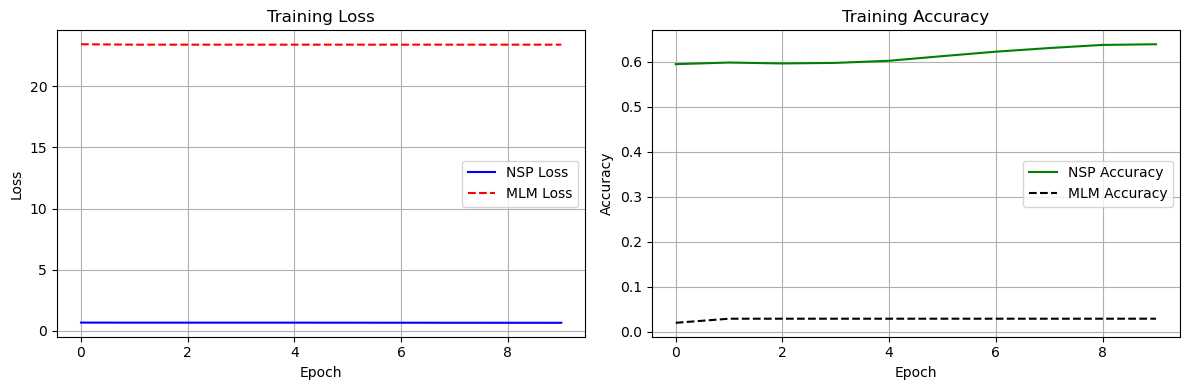


최종 학습 결과 (10 epoch (에포크)):
NSP Loss (엔에스피 로스)      : 0.6464
MLM Loss (엠엘엠 로스)        : 23.4169
NSP Accuracy (엔에스피 어큐러시): 0.6389
MLM Accuracy (엠엘엠 어큐러시) : 0.0288


In [74]:
# ================================================================
# mini BERT (미니 버트) Pretrain (프리트레인) 학습
# ================================================================
import math

# -------------------------------------------------------
# 1. 데이터 GPU (지피유) 로 이동 & DataLoader (데이터로더) 생성
# -------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 device (디바이스): {device}")

# numpy (넘파이) → tensor (텐서) → GPU (지피유)
mini_inputs = [
    torch.tensor(np.array(x)).to(device)
    for x in pre_train_inputs
]
mini_labels = [
    torch.tensor(np.array(x)).to(device)
    for x in pre_train_labels
]

# TensorDataset (텐서데이터셋) & DataLoader (데이터로더)
batch_size = 64   # 배치 크기 (GPU (지피유) 메모리에 따라 조절!)

mini_dataset = TensorDataset(
    mini_inputs[0],    # enc_tokens (인코더 토큰스)
    mini_inputs[1],    # segments (세그먼츠)
    mini_labels[0],    # labels_nsp (레이블스 엔에스피)
    mini_labels[1]     # labels_mlm (레이블스 엠엘엠)
)

mini_dataloader = DataLoader(
    mini_dataset,
    batch_size=batch_size,
    shuffle=True
)

print(f"전체 데이터 수    : {len(mini_dataset):,}")
print(f"batch_size (배치 사이즈): {batch_size}")
print(f"배치 수           : {len(mini_dataloader):,}")

# -------------------------------------------------------
# 2. 학습 설정
# -------------------------------------------------------
epochs      = 10   # 10 epoch (에포크) 학습!

train_steps = math.ceil(len(mini_inputs[0]) / batch_size) * epochs
warmup_steps = max(100, train_steps // 10)

print(f"\ntrain_steps (트레인 스텝) : {train_steps:,}")
print(f"warmup_steps (웜업 스텝)  : {warmup_steps:,}")

# CosineSchedule (코사인 스케줄)
lr_scheduler = CosineSchedule(
    train_steps=train_steps,
    warmup_steps=warmup_steps,
    max_lr=2.5e-4
)

# Optimizer (옵티마이저)
optimizer = optim.Adam(
    mini_bert_model.parameters(),
    lr=2.5e-4
)

# Loss Function (로스 펑션)
loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()

# -------------------------------------------------------
# 3. 학습 기록 history (히스토리) 초기화
# -------------------------------------------------------
history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc' : [],
    'mlm_acc' : []
}

# ================================================================
# 4. 학습 루프 Training Loop (트레이닝 루프) - 10 epoch (에포크)
# ================================================================
for epoch in range(epochs):

    mini_bert_model.train()

    total_loss     = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc  = 0
    total_mlm_acc  = 0

    for batch in tqdm(mini_dataloader, desc=f"Epoch (에포크) {epoch+1}/{epochs}"):

        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        # gradient (그래디언트) 초기화
        optimizer.zero_grad()

        # forward (포워드) 실행
        logits_nsp, logits_mlm = mini_bert_model(
            enc_tokens_batch, segments_batch
        )

        # label (레이블) 타입 변환
        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(
            0, mini_bert_config.n_vocab - 1
        ).long()

        # -------------------------------------------------------
        # Loss (로스) 계산
        # MLM (엠엘엠) loss (로스) × 20 배!
        # -------------------------------------------------------
        loss_nsp = loss_fn_nsp(
            logits_nsp,
            labels_nsp_batch
        )
        loss_mlm = lm_loss(
            labels_mlm_batch,           # y_true (와이 트루)
            logits_mlm                  # y_pred (와이 프레드) → × 20 배 적용!
        )

        total_loss_batch = loss_nsp + loss_mlm
        total_loss     += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # Backpropagation (백프로퍼게이션)
        total_loss_batch.backward()

        # Learning Rate (러닝 레이트) 업데이트
        lr = lr_scheduler.step()
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # 파라미터 업데이트
        optimizer.step()

        # -------------------------------------------------------
        # Accuracy (어큐러시) 계산
        # -------------------------------------------------------
        nsp_acc = (
            logits_nsp.argmax(dim=-1) == labels_nsp_batch
        ).float().mean()

        mlm_acc = lm_acc(labels_mlm_batch, logits_mlm)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # -------------------------------------------------------
    # epoch (에포크) 결과 저장 & 출력
    # -------------------------------------------------------
    n_batch = len(mini_dataloader)

    history['nsp_loss'].append(total_nsp_loss / n_batch)
    history['mlm_loss'].append(total_mlm_loss / n_batch)
    history['nsp_acc'].append(total_nsp_acc   / n_batch)
    history['mlm_acc'].append(total_mlm_acc   / n_batch)

    print(
        f"\nEpoch (에포크) {epoch+1}/{epochs} "
        f"| Total Loss (토탈 로스): {total_loss/n_batch:.4f} "
        f"| NSP Loss (엔에스피 로스): {total_nsp_loss/n_batch:.4f} "
        f"| MLM Loss (엠엘엠 로스): {total_mlm_loss/n_batch:.4f} "
        f"| NSP Acc (엔에스피 어큐러시): {total_nsp_acc/n_batch:.4f} "
        f"| MLM Acc (엠엘엠 어큐러시): {total_mlm_acc/n_batch:.4f} "
        f"| LR (러닝 레이트): {lr:.6f}"
    )

    # -------------------------------------------------------
    # 모델 저장 (매 epoch (에포크) 마다)
    # -------------------------------------------------------
    save_dir = os.path.expanduser('~/work/bert_pretrain/models')
    os.makedirs(save_dir, exist_ok=True)
    torch.save(
        mini_bert_model.state_dict(),
        f"{save_dir}/mini_bert_epoch_{epoch+1}.pt"
    )
    print(f"모델 저장: {save_dir}/mini_bert_epoch_{epoch+1}.pt ✅")


# ================================================================
# 5. 학습 결과 시각화 visualization (비주얼라이제이션)
# ================================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-',  label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-',  label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 최종 결과 출력
print(f"\n최종 학습 결과 (10 epoch (에포크)):")
print(f"NSP Loss (엔에스피 로스)      : {history['nsp_loss'][-1]:.4f}")
print(f"MLM Loss (엠엘엠 로스)        : {history['mlm_loss'][-1]:.4f}")
print(f"NSP Accuracy (엔에스피 어큐러시): {history['nsp_acc'][-1]:.4f}")
print(f"MLM Accuracy (엠엘엠 어큐러시) : {history['mlm_acc'][-1]:.4f}")

## 프로젝트 Step 7. 학습 결과 시각화 & 분석

### 확인 항목
- NSP Loss (엔에스피 로스) / MLM Loss (엠엘엠 로스) 수렴 여부
- NSP Accuracy (엔에스피 어큐러시) / MLM Accuracy (엠엘엠 어큐러시) 향상 여부
- mini BERT (미니 버트) 는 모델이 작아서 완전한 수렴이 어려울 수 있음!

### 평가 기준
- NSP Loss (엔에스피 로스): 0.693 (랜덤 50%) 이하면 학습 중 ✅
- MLM Loss (엠엘엠 로스): epoch (에포크) 진행될수록 감소하면 ✅
- NSP Accuracy (엔에스피 어큐러시): 50% 이상이면 ✅ (랜덤보다 좋음!)
- MLM Accuracy (엠엘엠 어큐러시): epoch (에포크) 진행될수록 증가하면 ✅

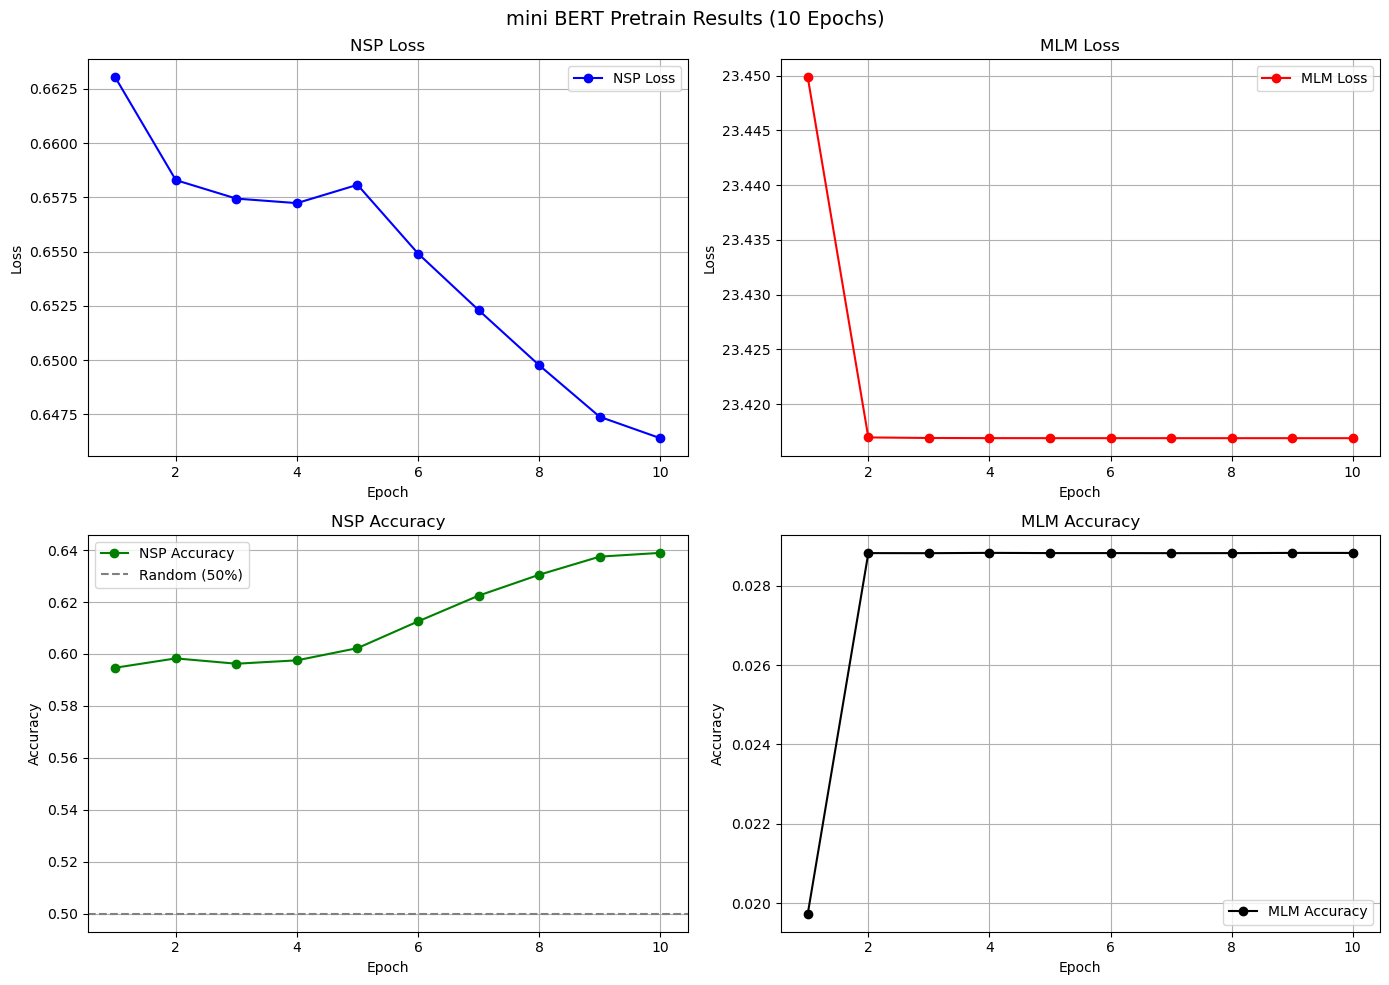

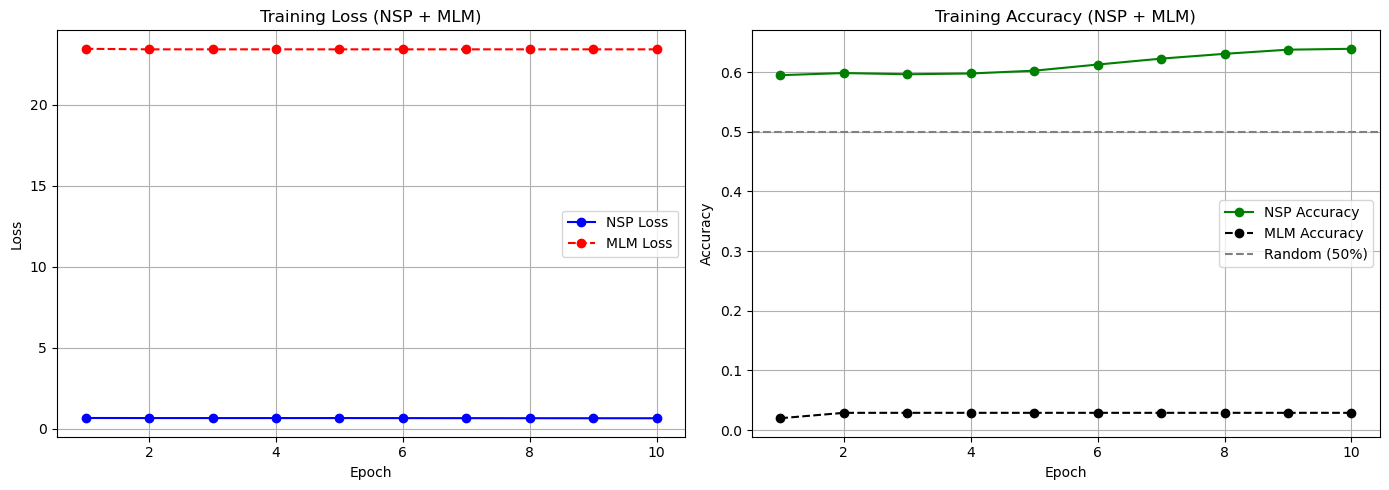

mini BERT (미니 버트) 학습 결과 요약
 Epoch |   NSP Loss |   MLM Loss |    NSP Acc |    MLM Acc
------------------------------------------------------------
     1 |     0.6630 |    23.4498 |     0.5947 |     0.0197
     2 |     0.6583 |    23.4170 |     0.5983 |     0.0288
     3 |     0.6574 |    23.4169 |     0.5963 |     0.0288
     4 |     0.6572 |    23.4169 |     0.5976 |     0.0288
     5 |     0.6581 |    23.4169 |     0.6023 |     0.0288
     6 |     0.6549 |    23.4169 |     0.6125 |     0.0288
     7 |     0.6523 |    23.4169 |     0.6225 |     0.0288
     8 |     0.6498 |    23.4169 |     0.6305 |     0.0288
     9 |     0.6474 |    23.4169 |     0.6375 |     0.0288
    10 |     0.6464 |    23.4169 |     0.6389 |     0.0288

최종 결과 (Epoch 10):
NSP Loss (엔에스피 로스)       : 0.6464
MLM Loss (엠엘엠 로스)         : 23.4169
NSP Accuracy (엔에스피 어큐러시) : 0.6389 (63.9%)
MLM Accuracy (엠엘엠 어큐러시)  : 0.0288 (2.9%)

수렴 여부 분석
NSP Loss (엔에스피 로스) 감소: ✅ (0.6630 → 0.6464)
MLM Loss (엠엘엠 로스) 감소: ✅ (23.4498 → 23.

In [75]:
# ================================================================
# 프로젝트 최종 결과 시각화 visualization (비주얼라이제이션)
# ================================================================
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 경고 방지
plt.rcParams['font.family']         = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus']  = False

epochs_range = range(1, len(history['nsp_loss']) + 1)

# -------------------------------------------------------
# 1. Loss (로스) & Accuracy (어큐러시) 그래프
# -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# NSP Loss (엔에스피 로스)
axes[0, 0].plot(epochs_range, history['nsp_loss'], 'b-o', label='NSP Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('NSP Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# MLM Loss (엠엘엠 로스)
axes[0, 1].plot(epochs_range, history['mlm_loss'], 'r-o', label='MLM Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('MLM Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# NSP Accuracy (엔에스피 어큐러시)
axes[1, 0].plot(epochs_range, history['nsp_acc'], 'g-o', label='NSP Accuracy')
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', label='Random (50%)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('NSP Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# MLM Accuracy (엠엘엠 어큐러시)
axes[1, 1].plot(epochs_range, history['mlm_acc'], 'k-o', label='MLM Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('MLM Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle('mini BERT Pretrain Results (10 Epochs)', fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 2. 전체 요약 그래프
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (로스) 비교
axes[0].plot(epochs_range, history['nsp_loss'], 'b-o', label='NSP Loss')
axes[0].plot(epochs_range, history['mlm_loss'], 'r--o', label='MLM Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (NSP + MLM)')
axes[0].legend()
axes[0].grid(True)

# Accuracy (어큐러시) 비교
axes[1].plot(epochs_range, history['nsp_acc'], 'g-o', label='NSP Accuracy')
axes[1].plot(epochs_range, history['mlm_acc'], 'k--o', label='MLM Accuracy')
axes[1].axhline(y=0.5, color='gray', linestyle='--', label='Random (50%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy (NSP + MLM)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 3. 수치 결과 요약
# -------------------------------------------------------
print("=" * 60)
print("mini BERT (미니 버트) 학습 결과 요약")
print("=" * 60)
print(f"{'Epoch':>6} | {'NSP Loss':>10} | {'MLM Loss':>10} | {'NSP Acc':>10} | {'MLM Acc':>10}")
print("-" * 60)

for i in range(len(history['nsp_loss'])):
    print(
        f"{i+1:>6} | "
        f"{history['nsp_loss'][i]:>10.4f} | "
        f"{history['mlm_loss'][i]:>10.4f} | "
        f"{history['nsp_acc'][i]:>10.4f} | "
        f"{history['mlm_acc'][i]:>10.4f}"
    )

print("=" * 60)
print(f"\n최종 결과 (Epoch 10):")
print(f"NSP Loss (엔에스피 로스)       : {history['nsp_loss'][-1]:.4f}")
print(f"MLM Loss (엠엘엠 로스)         : {history['mlm_loss'][-1]:.4f}")
print(f"NSP Accuracy (엔에스피 어큐러시) : {history['nsp_acc'][-1]:.4f} ({history['nsp_acc'][-1]*100:.1f}%)")
print(f"MLM Accuracy (엠엘엠 어큐러시)  : {history['mlm_acc'][-1]:.4f} ({history['mlm_acc'][-1]*100:.1f}%)")

# -------------------------------------------------------
# 4. 수렴 여부 분석
# -------------------------------------------------------
print("\n" + "=" * 60)
print("수렴 여부 분석")
print("=" * 60)

nsp_converged = history['nsp_loss'][-1] < history['nsp_loss'][0]
mlm_converged = history['mlm_loss'][-1] < history['mlm_loss'][0]
nsp_above_random = history['nsp_acc'][-1] > 0.5

print(f"NSP Loss (엔에스피 로스) 감소: {'✅' if nsp_converged else '❌'} "
      f"({history['nsp_loss'][0]:.4f} → {history['nsp_loss'][-1]:.4f})")
print(f"MLM Loss (엠엘엠 로스) 감소: {'✅' if mlm_converged else '❌'} "
      f"({history['mlm_loss'][0]:.4f} → {history['mlm_loss'][-1]:.4f})")
print(f"NSP Accuracy (어큐러시) > 50%: {'✅' if nsp_above_random else '❌'} "
      f"({history['nsp_acc'][-1]*100:.1f}%)")

# 프로젝트 회고 (Retrospective)

### 1. 잘한 점 ✅

- SentencePiece (센텐스피스) BPE (비피이) 토크나이저를
  kowiki.txt (코위키 텍스트) 로 직접 학습하여
  vocab_size (보캡 사이즈) 8,000 의 한국어 tokenizer (토크나이저) 완성

- MLM (엠엘엠) 마스킹 전략을 올바르게 구현
  - 전체 token (토큰) 의 15% 선택
  - 80% → [MASK] (마스크) 교체
  - 10% → 랜덤 random (랜덤) token (토큰) 교체
  - 10% → 원래 token (토큰) 유지
  - 띄어쓰기 단위 Whole Word Masking (홀 워드 마스킹) 적용

- NSP (엔에스피) 데이터를 50:50 비율로 올바르게 생성
  - IsNext (이즈넥스트) TRUE / NotNext (낫넥스트) FALSE 균형 유지

- np.memmap (넘파이 멤맵) 으로 대용량 데이터를
  메모리 효율적으로 처리

- Transformer (트랜스포머) Encoder (인코더) 구조를
  직접 구현 (MultiHeadAttention (멀티헤드 어텐션),
  PositionWiseFeedForward (포지션 와이즈 피드포워드) 등)

- CosineSchedule (코사인 스케줄) Learning Rate (러닝 레이트)
  스케줄링으로 안정적인 학습 진행

- 10 epoch (에포크) pretrain (프리트레인) 완료
  - NSP Loss (엔에스피 로스): 0.6630 → 0.6464 감소 ✅
  - NSP Accuracy (어큐러시): 59.4% → 63.9% 향상 ✅

---

### 2. 아쉬운 점 ⚠️

- MLM Accuracy (엠엘엠 어큐러시) 가 2.88% 로 매우 낮음
  → vocab_size (보캡 사이즈) 8,007 개 중
    정확한 token (토큰) 을 맞추기 어려움
  → 모델 크기 (~1M parameter (파라미터)) 가
    너무 작아 표현력 부족

- MLM Loss (엠엘엠 로스) 가 epoch 2 이후
  거의 수렴하지 않음 (23.45 → 23.42)
  → 더 많은 학습 데이터와 epoch (에포크) 필요

- 학습 환경 제약으로 인해
  전체 kowiki (코위키) 데이터 중
  128,000건만 사용 (전체의 약 5%)

---

### 3. 배운 점 📚

- pretrained model (프리트레인드 모델) 제작에서
  모델 구현보다 데이터 전처리가 훨씬 큰 비중을 차지함을 체감

- BERT (버트) 의 두 가지 핵심 태스크
  MLM (엠엘엠) 과 NSP (엔에스피) 의 의미와
  구현 방법을 깊이 이해

- "왜 모든 token (토큰) 이 모든 파라미터를 써야 하지?" 라는
  질문에서 출발한 MoE (모에) 와 달리,
  BERT (버트) 는 양방향 bidirectional (바이디렉셔널)
  문맥 이해에 집중함을 이해

- Weight Sharing (웨이트 쉐어링) 으로
  파라미터를 절약하면서도 성능을 유지하는
  SharedEmbedding (쉐어드 임베딩) 구조 이해

- np.memmap (넘파이 멤맵) 을 통해
  대용량 데이터를 메모리 효율적으로
  처리하는 방법 습득

---

### 4. 개선 방향 🚀

- d_model (디 모델) 을 128 → 256 으로 늘려
  모델 표현력 향상 시도

- 학습 데이터를 128,000건 → 500,000건으로 늘려
  더 풍부한 학습 진행

- MLM loss (엠엘엠 로스) 배율을
  × 20 → × 5 로 줄여 gradient (그래디언트) 안정화

- 이 pretrained model (프리트레인드 모델) 을 기반으로
  감성 분석 Sentiment Analysis (센티먼트 어낼리시스),
  개체명 인식 NER (엔이알) 등
  Fine-tuning (파인튜닝) 태스크 도전!